# NIRSpec Prism data analysis

This notebook will analyse only one segment, but we will go from `uncal` data products to light curve. The basic procedure in this notebook is this: we will start with `uncal` data, and then use the `jwst` data calibration pipeline to calibrate the data. We will then "correct" this data as in flagging cosmic rays and including them in bad-pixel maps, interpolate over this flagged datapoints to correct them, and correct errorbars. After this, we will perform a background subtraction, and, finally, we will extract the stellar spectra from this data using `stark`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from stark import SingleOrderPSF, optimal_extract
from jwst.pipeline import calwebb_detector1
from stark import aperture_extract
from krithika import plotstyles, pipe_mad
from astropy.stats import mad_std
from jwst import datamodels
from poetss import poetss
from stark import reduce
from tqdm import tqdm
import os
import utils

from matplotlib import rcParams
rcParams['xtick.direction'] = 'out'
rcParams['ytick.direction'] = 'out'
rcParams['legend.frameon'] = True
rcParams['figure.dpi'] = 300

Let's load the dataset and plot one of the data frames.

<RampModel(3200, 5, 32, 512) from jw01366004001_04101_00001-seg004_nrs1_uncal.fits>


Text(0.5, 1.0, 'Example data')

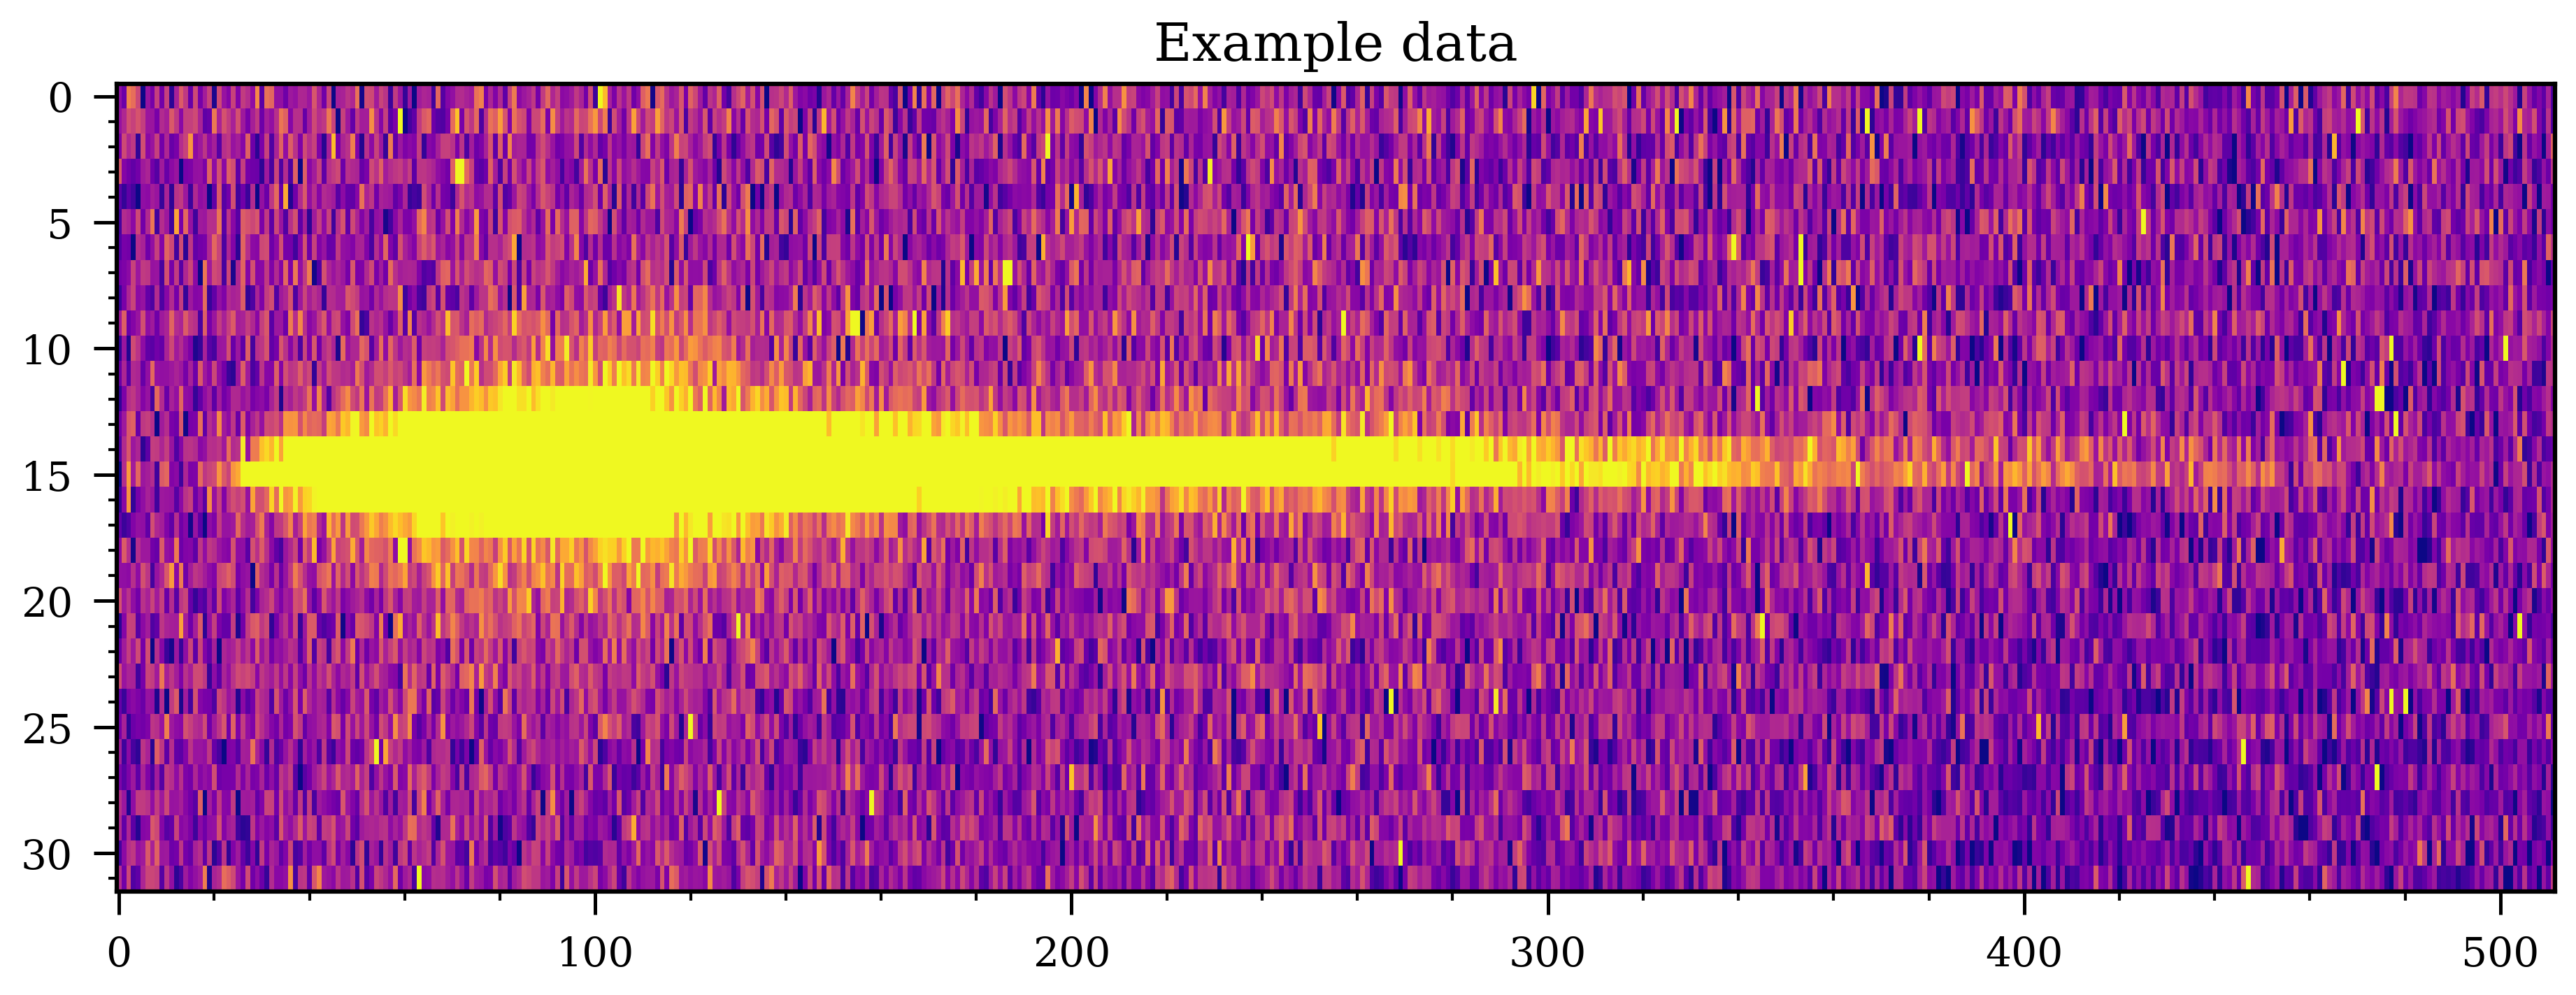

In [2]:
# -----------------------------------------------------
#   Data path and file name
# -----------------------------------------------------
p1 = '/'.join(os.getcwd().split('/')[:-1])
pin = p1 + '/Data/NRSPR'
pout = p1 + '/NRSPR/Test'
fname = 'jw01366004001_04101_00001-seg004_nrs1_uncal.fits'

# -----------------------------------------------------
# Aperture radii and sigma clipping threshold
# -----------------------------------------------------
aprad_psf = 7
aprad_extraction = 5
clip_sigma = 20
oversample_psf = 2
xstart, xend = 150, 450

# -----------------------------------------------------
#   Load data and metadata
# -----------------------------------------------------
uncal = datamodels.RampModel(pin + '/' + fname)
nint = np.random.randint(0, uncal.data.shape[0])
print(uncal)

## Time
times_bjd = uncal.int_times['int_mid_BJD_TDB']

# -------------------------------------------------
#  Plotting
# -------------------------------------------------

## Visualise the data and bad-pixel map (for a random integration)
plt.figure(figsize=(15,5))
im = plt.imshow(uncal.data[nint,-1,:,:], interpolation='none', aspect='auto')
im.set_clim([5e3,1e4])
plt.title('Example data')

Now, we have to calibrate this data using the default `jwst` pipeline. The only modification that we will make at this point would be that we will skip the `jump` step.

2026-04-27 18:04:15,594 - CRDS - INFO -  Calibration SW Found: jwst 1.20.2 (/Users/jaspa/anaconda3/lib/python3.13/site-packages/jwst-1.20.2.dist-info)
2026-04-27 18:04:16,095 - stpipe.step - INFO - GroupScaleStep instance created.
2026-04-27 18:04:16,190 - stpipe.step - INFO - Step GroupScaleStep running with args (<RampModel(3200, 5, 32, 512) from jw01366004001_04101_00001-seg004_nrs1_uncal.fits>,).
2026-04-27 18:04:16,191 - stpipe.step - INFO - Step GroupScaleStep parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: None
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: False
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
2026-04-27 18:04:16,255 - jwst.group_scale.group_scale_step - INFO - NFRAMES and FRMDIVSR are equal; correction not needed
2026-04-27 18:04:16,256 - jwst.group_scale.group_scale_step - INFO - Step will be skipped
2026-04-27 18:04:16,257 - stpipe.step - INFO - Step GroupScaleS

Percentage of bad-pixels: 0.7835 %


Text(0.5, 1.0, 'Example bad-pixel map')

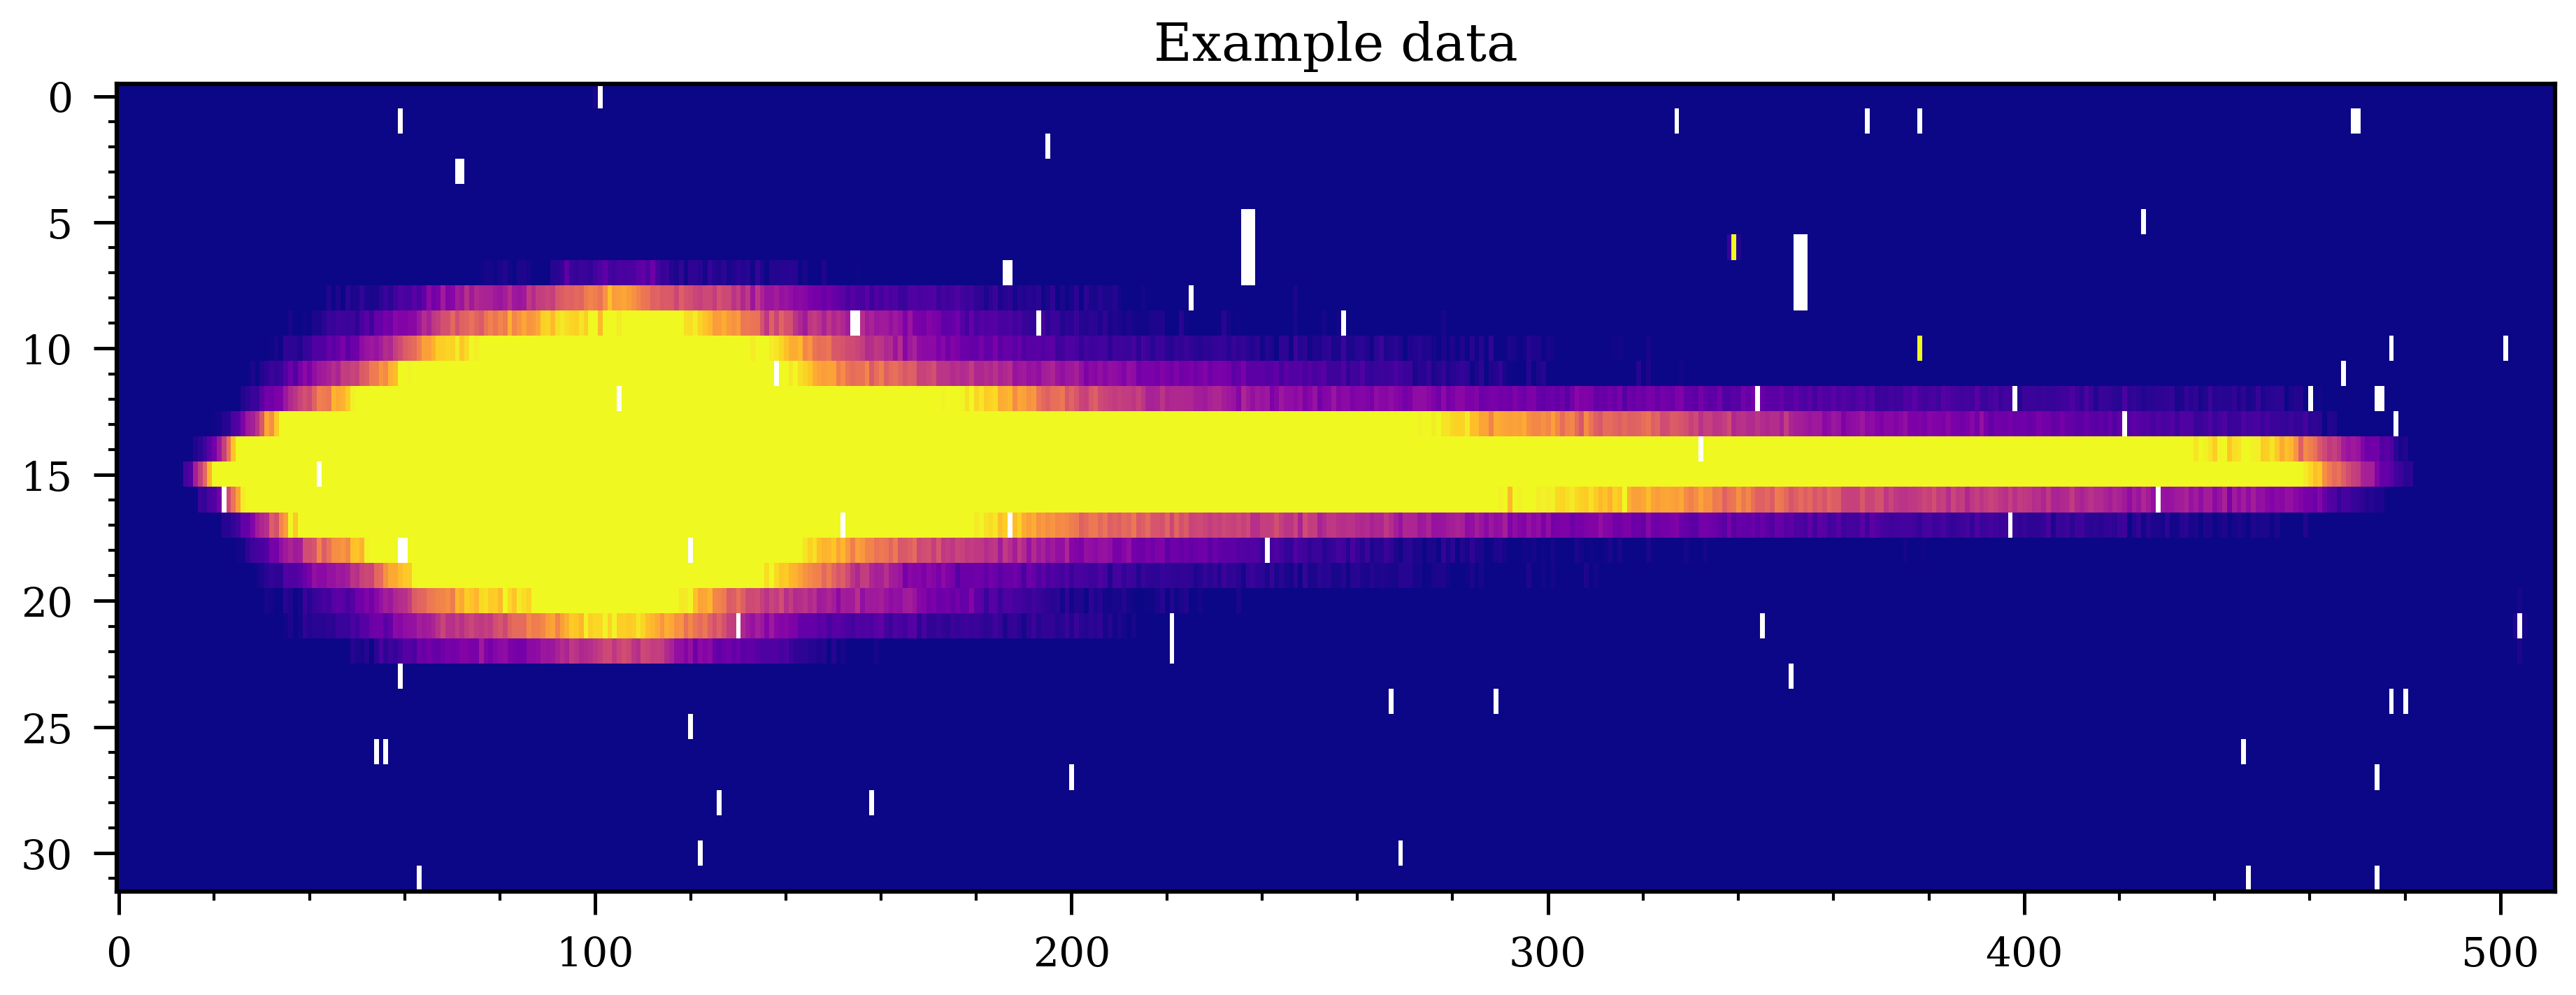

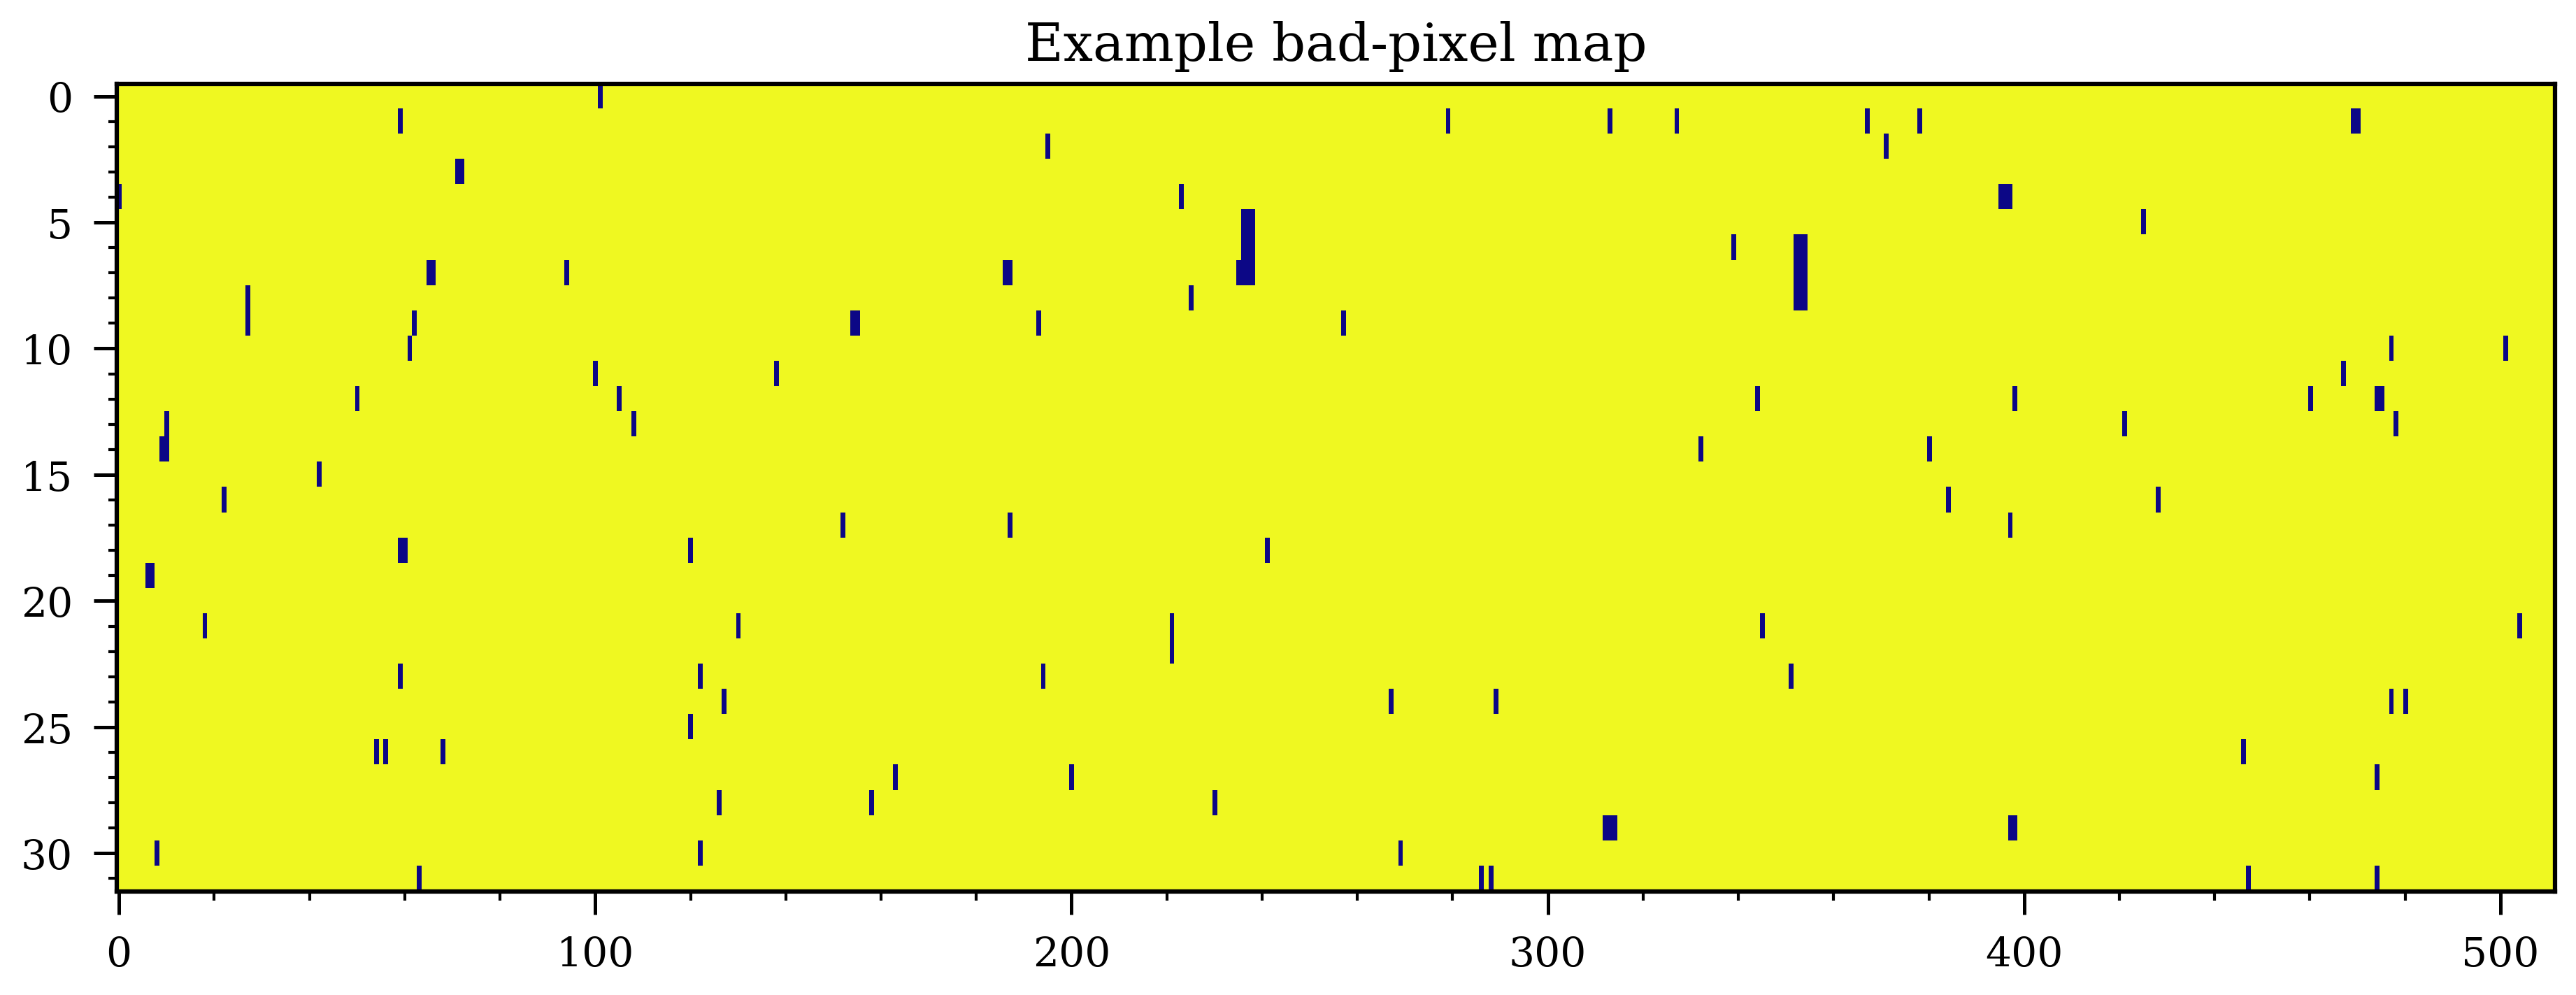

In [3]:
# -----------------------------------------------------------
#   Running the Stage 1 pipeline
# -----------------------------------------------------------

#det1 = calwebb_detector1.Detector1Pipeline.call(uncal,\
#                                                steps={'jump' : {'skip' : True},\
#                                                        'dark_current' : {'skip' : True},
#                                                        'ramp_fit' : {'maximum_cores' : '1'}},\
#                                                output_dir=pout, save_results=True)

group_scale_results = calwebb_detector1.group_scale_step.GroupScaleStep.call(uncal, save_results=False)
dq_results = calwebb_detector1.dq_init_step.DQInitStep.call(group_scale_results, save_results=False)
saturation_results = calwebb_detector1.saturation_step.SaturationStep.call(dq_results, save_results=False)

superbias_results = calwebb_detector1.superbias_step.SuperBiasStep.call(saturation_results, save_results=False)
## Doing supervias step manually
"""superbias = np.nanmedian(saturation_results.data[:,0,:,:], axis=0)
for inte in range(saturation_results.data.shape[0]):
    for gr in range(saturation_results.data.shape[1]):
        saturation_results.data[inte,gr,:,:] = saturation_results.data[inte,gr,:,:] - superbias"""

refpix_results = calwebb_detector1.refpix_step.RefPixStep.call(superbias_results, save_results=False)
linearity_results = calwebb_detector1.linearity_step.LinearityStep.call(refpix_results, save_results=False)

## Manualy background subtraction at group level
mask_bkg = np.ones(linearity_results.data[0,0,:,:].shape)
mask_bkg[6:26,:] = 0.
### Bad-pixel map
dq = linearity_results.groupdq
mask_bp = np.ones(dq.shape)
mask_bp[dq > 0] = 0.
for inte in tqdm(range(linearity_results.data.shape[0])):
    for gr in range(linearity_results.data.shape[1]):
        linearity_results.data[inte,gr,:,:], _ = reduce.col_by_col_bkg_sub(frame=linearity_results.data[inte,gr,:,:], mask=mask_bkg * mask_bp[inte,gr,:,:])

rampfitting_results = calwebb_detector1.ramp_fit_step.RampFitStep.call(linearity_results, output_dir=pout, save_results=False)
gainscale_results = calwebb_detector1.gain_scale_step.GainScaleStep.call(rampfitting_results[1], output_dir=pout, save_results=True)

# ------ Loading the rateints file
#rate_ints = datamodels.open(pout + '/' + fname.replace('uncal', 'rateints'))
#rate_ints = datamodels.open(pout + '/' + fname.replace('uncal', '1_rampfitstep'))
rate_ints = datamodels.open(pout + '/' + fname.replace('uncal', 'gainscalestep'))

## Bad-pixel map
dq = rate_ints.dq
mask = np.ones(dq.shape)
mask[dq > 0] = 0.

print('Percentage of bad-pixels: {:.4f} %'.format((1 - np.sum(mask) / ( mask.shape[0] * mask.shape[1] * mask.shape[2] ) ) * 100))

# -------------------------------------------------
#  Plotting
# -------------------------------------------------

## Visualise the data and bad-pixel map (for a random integration)
plt.figure(figsize=(15,5))
im = plt.imshow(rate_ints.data[nint,:,:], interpolation='none', aspect='auto')
im.set_clim([1e2,1e3])
plt.title('Example data')

plt.figure(figsize=(15,5))
im = plt.imshow(mask[nint,:,:], interpolation='none', aspect='auto')
#im.set_clim([0,1e2])
plt.title('Example bad-pixel map')

Okay, about 0.78% of pixels are bad. We will simply "correct" them by taking a mean of neighbouring pixels. However, we will still not use them as they are in the bad-pixel map.

Let's start with correcting errorbars:

>>>> --- Correcting errorbars (for zeros and NaNs)...
>>>> --- Done!!
>>>> --- Creating a bad-pixel map...
>>>> --- Done!!
>>>> --- Identifying the cosmic rays...
>>>> --- Done!!
Total per cent of masked points: 0.8076 %


Text(0.5, 1.0, 'Bad-pixels for an arbitrary integration')

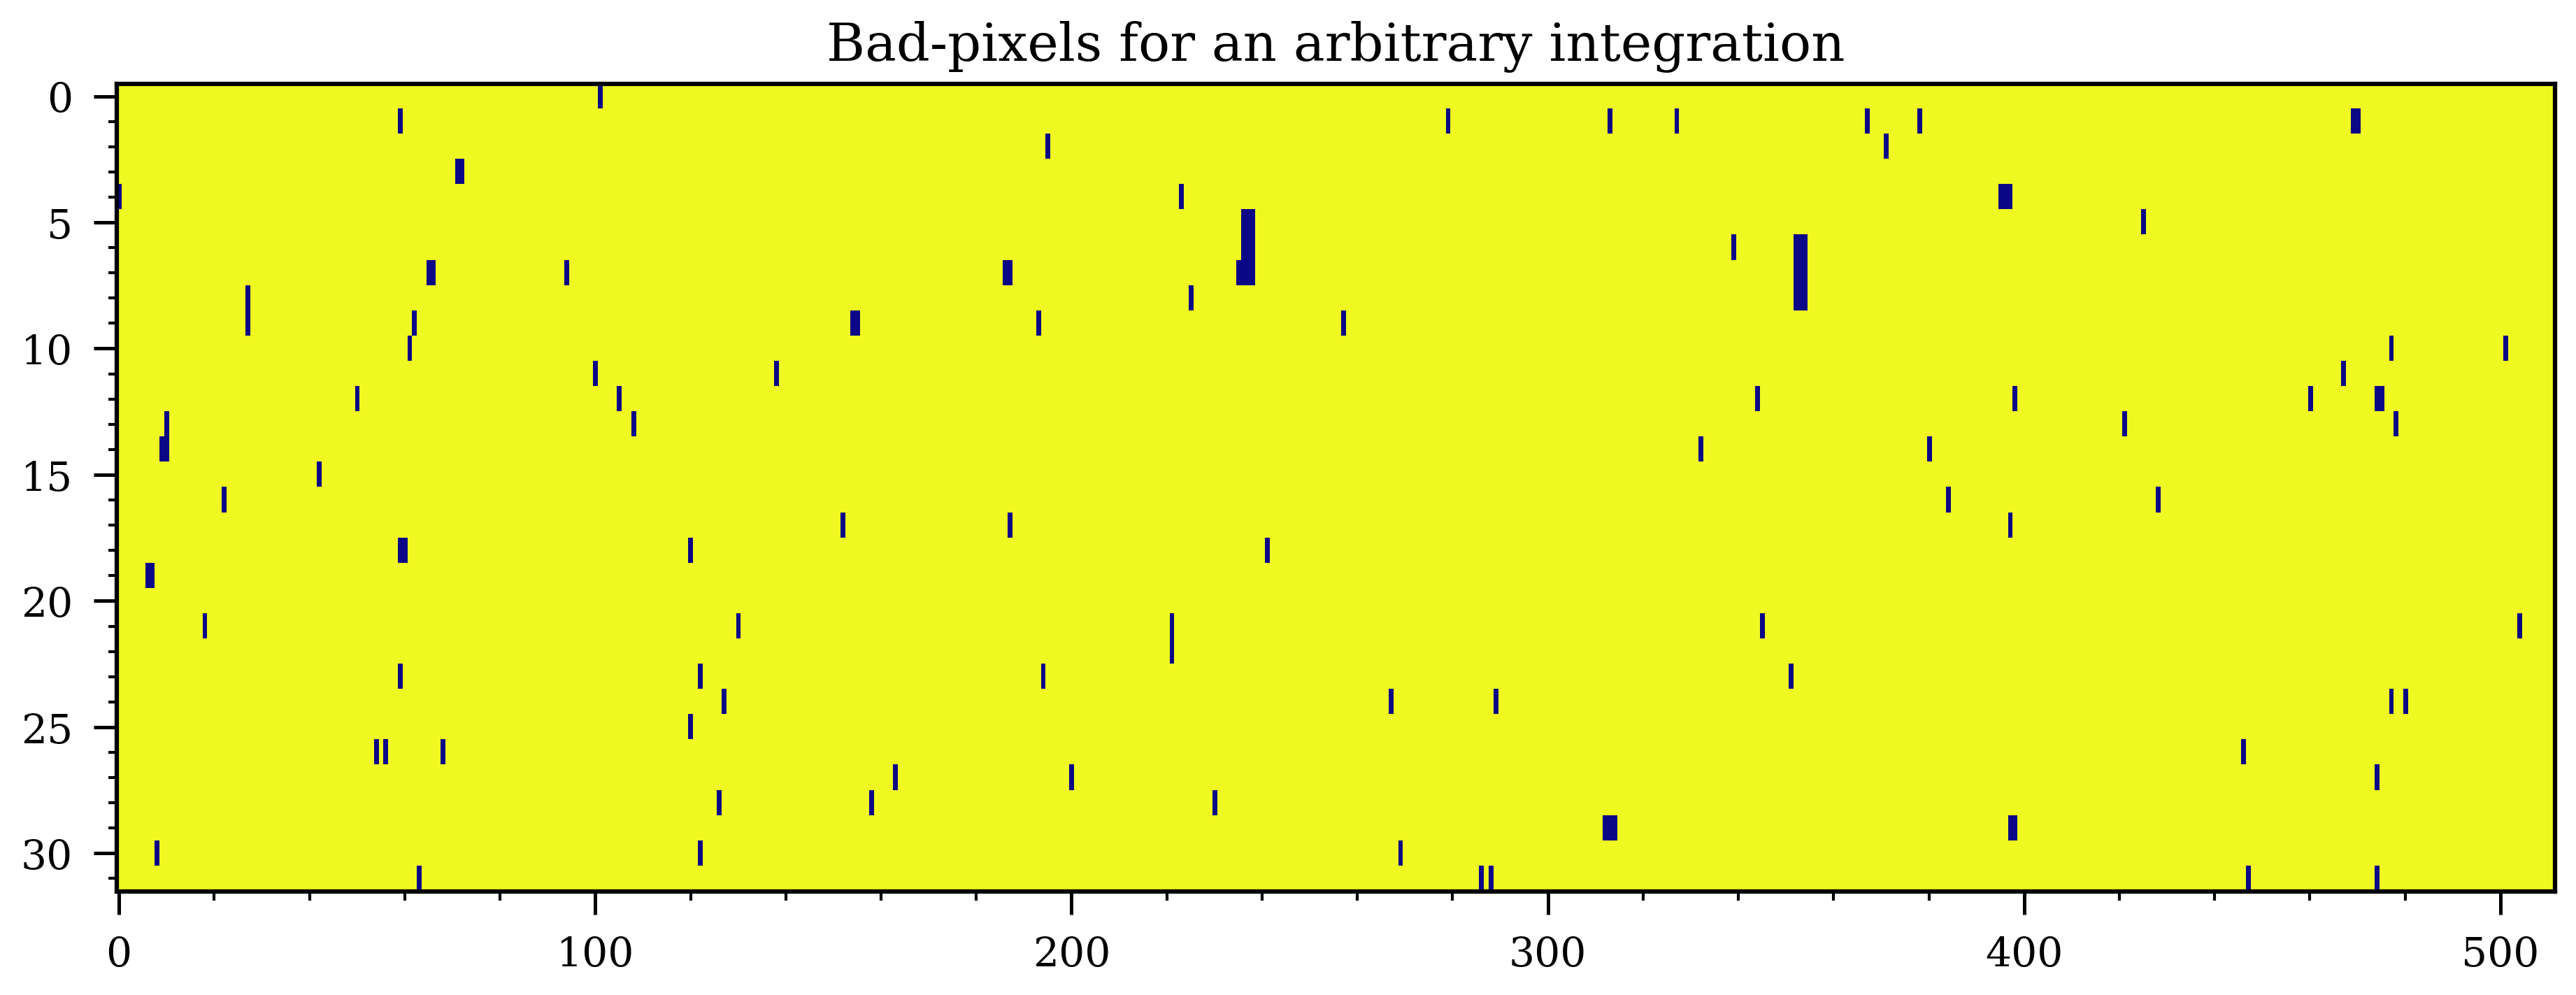

In [4]:
# -------------------------------------------------------------
#  Correcting errorbars (for zeros and NaNs)
# -------------------------------------------------------------
print('>>>> --- Correcting errorbars (for zeros and NaNs)...')
## Correct errorbars
med_err = np.nanmedian(rate_ints.err.flatten())
## Changing Nan's and zeros in error array with median error
corr_err1 = np.copy(rate_ints.err)
corr_err2 = np.where(rate_ints.err != 0., corr_err1, med_err)                     # Replacing error == 0 with median error
corrected_errs = np.where(np.isnan(rate_ints.err) != True, corr_err2, med_err)    # Replacing error == Nan with median error
print('>>>> --- Done!!')

# And now, adding this "bad" errors to the bad-pixel map
print('>>>> --- Creating a bad-pixel map...')
## Making a bad-pixel map
mask_bp1 = np.ones(rate_ints.data.shape)
mask_bp2 = np.where(rate_ints.err != 0., mask_bp1, 0.)                 # This will place 0 in mask where errorbar == 0
mask_bp3 = np.where(np.isnan(rate_ints.err) != True, mask_bp2, 0.)     # This will place 0 in mask where errorbar is Nan
#mask_badpix = np.where(dq == 0., mask_bp3, 0.)                               # This will place 0 in mask where darkdq != 0
mask_badpix = mask * mask_bp3  
print('>>>> --- Done!!')

# --------------------------------------------------------------
#  Identifying the cosmic rays
# --------------------------------------------------------------
print('>>>> --- Identifying the cosmic rays...')
## Mask with cosmic rays
### Essentially this mask will add 0s in the places of bad pixels...
mask_bcr = utils.identify_crays(rate_ints.data, mask_badpix)
print('>>>> --- Done!!')

# --------------------------------------------------------------
#  Visualising the bad-pixel map and cosmic-ray mask
# --------------------------------------------------------------
print('Total per cent of masked points: {:.4f} %'.format(100 * (1 - np.sum(mask_bcr) / (mask_bcr.shape[0] * mask_bcr.shape[1] * mask_bcr.shape[2]))))

plt.figure(figsize=(15,5))
plt.imshow(mask_bcr[nint,:,:], interpolation='none', aspect='auto')
plt.title('Bad-pixels for an arbitrary integration')

Great! This did not add many more points to the bad-pixel map! Now, we can start correcting for these bad-pixels, by replacing the values of bad-pixels by mean of neighbouring pixels. We will still not use them.

>>>> --- Correcting data...
>>>> --- Done!!


Text(0.5, 1.0, 'Example data')

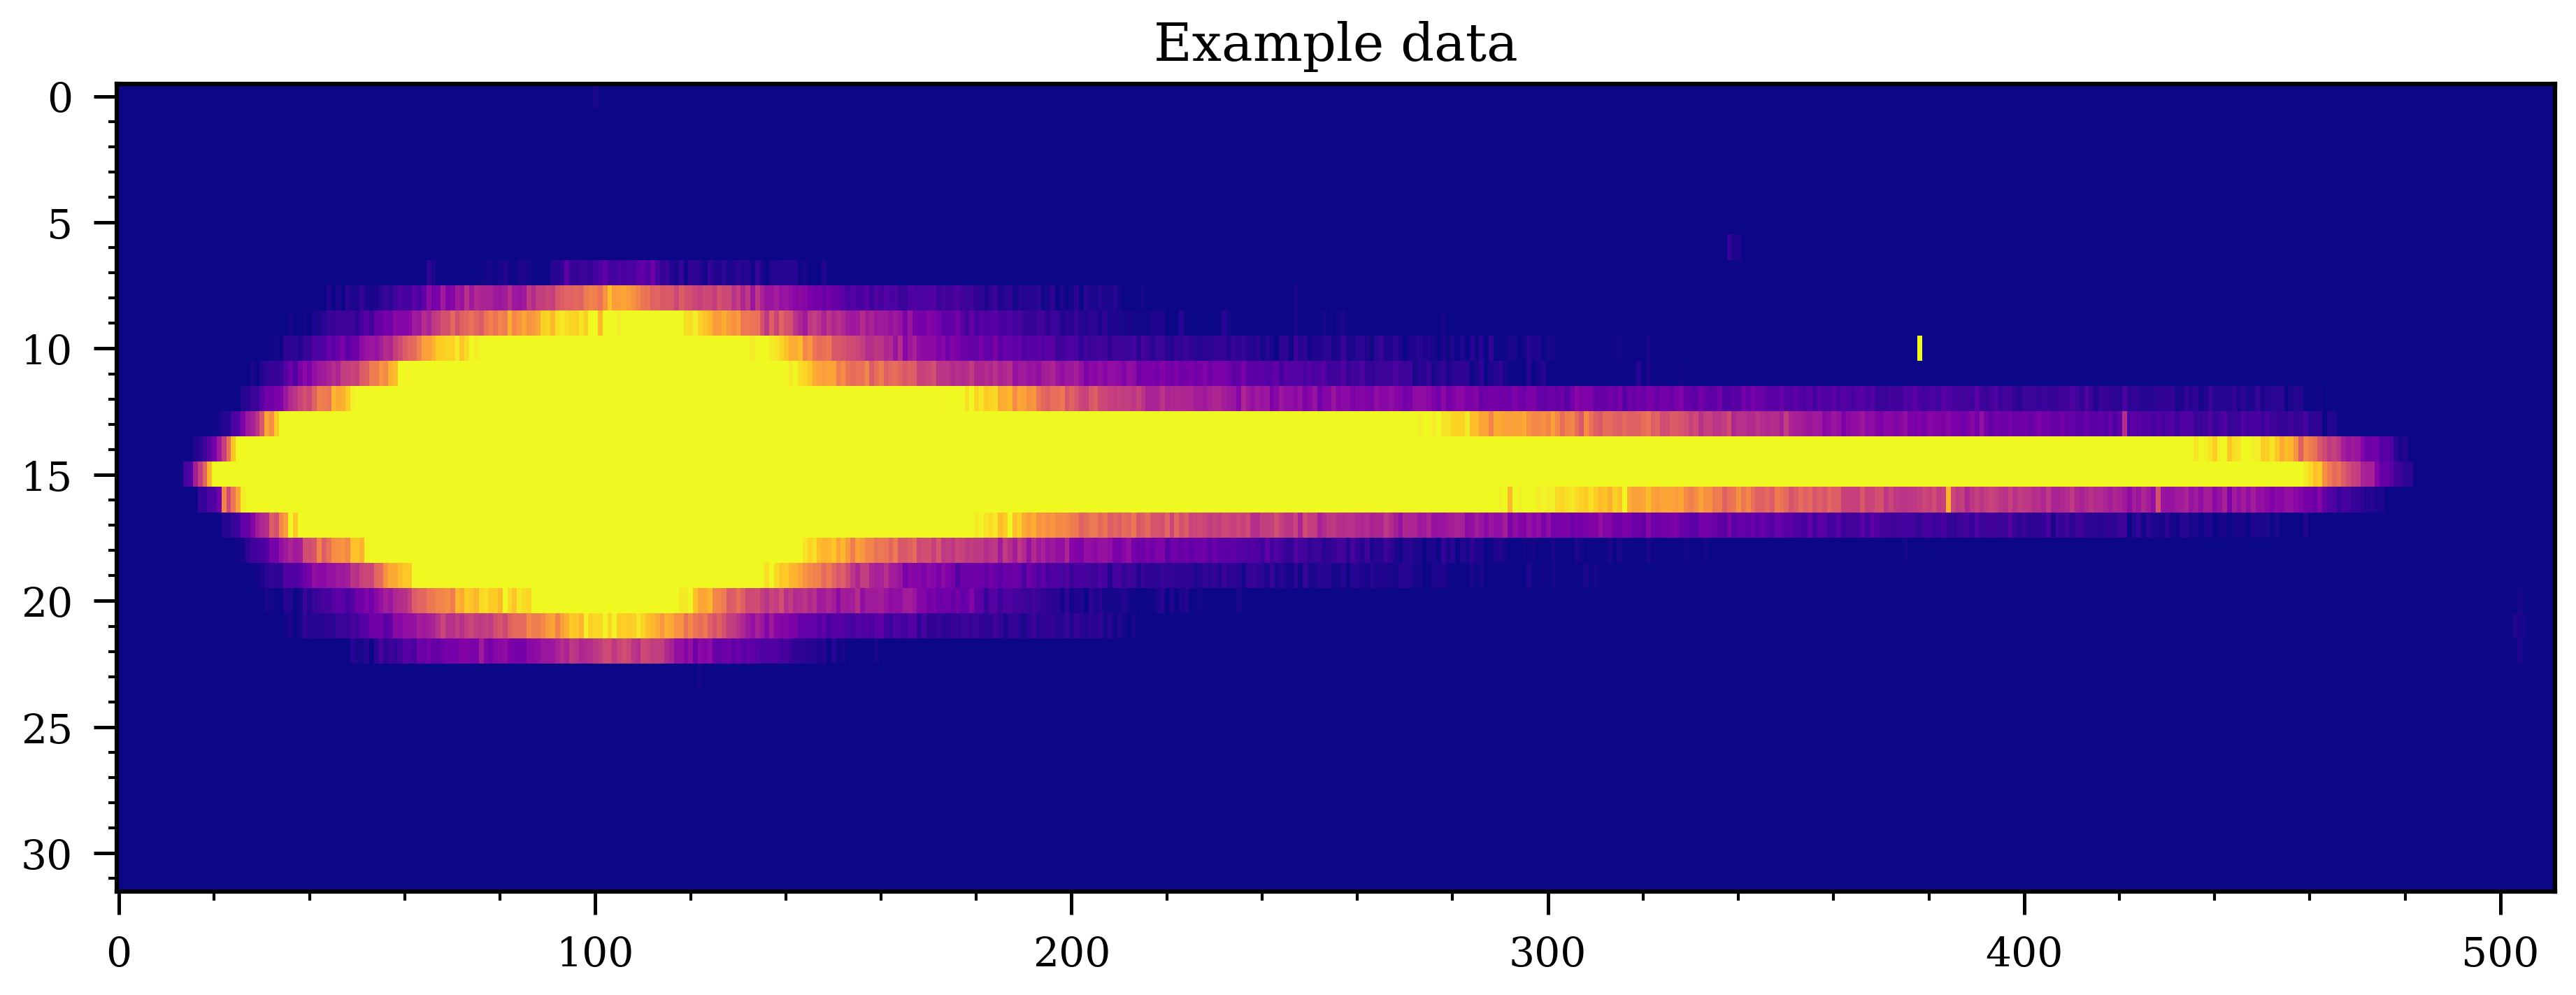

In [5]:
print('>>>> --- Correcting data...')
corrected_data = np.copy(rate_ints.data)
corrected_data[mask_bcr == 0] = np.nan
for i in range(corrected_data.shape[0]):
    corrected_data[i,:,:] = utils.replace_nan(corrected_data[i,:,:])
print('>>>> --- Done!!')

# -------------------------------------------------
#  Plotting
# -------------------------------------------------

## Visualise the data and bad-pixel map (for a random integration)
plt.figure(figsize=(15,5))
im = plt.imshow(corrected_data[nint,:,:], interpolation='none', aspect='auto')
im.set_clim([1e2,1e3])
plt.title('Example data')

Looks good enough. Now, we want to perform background subtraction -- column-by-column background subtraction, in particular. We need to estimate the location of trace in order to do this, because we will use the location of trace to define background region as N pixels away from the trace. We will use centre of flux method to define the trace region.

Text(0.5, 1.0, 'Example data with the location of spectral trace')

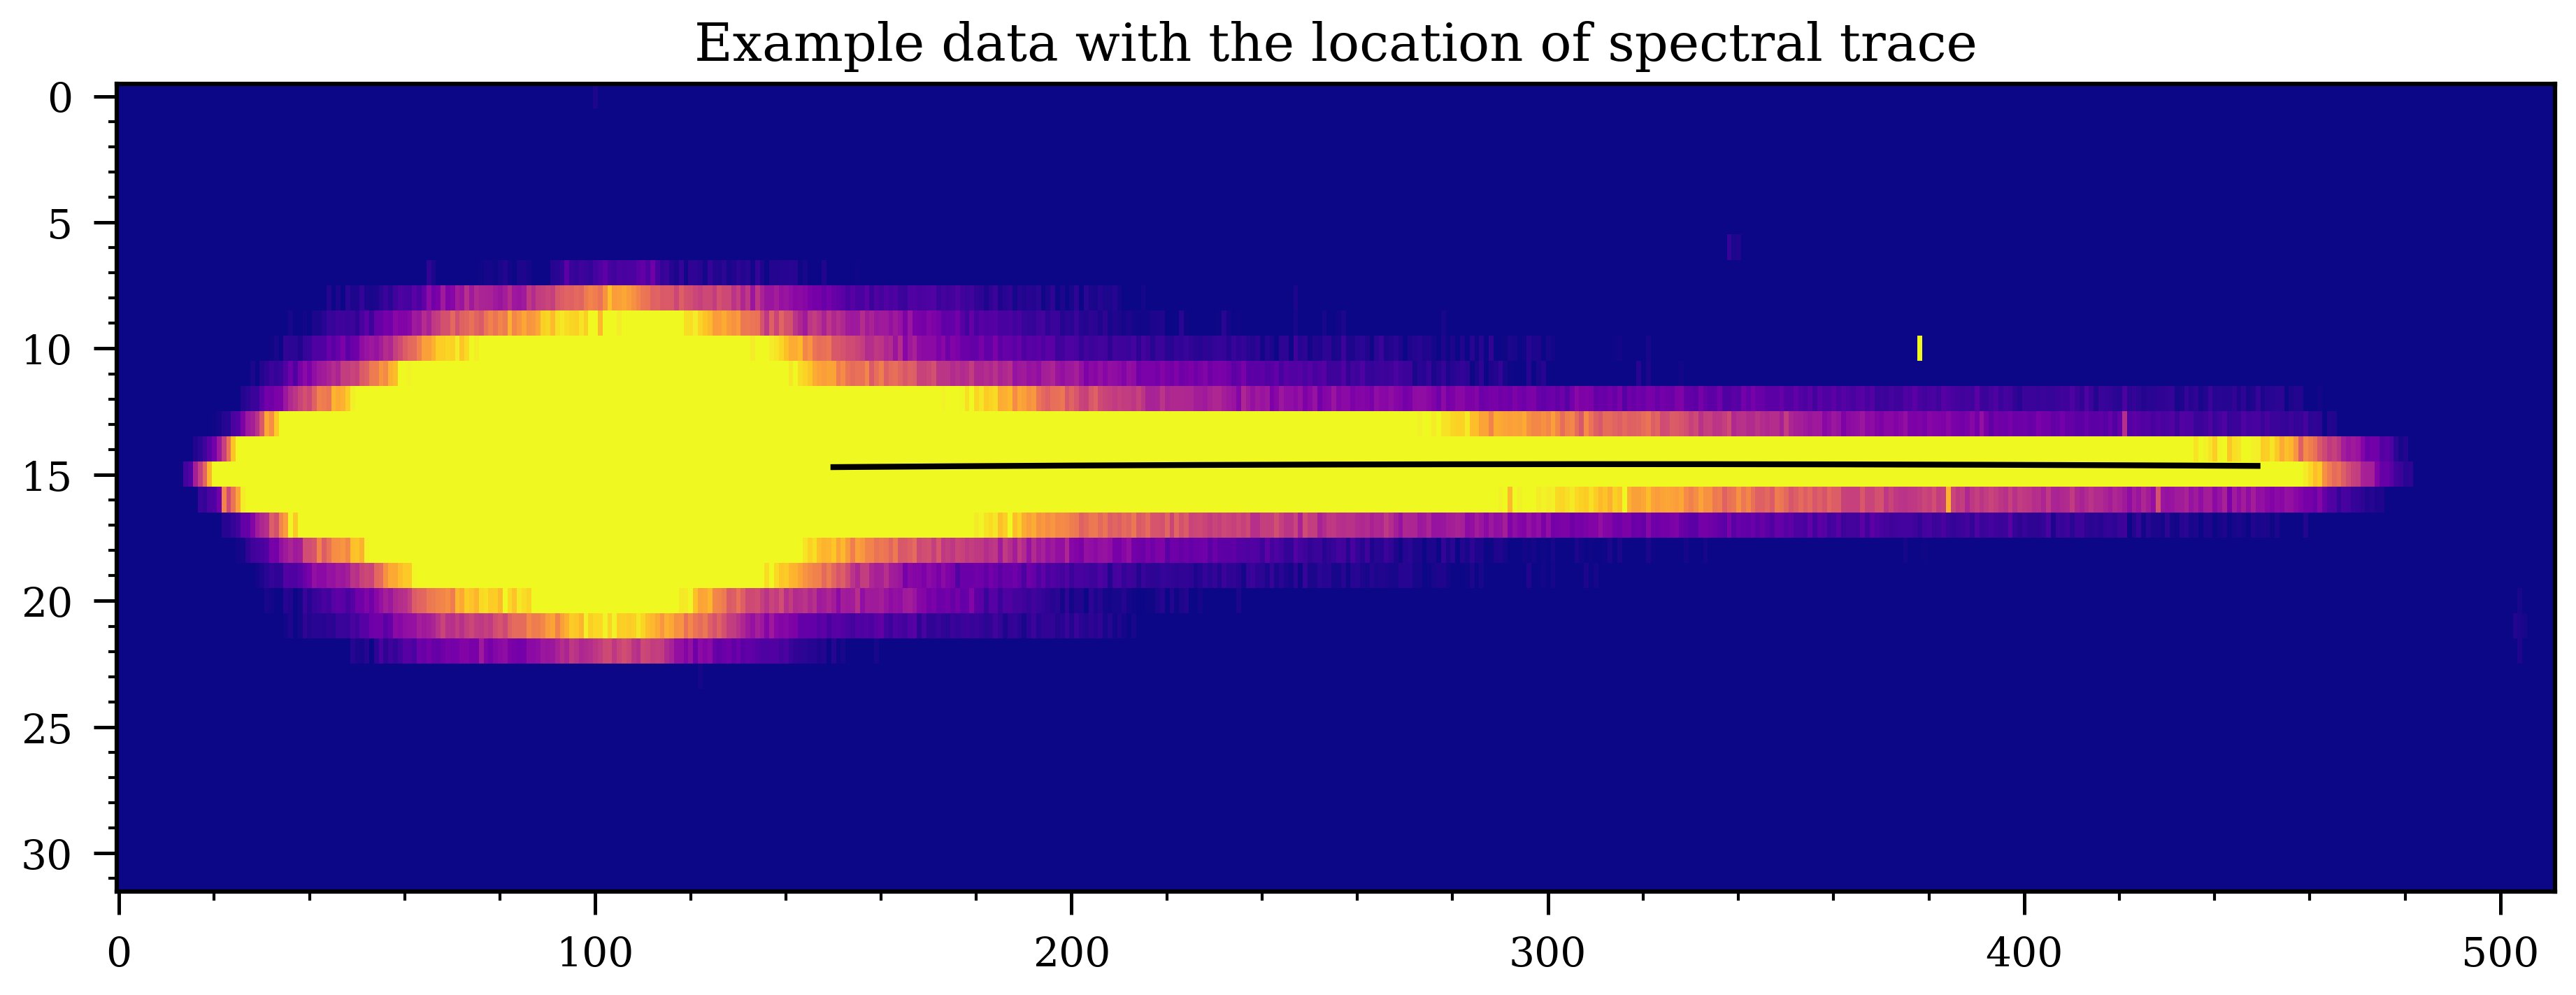

In [6]:
# -------------------------------------------------
#  Finding the spectral trace
# -------------------------------------------------
# Finding trace
cent_cub1 = poetss.find_trace_cof(clean_cube=corrected_data[:,:,xstart:xend], margin=5)
trace1, dx1 = poetss.fit_multi_trace(cent_mat=cent_cub1, deg=3, clip=3)
xpos = np.arange(xstart, xend, 1)

plt.figure(figsize=(15,5))
im = plt.imshow(corrected_data[nint,:,:], interpolation='none', aspect='auto')
im.set_clim([1e2,1e3])
plt.plot(xpos, trace1, 'k-')
plt.title('Example data with the location of spectral trace')

Let's also plot the jitter in the y-position of the trace:

Scatter in trace position: 0.0051 pix


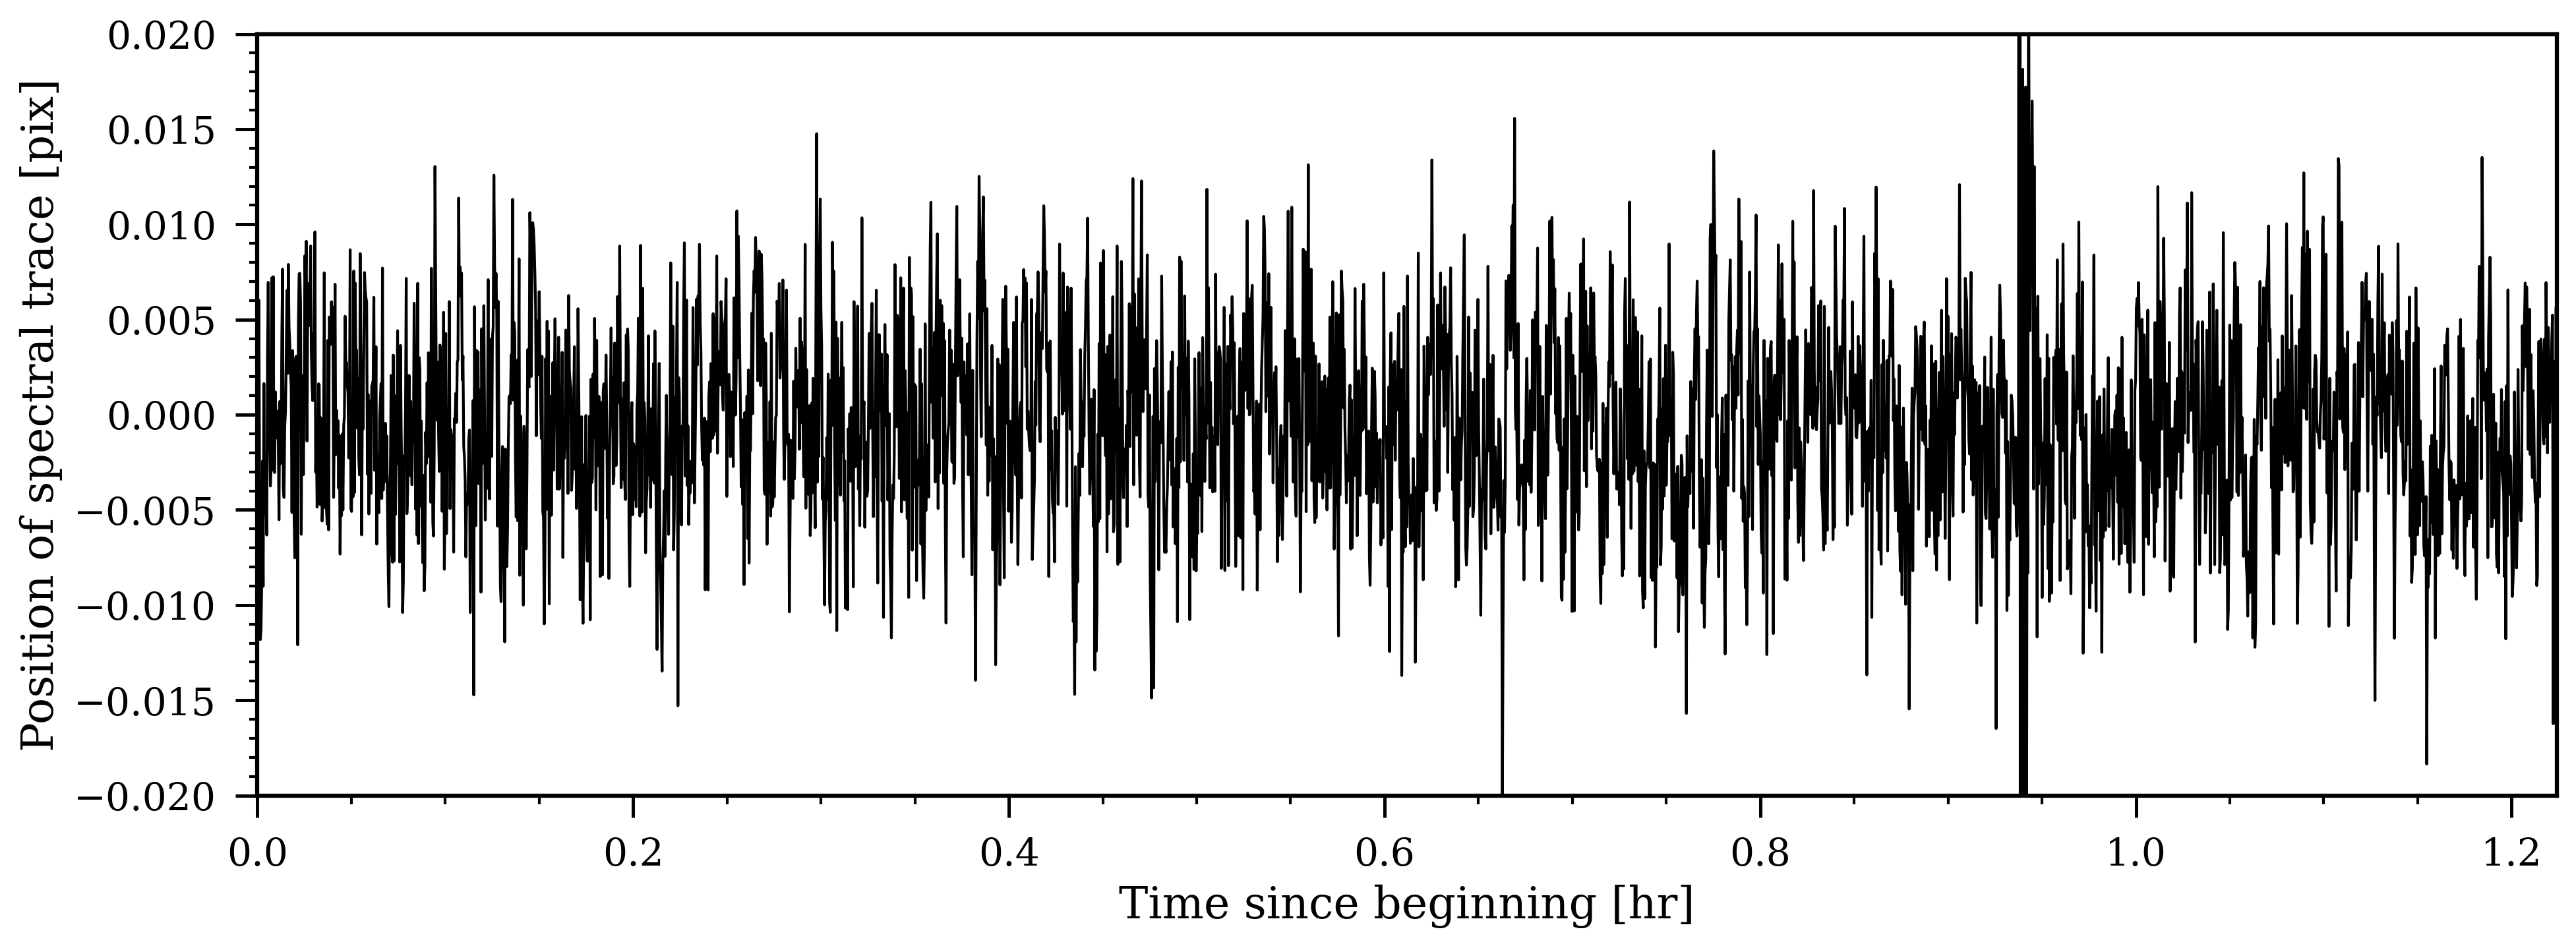

In [7]:
plt.figure(figsize=(15,5))
plt.plot( (times_bjd - times_bjd[0])*24, dx1, 'k-', lw=1.)
plt.xlabel('Time since beginning [hr]')
plt.ylabel('Position of spectral trace [pix]')
plt.ylim([-0.02, 0.02])

plt.xlim(0, (times_bjd[-1] - times_bjd[0])*24)

print('Scatter in trace position: {:.4f} pix'.format(mad_std(dx1)))

The jitter is at the sub-pixel level, that's pretty good. Okay, so now, we want to define the background region. As mentioned before, we will take all those pixels which are N pixels away from spectral trace as background pixels. However, we don't know how much wide the spectral trace is. Let's plot a verticle cut in the 2D frame, that means, how flux varies with row for a given column.

Text(0, 0.5, 'Flux')

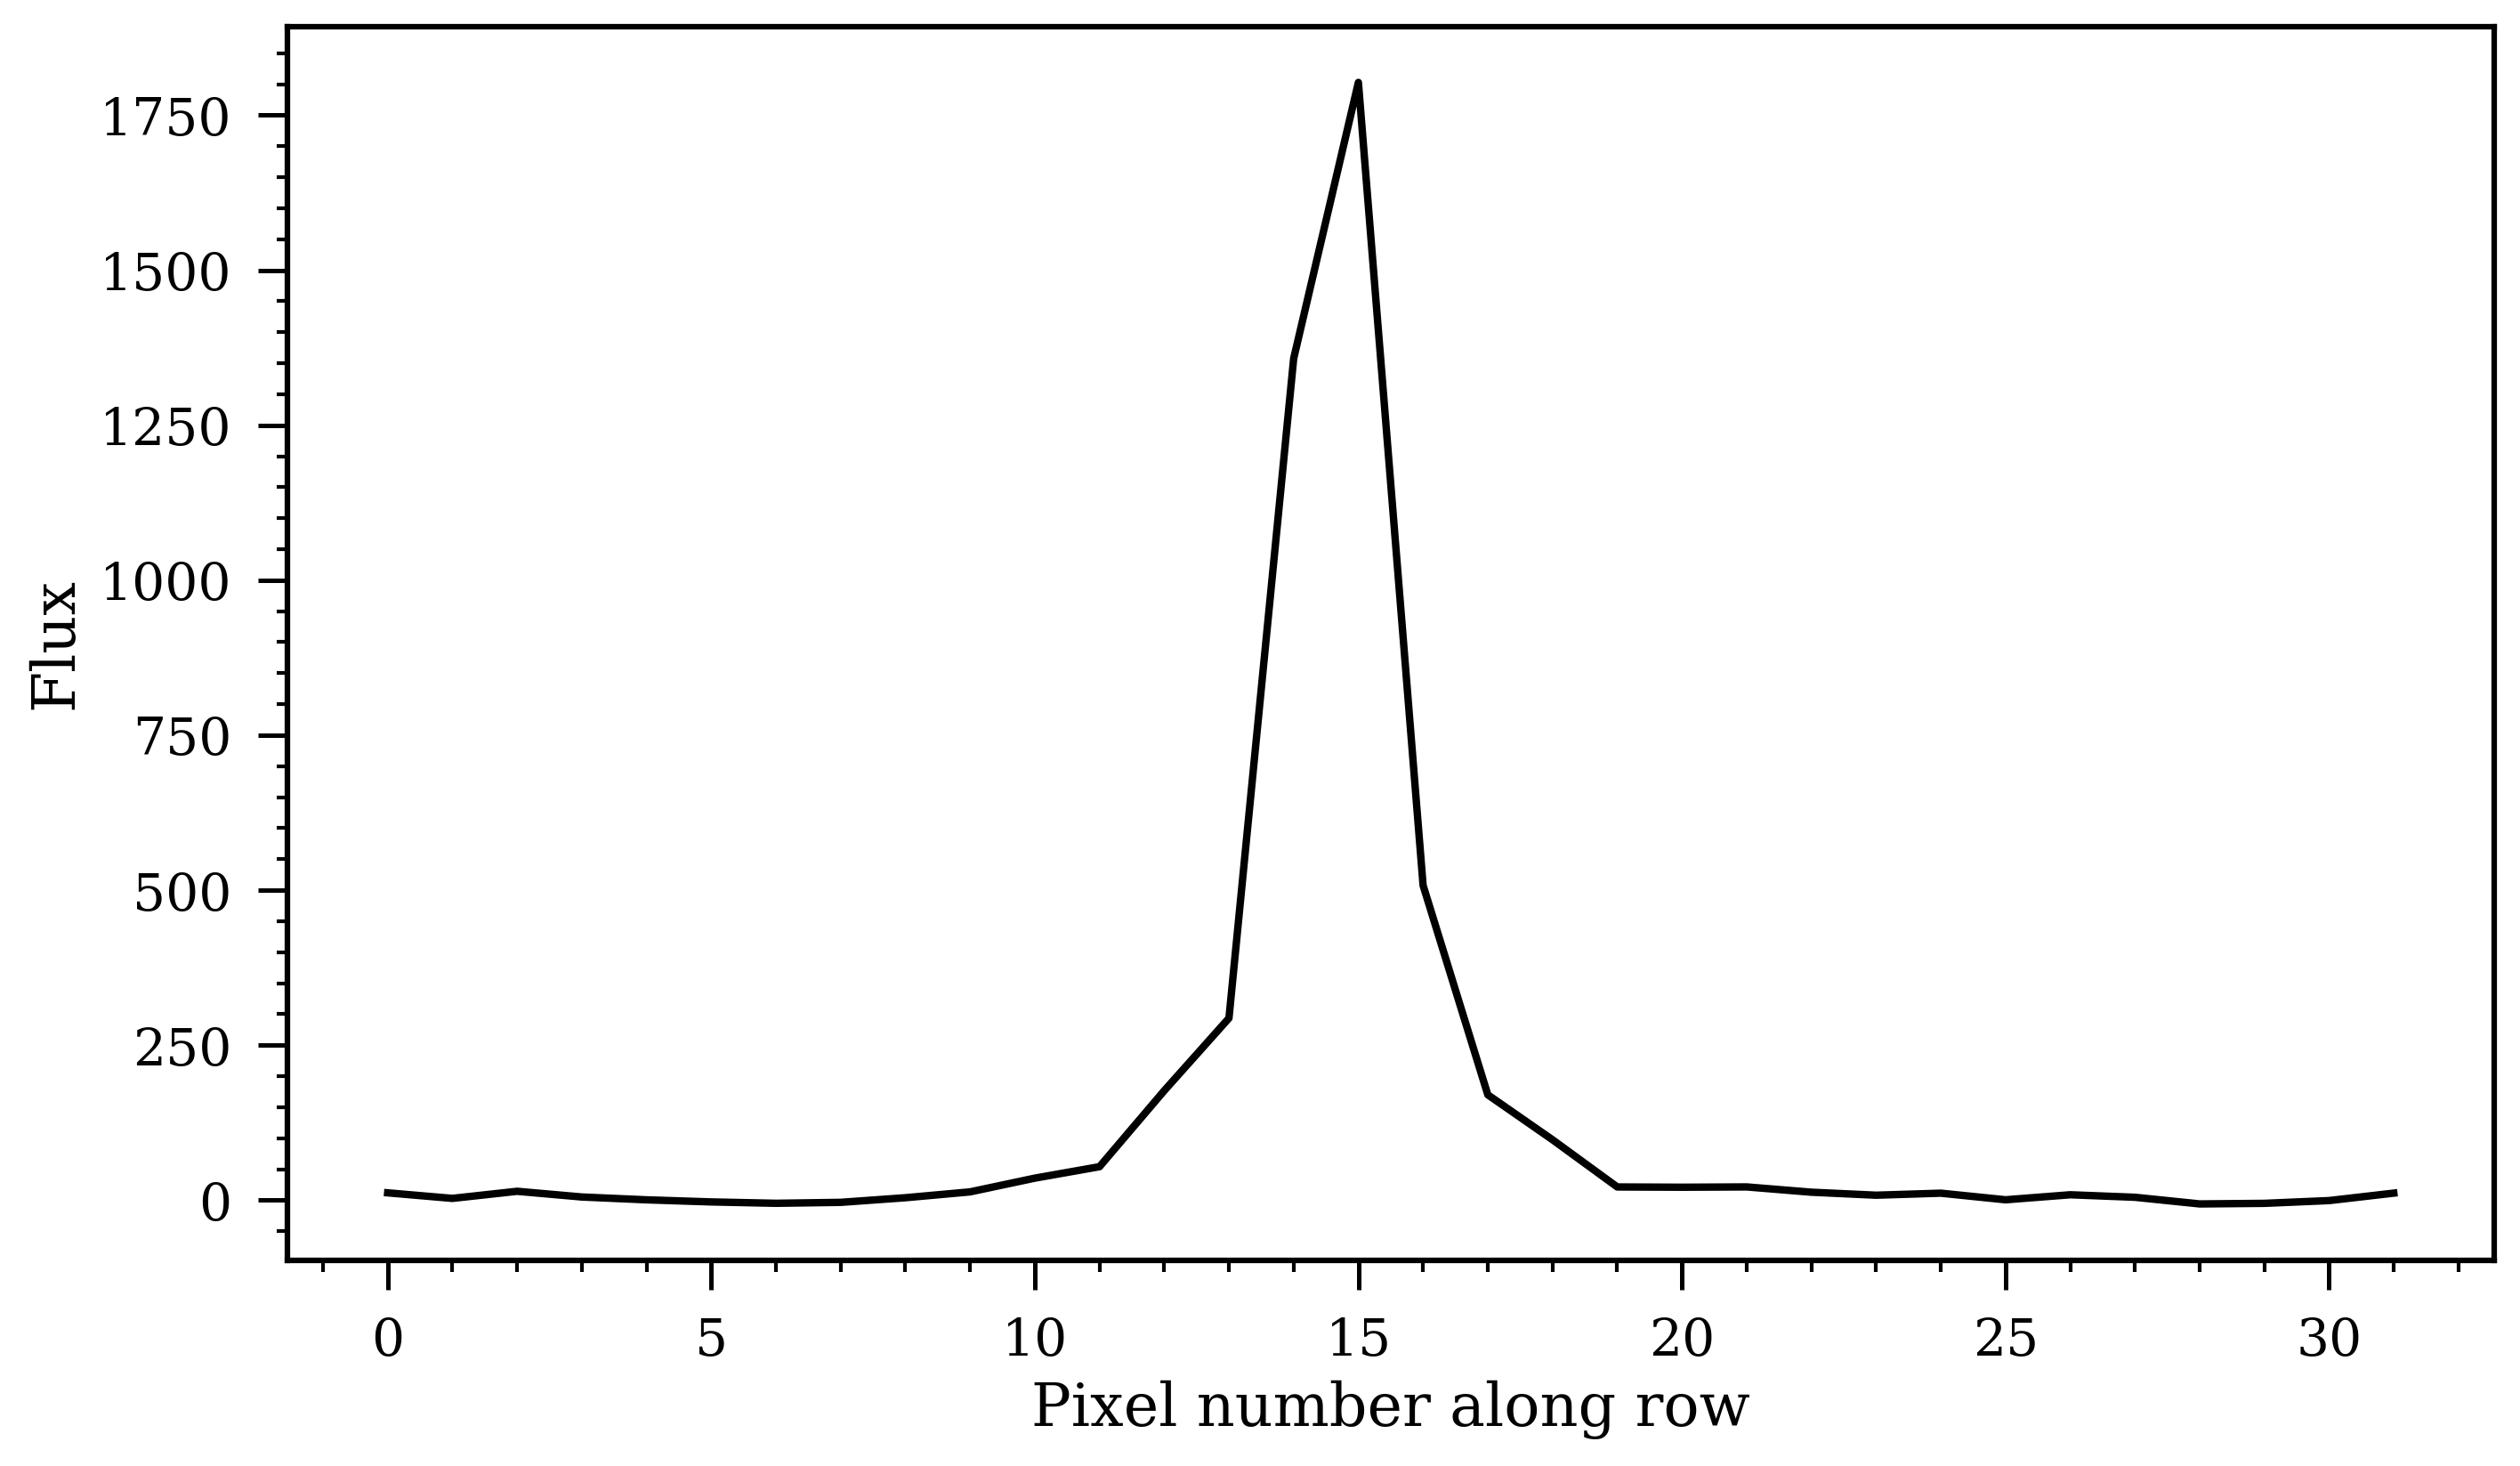

In [8]:
fig, axs = plt.subplots()
axs.plot( np.arange(corrected_data.shape[1]), corrected_data[nint, :, 400], 'k-' )
axs.set_xlabel('Pixel number along row')
axs.set_ylabel('Flux')

Looks like the PSF is around 5 pixels wide. Just to be on the safe side, let's define background region as 12 pixels away from the centre of the trace.

Text(0.5, 1.0, 'Example data with the location of spectral trace and background mask')

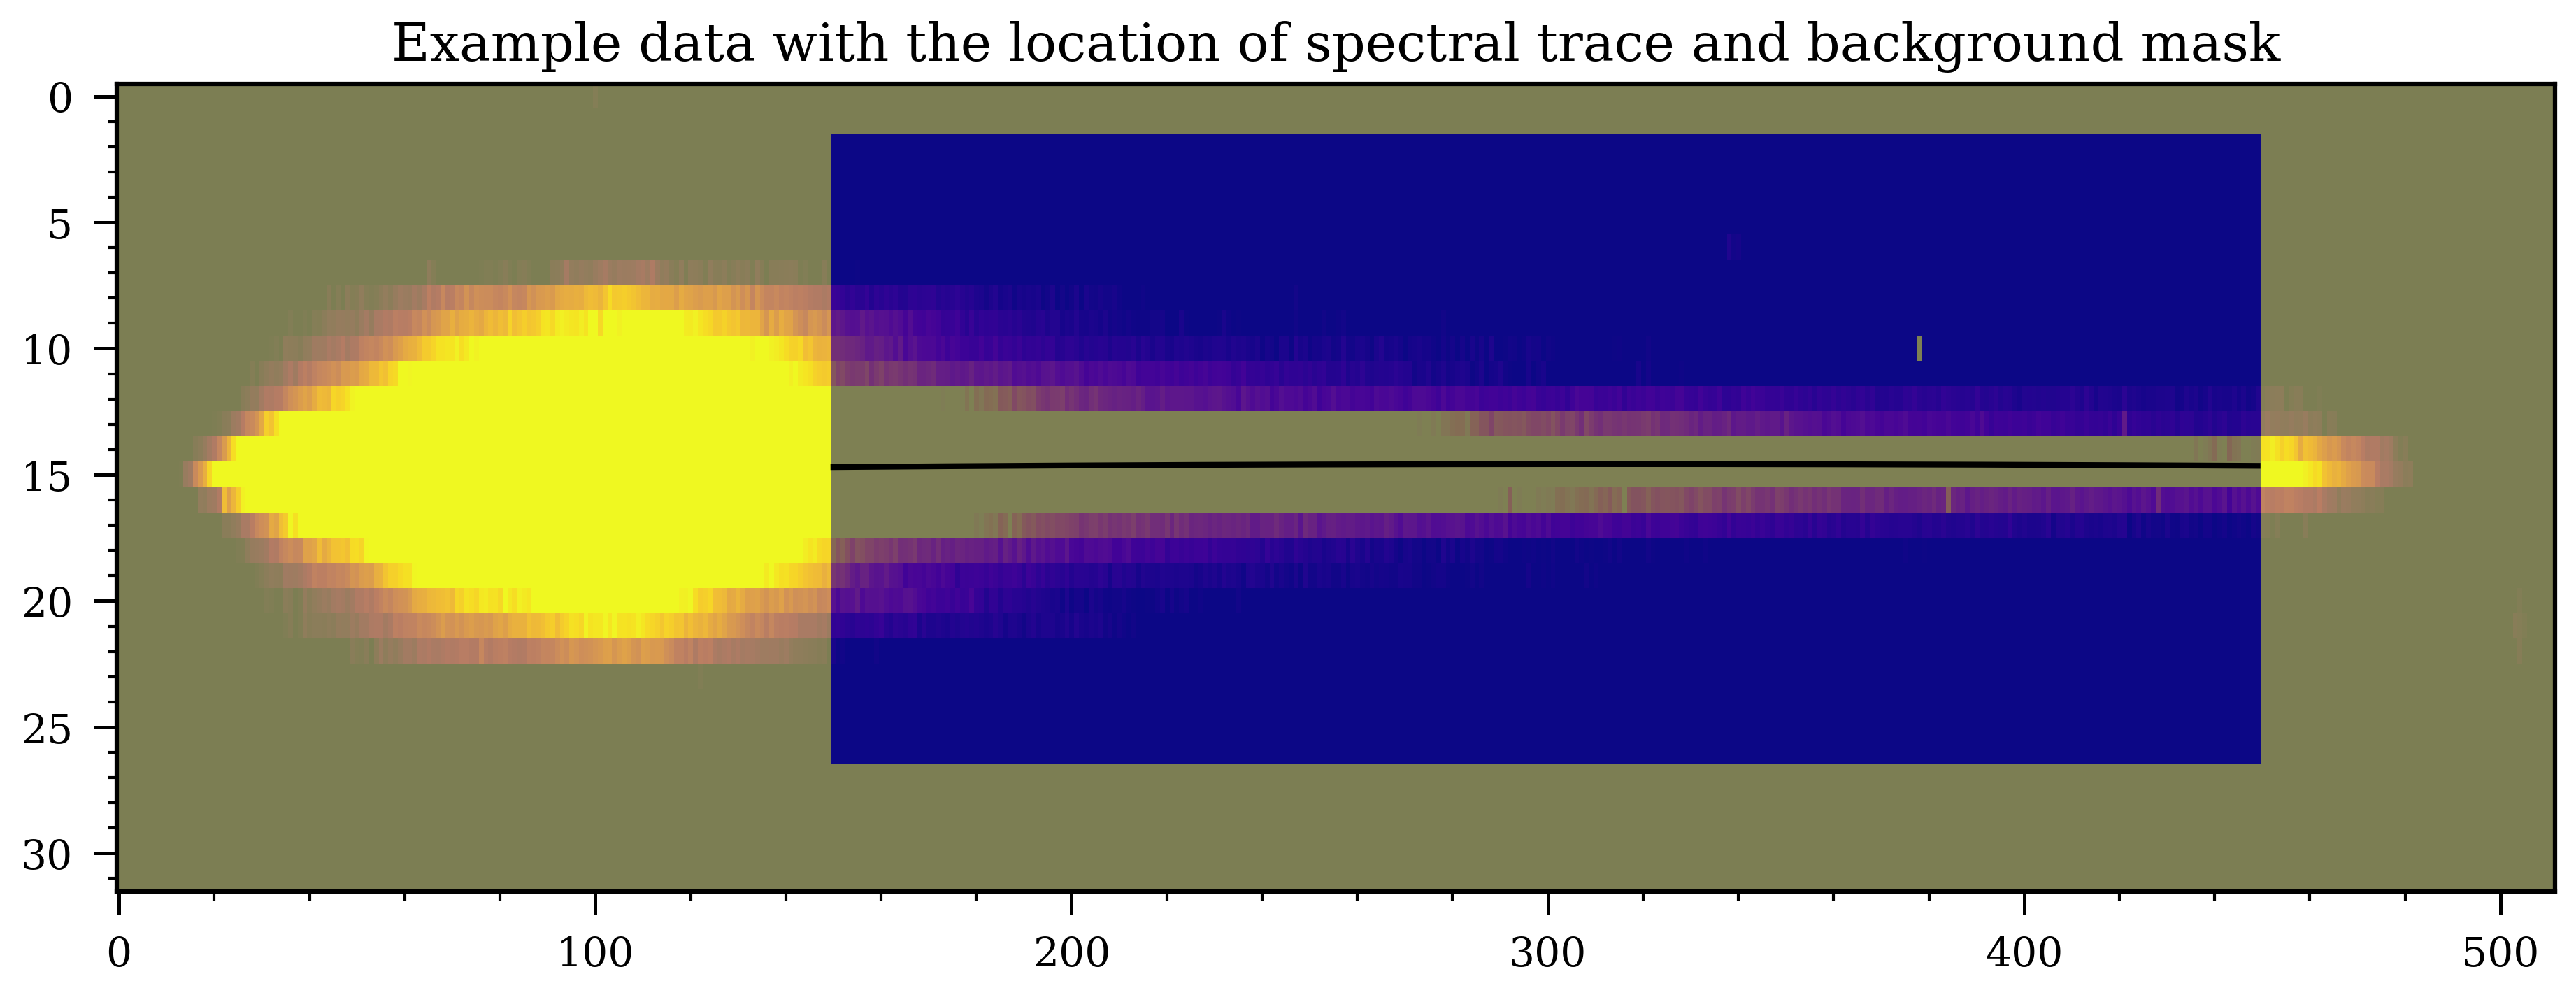

In [9]:
mask_bkg = np.ones(corrected_data[nint,:,:].shape)
for i in range(len(xpos)):
    mask_bkg[int(trace1[i]-12):int(trace1[i]+12+1), int(xpos[i])] = 0.

plt.figure(figsize=(15,5))
im = plt.imshow(corrected_data[nint,:,:], interpolation='none', aspect='auto', cmap='plasma')
plt.imshow(mask_bkg, interpolation='none', aspect='auto', alpha=0.5)
im.set_clim([1e2,1e3])
plt.plot(xpos, trace1, 'k-')
plt.title('Example data with the location of spectral trace and background mask')

Awesome! Now, let's perform the column-by-column background subtraction.

In [10]:
for i in tqdm(range(corrected_data.shape[0])):
    corrected_data[i,:,:], _ = reduce.col_by_col_bkg_sub(corrected_data[i,:,:], mask=mask_bkg*mask_bcr[i,:,:])

100%|██████████| 3200/3200 [00:18<00:00, 169.00it/s]


Now, let's plot flux along an arbitrary row and column to make sure that we perform the background subtraction correctly. I will also plot an arbitrary image frame to see how it looks.

Text(0.5, 1.0, 'Example data with the location of spectral trace')

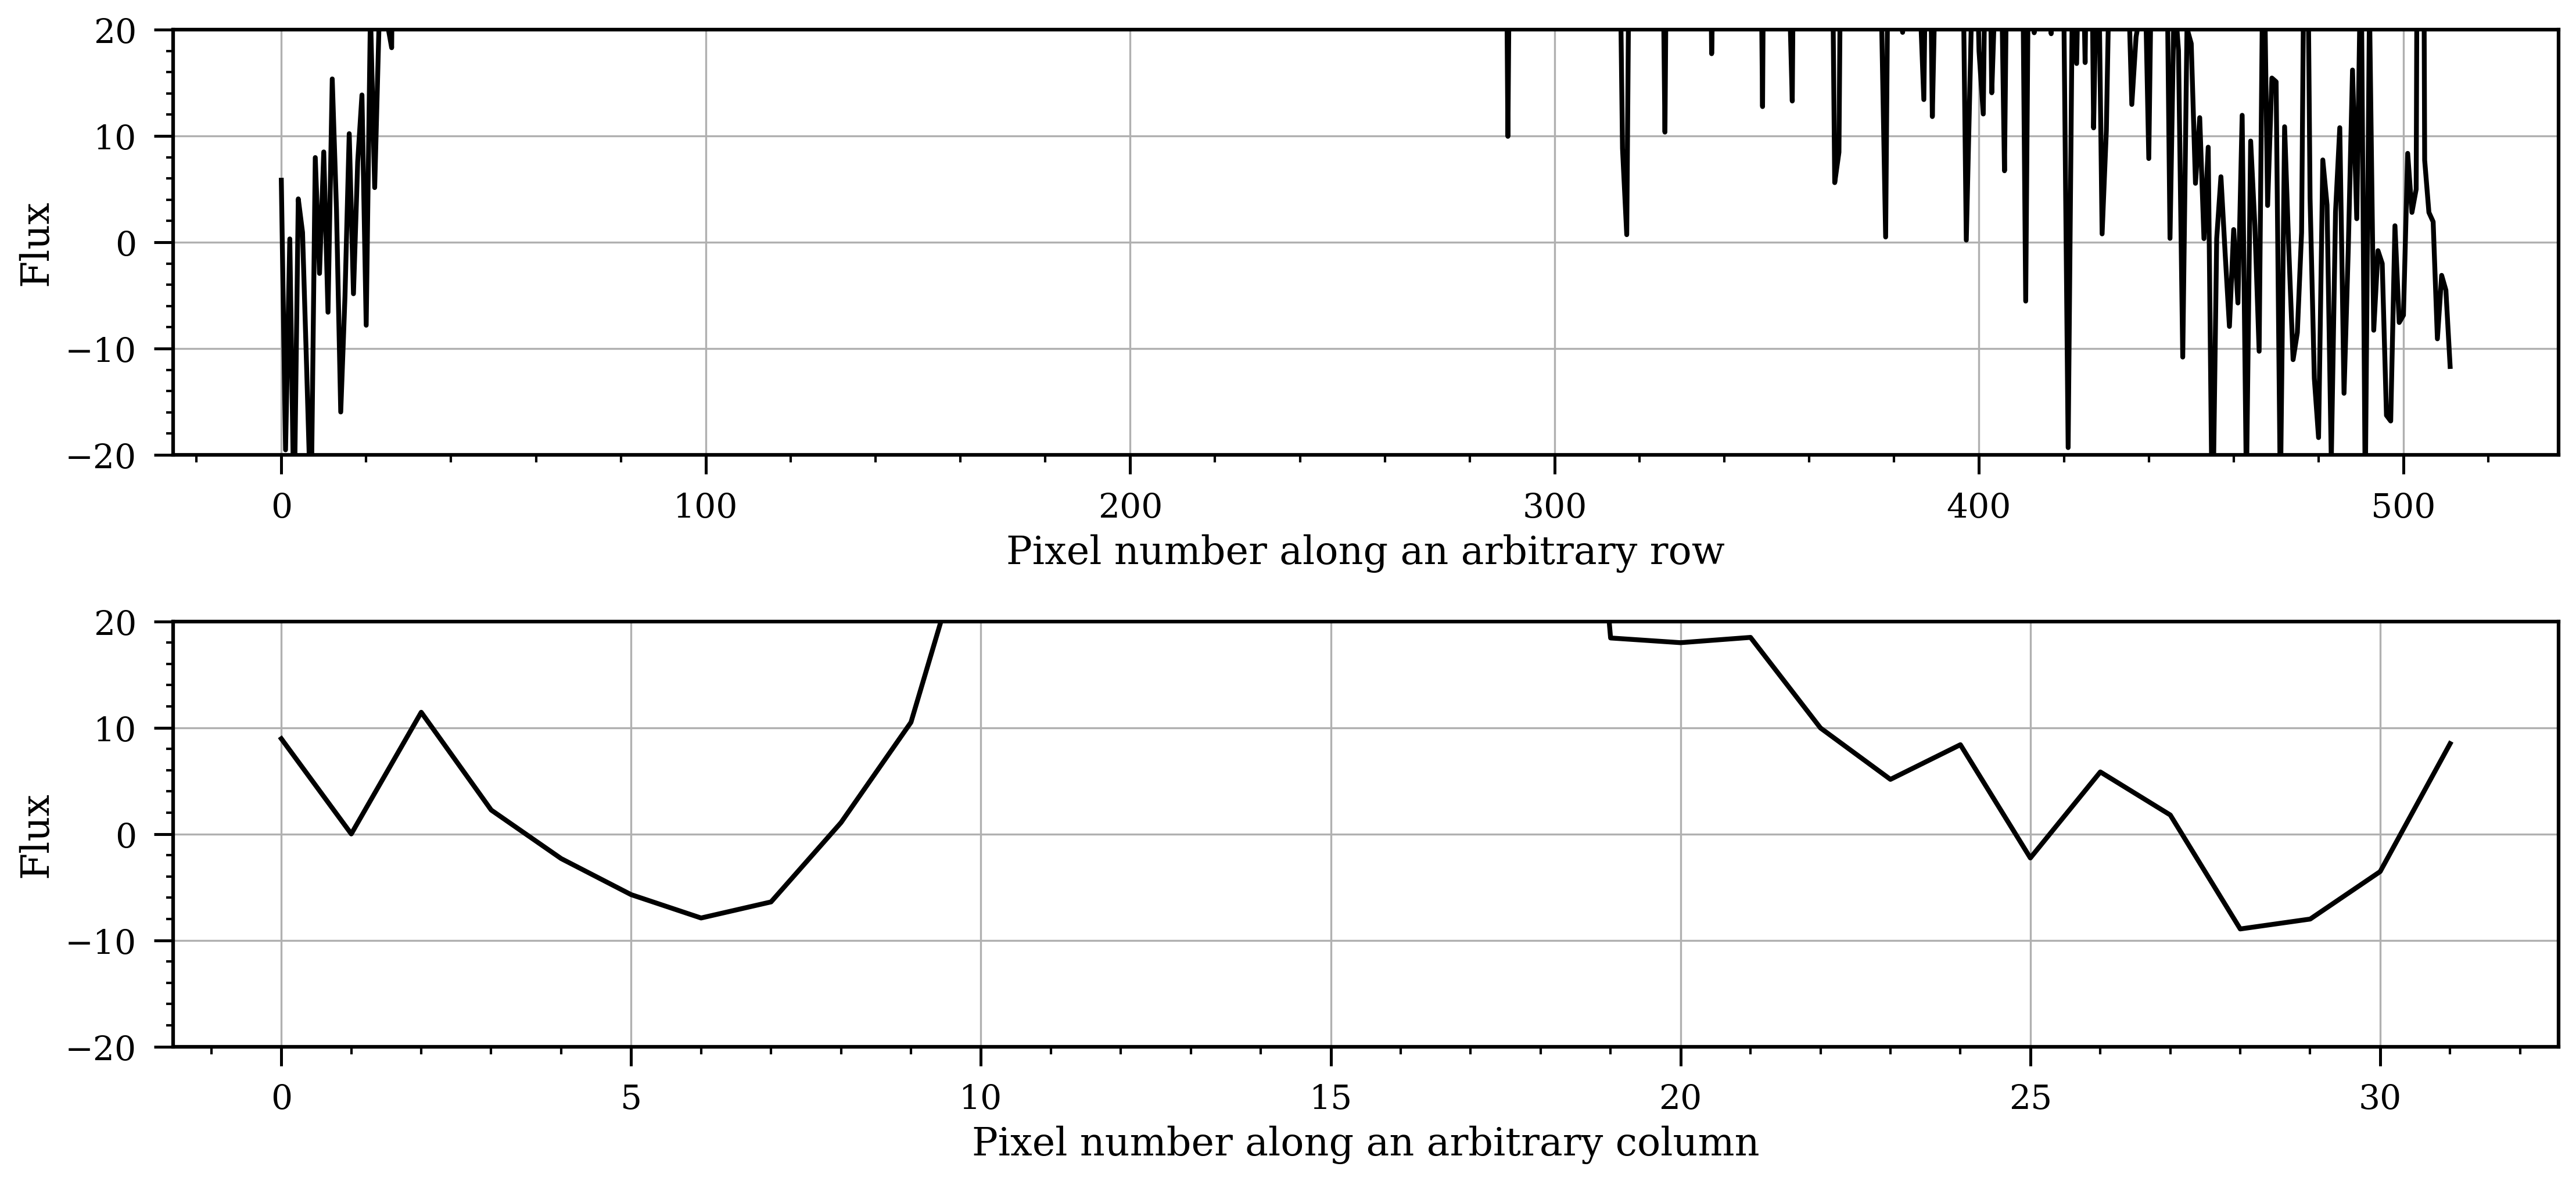

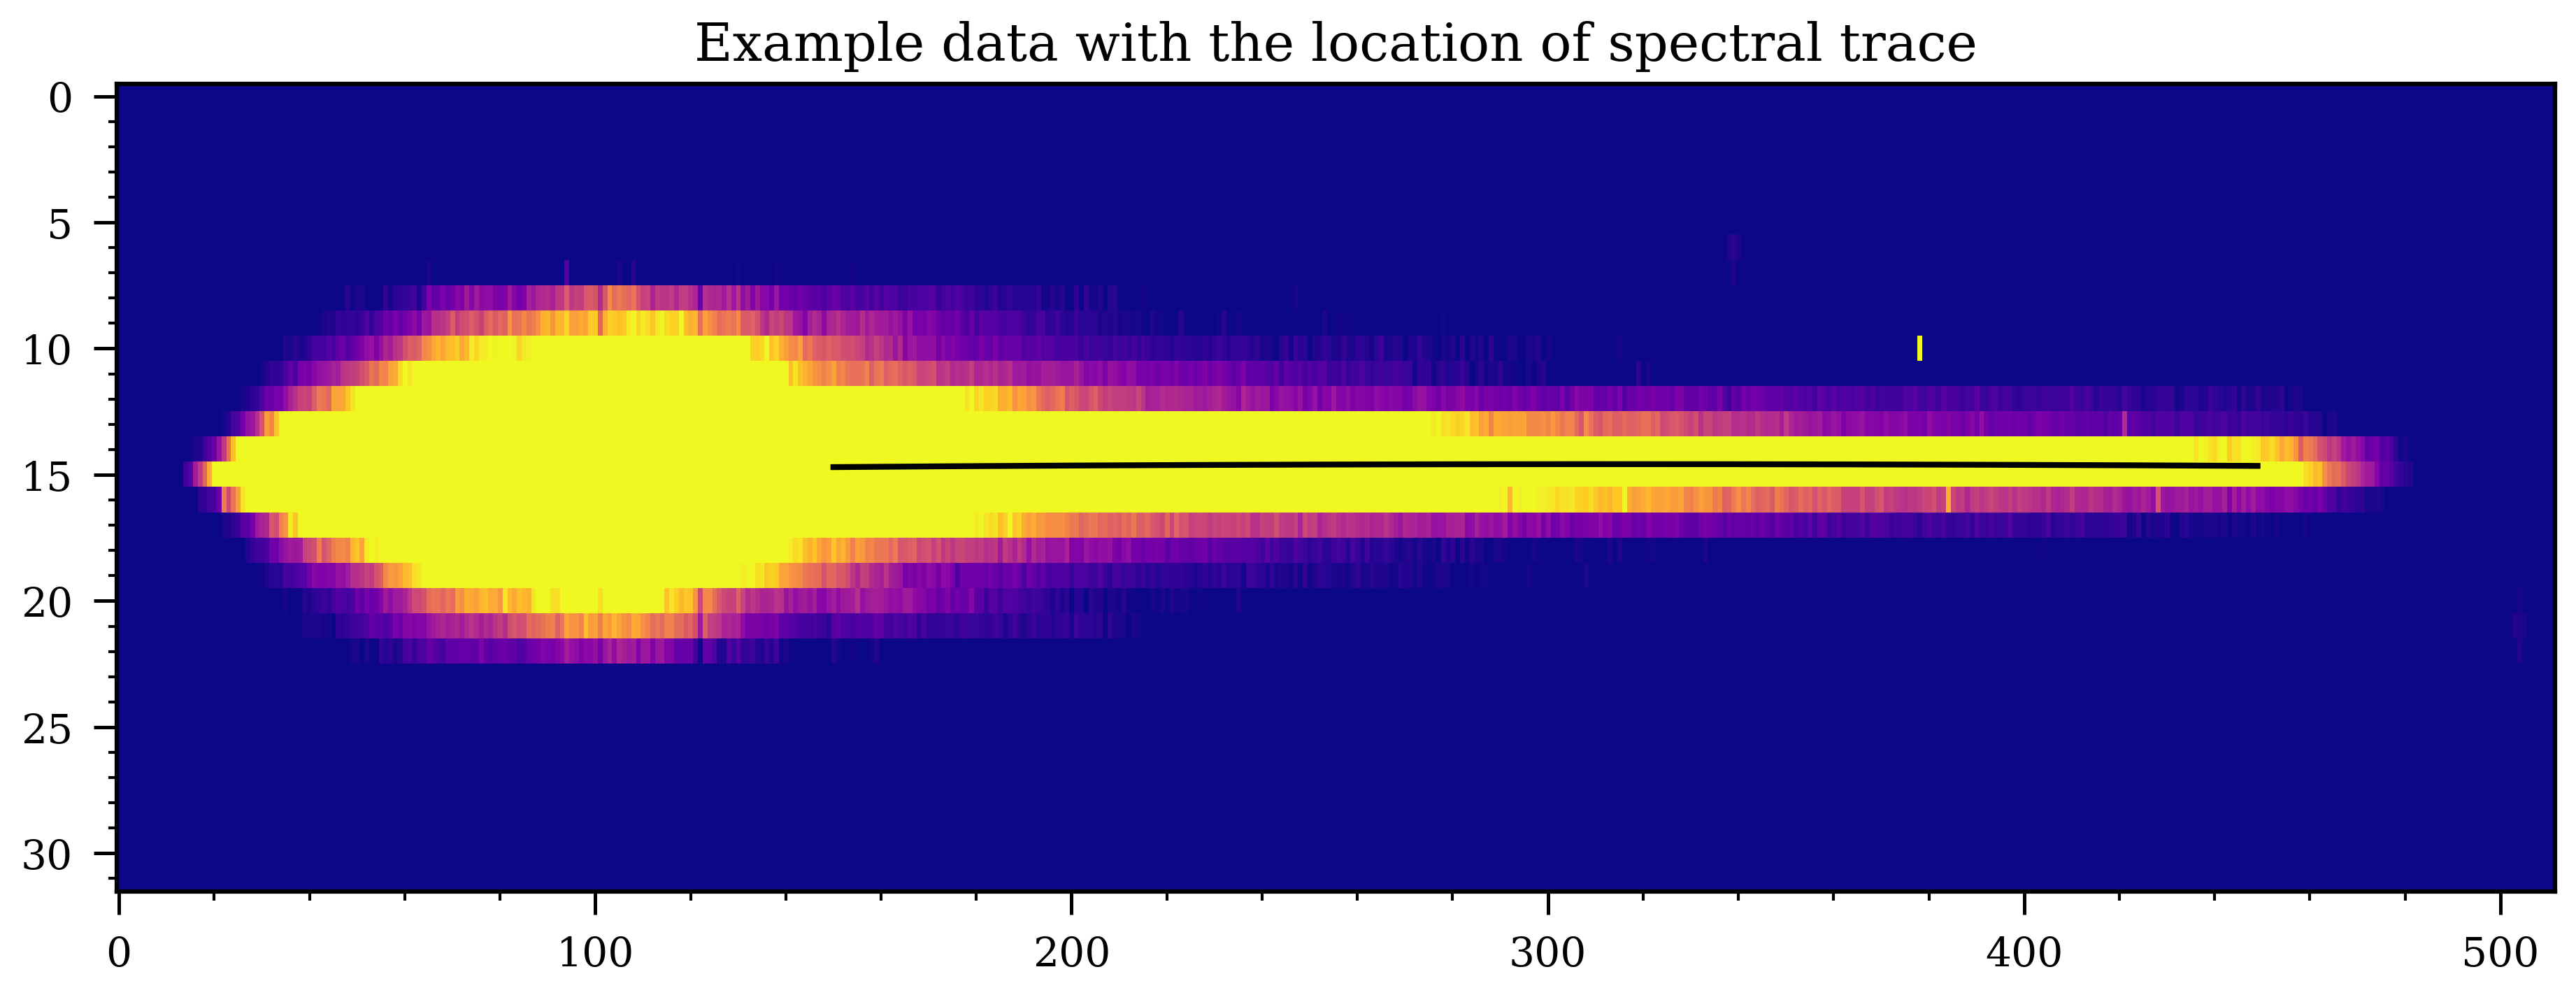

In [11]:
# -------------------------------------------------
# Plotting the flux along an arbitrary row and column
# -------------------------------------------------

fig, axs = plt.subplots( 2, 1, figsize=(15,7) )

## Flux along an arbitrary row
axs[0].plot( np.arange(corrected_data.shape[2]), corrected_data[nint, 20, :], 'k-' )
axs[0].set_xlabel('Pixel number along an arbitrary row')
axs[0].set_ylabel('Flux')
axs[0].set_ylim([-20, 20])

axs[0].grid()

## Flux along an arbitrary column
axs[1].plot( np.arange(corrected_data.shape[1]), corrected_data[nint, :, 400], 'k-' )
axs[1].set_xlabel('Pixel number along an arbitrary column')
axs[1].set_ylabel('Flux')
axs[1].set_ylim([-20, 20])
axs[1].grid()

plt.tight_layout()

# -------------------------------------------------
#  Plotting an arbitrary frame
# -------------------------------------------------
plt.figure(figsize=(15,5))
im = plt.imshow(corrected_data[nint,:,:], interpolation='none', aspect='auto')
im.set_clim([1e2,1e3])
plt.plot(xpos, trace1, 'k-')
plt.title('Example data with the location of spectral trace')

Okay! Now we will perform the spectral extraction. Let's try to define the centroids again on the background subtracted data, and see if it changes significantly from previous.

There are some integrations in which some of the columns (full columns) are bad -- normally, we should mask that particular column in that particular integration as bad. However, that would require some extra work from my side (because, we cannot simply mask one column in one integration -- that would create shape issues in the pipeline -- to avoid that I would have to "repair" that column, and create another mask that can tell me that this column in this integration is bad so that I can avoid that data point in transit timeseries fitting). To simplify the things I will simply mask the whole integration as bad.

In [12]:
## Identifying bad integrations
bad_ints, _, _ = np.where(np.isnan(corrected_data[:,:,xstart:xend]))
bad_ints = np.unique(bad_ints)

## Creating a mask for bad integrations
mask_bad_ints = np.ones(corrected_data.shape[0], dtype=bool)
mask_bad_ints[bad_ints] = False

## Masking bad integrations
corrected_data, corrected_errs = corrected_data[mask_bad_ints, :, :], corrected_errs[mask_bad_ints, :, :]
mask_bcr = mask_bcr[mask_bad_ints, :, :]
times_bjd = times_bjd[mask_bad_ints]

And, now the spectral trace

Scatter in trace position: 0.0051 pix


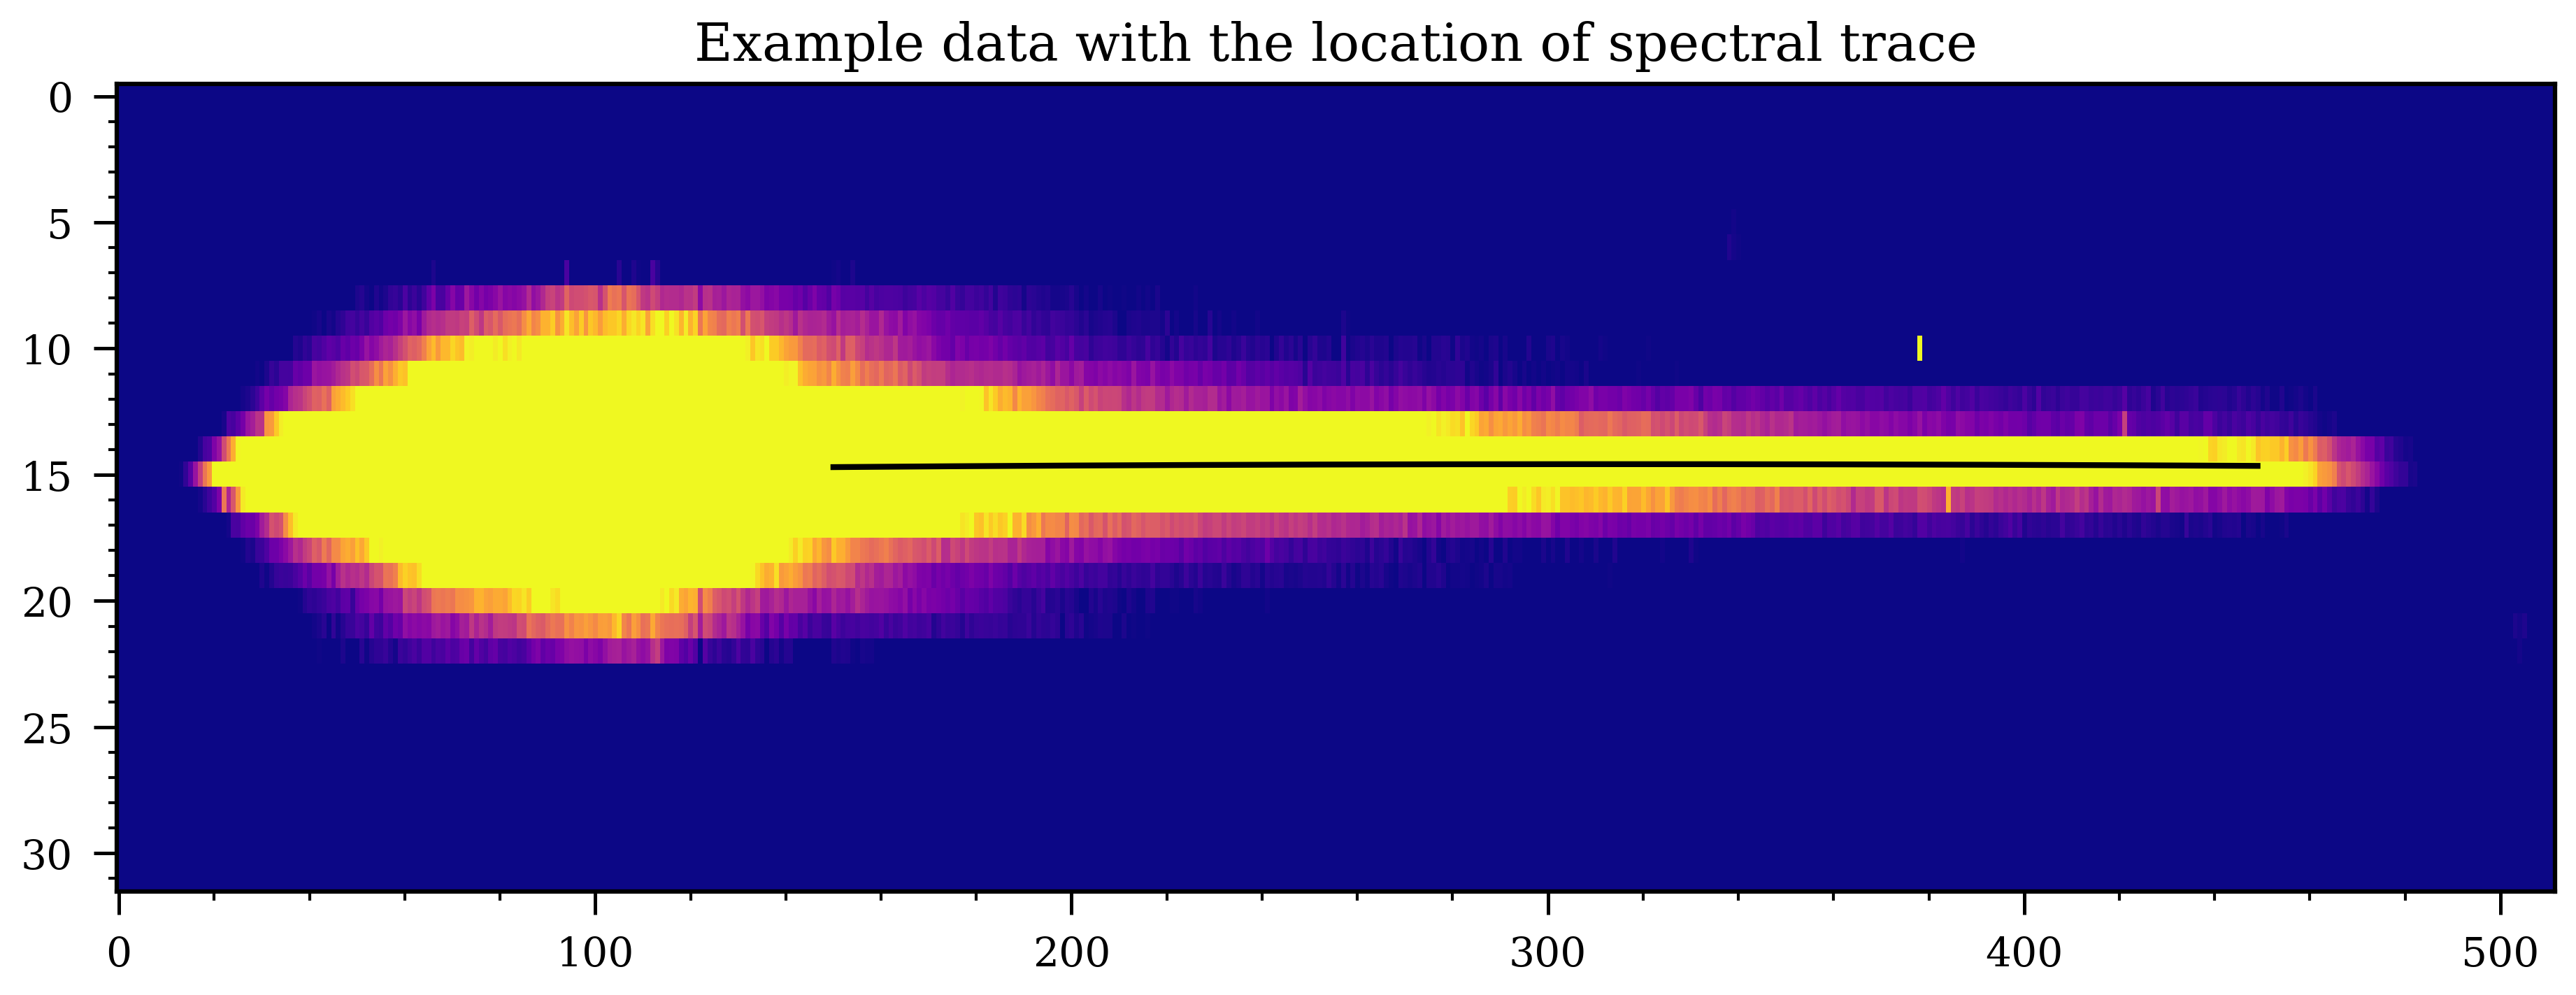

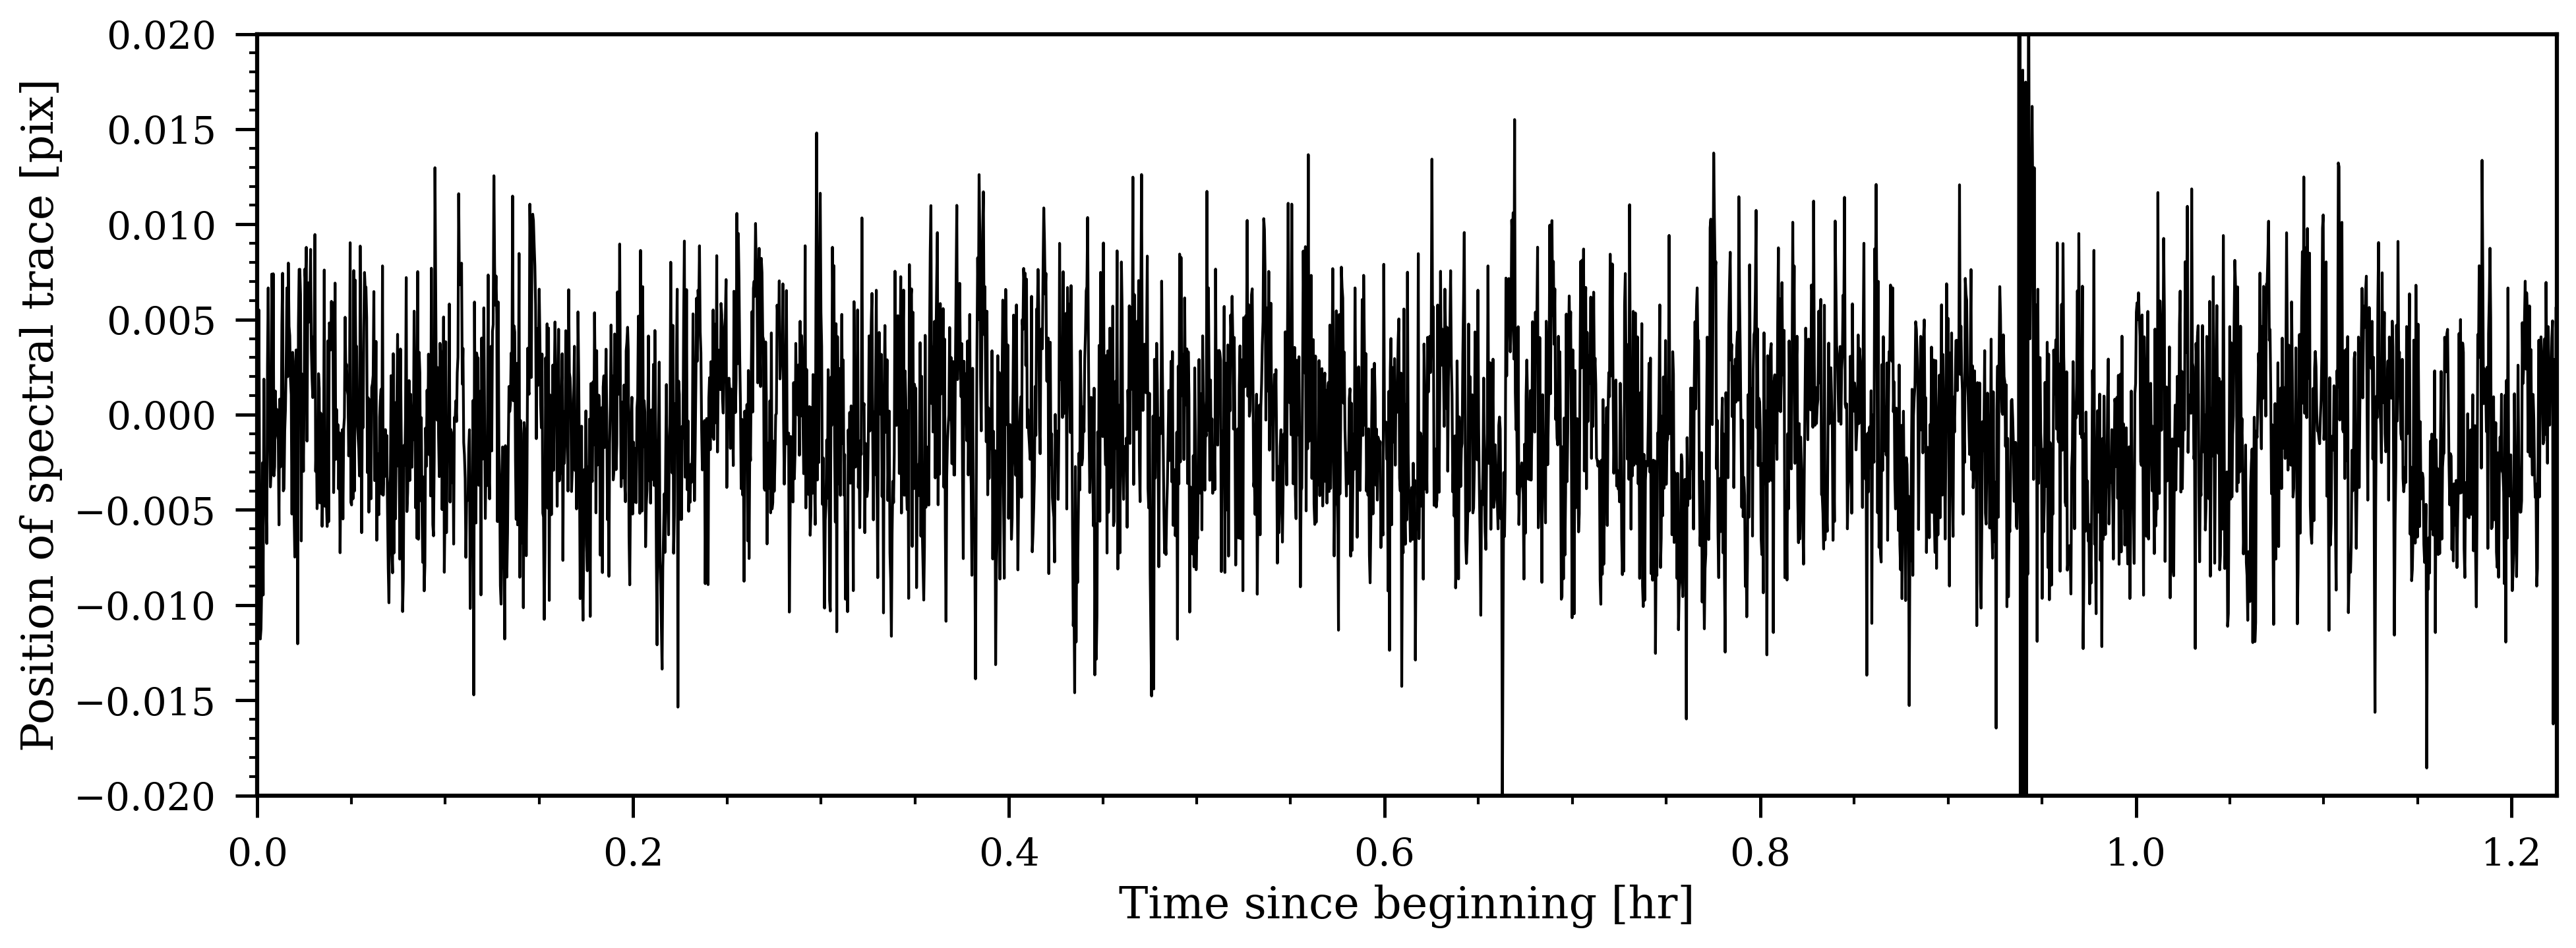

In [13]:
# -------------------------------------------------
#  Finding the spectral trace
# -------------------------------------------------

# Finding trace
cent_cub1 = poetss.find_trace_cof(clean_cube=corrected_data[:,:,xstart:xend], margin=5)
trace1, dx1 = poetss.fit_multi_trace(cent_mat=cent_cub1, deg=3, clip=3)
xpos = np.arange(xstart, xend, 1)

traces = {}
traces['xpos'], traces['trace1'], traces['dx1'] = xpos, trace1, dx1

## Saving the trace and the x positions for later use
np.savez(pout + '/Trace_seg004.npz', xpos=xpos, traces=trace1, dx1=dx1)

plt.figure(figsize=(15,5))
im = plt.imshow(corrected_data[nint,:,:], interpolation='none', aspect='auto')
im.set_clim([1e2,1e3])
plt.plot(xpos, trace1, 'k-')
plt.title('Example data with the location of spectral trace')

# Plotting the trace position as a function of time
plt.figure(figsize=(15,5))
plt.plot( (times_bjd - times_bjd[0])*24, dx1, 'k-', lw=1.)
plt.xlabel('Time since beginning [hr]')
plt.ylabel('Position of spectral trace [pix]')
plt.ylim([-0.02, 0.02])

plt.xlim(0, (times_bjd[-1] - times_bjd[0])*24)

print('Scatter in trace position: {:.4f} pix'.format(mad_std(dx1)))

Okay, so this is a bit better! Let's use this trace. First, let's estimate very rough stellar spectra using aperture extraction.

100%|██████████| 3198/3198 [00:03<00:00, 954.51it/s]


Text(0.5, 1.0, 'Timeseries of spectra')

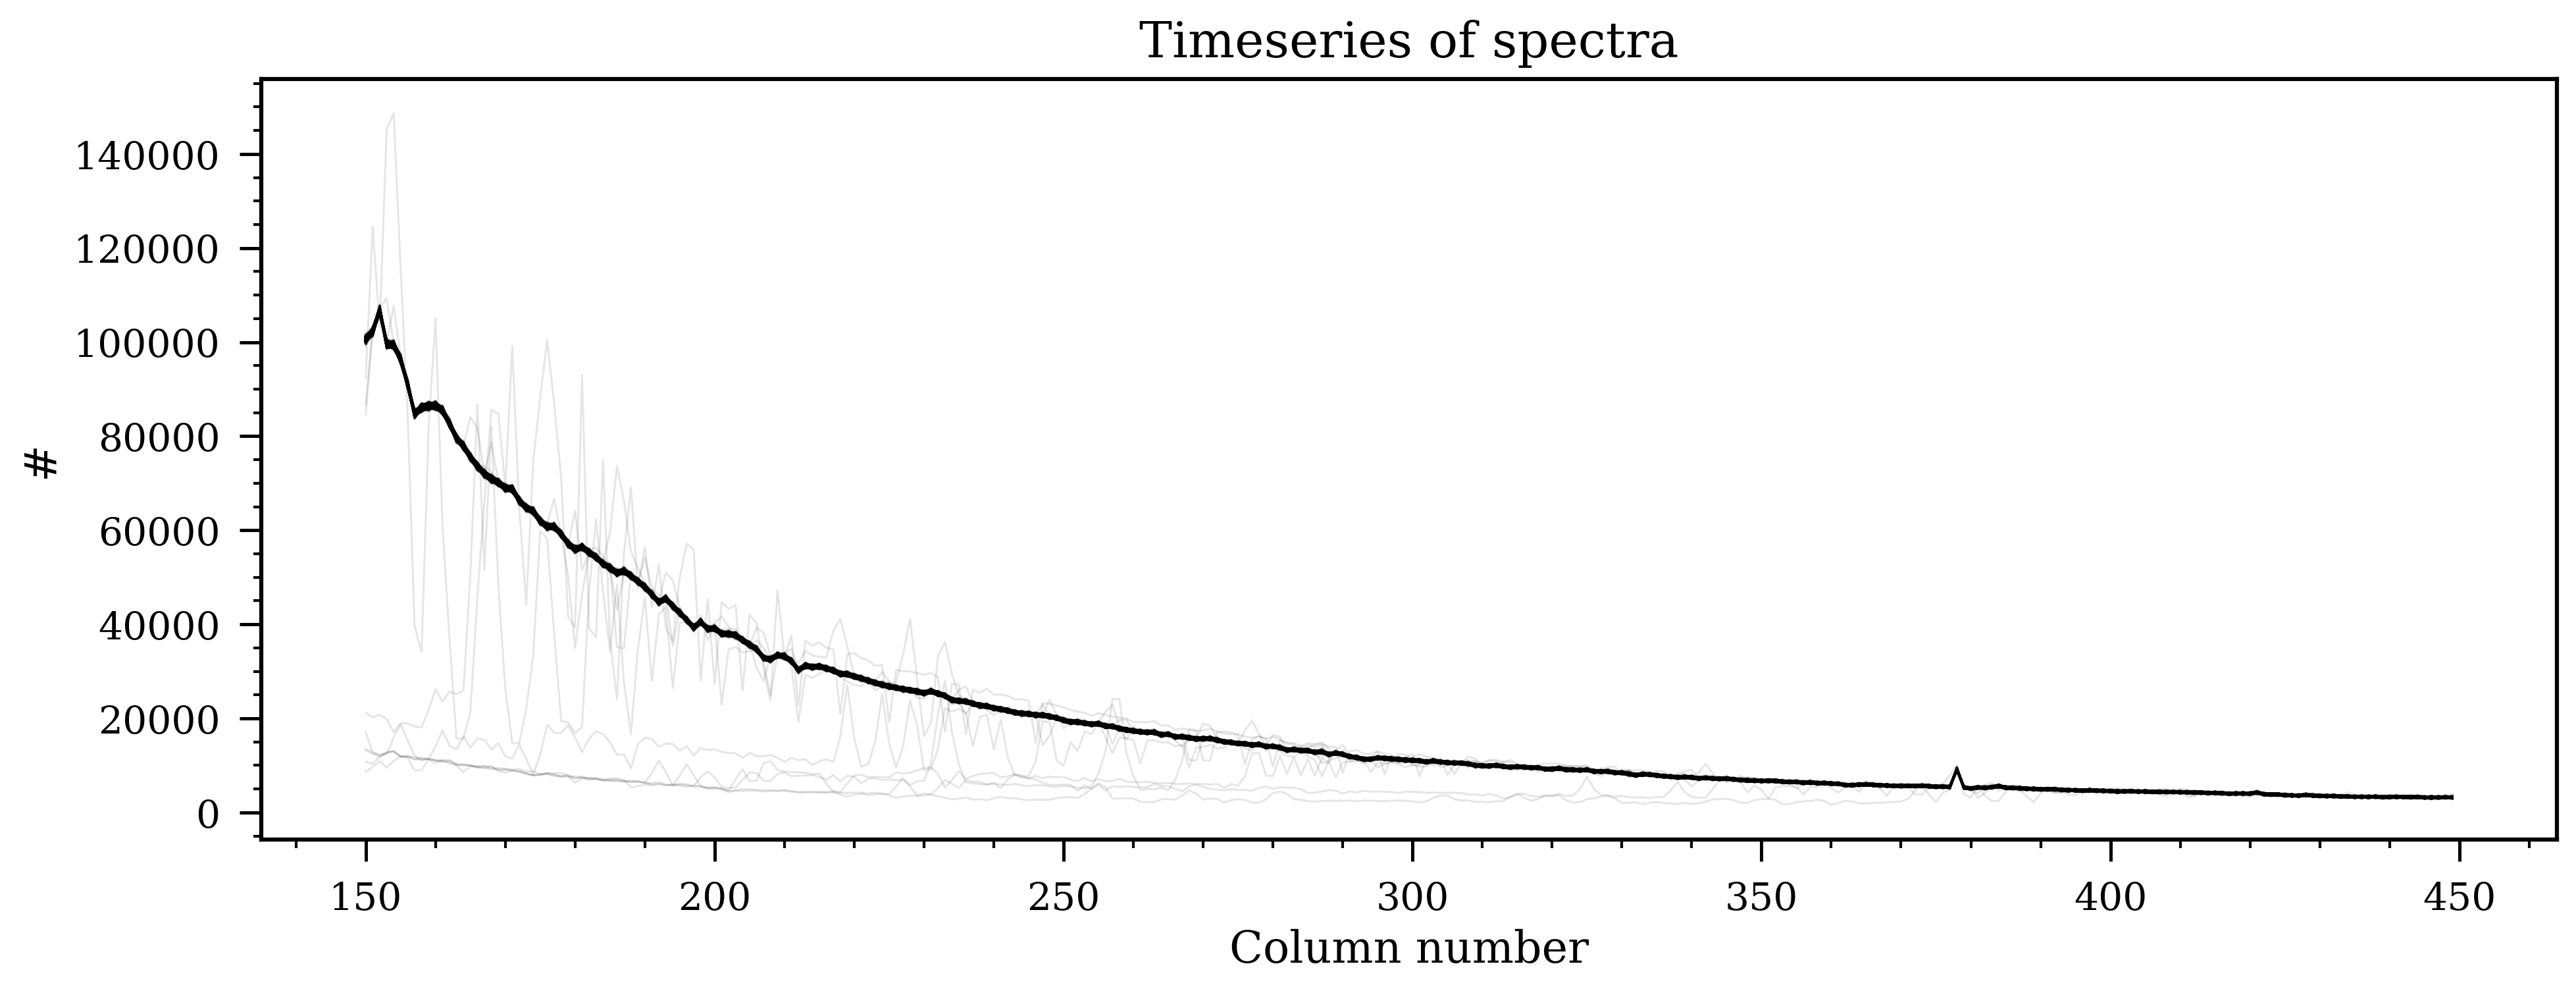

In [14]:
# ---------------------------------------------------
#  Converting 1D trace position to 2D
#  (i.e., trace for every frame)
# ---------------------------------------------------
ypos2d = np.zeros((corrected_data.shape[0], len(xpos)))
for i in range(ypos2d.shape[0]):
    ypos2d[i,:] = trace1 + dx1[i]

# ---------------------------------------------------
#   Aperture extraction
# ---------------------------------------------------
ap_spec1d, ap_var1d = np.zeros((corrected_data.shape[0], len(xpos))), np.zeros((corrected_data.shape[0], len(xpos)))
for inte in tqdm(range( ap_spec1d.shape[0] )):
    ap_spec1d[inte, :], ap_var1d[inte, :] = aperture_extract(frame=corrected_data[inte,:,xpos[0]:xpos[-1]+1],\
                                                             variance=corrected_errs[inte,:,xpos[0]:xpos[-1]+1]**2,\
                                                             ord_pos=ypos2d[inte,:], ap_rad=aprad_extraction)
    
# ----------------------------------------------------------
#    Plotting the extracted spectrum for all integrations
# ----------------------------------------------------------

plt.figure(figsize=(15,5))
for i in range(ap_spec1d.shape[0]):
    plt.plot(xpos, ap_spec1d[i,:], 'k', alpha=0.1, lw=0.7)
plt.xlabel('Column number')
plt.ylabel('#')
plt.title('Timeseries of spectra')

Okay, it's noisy! We cannot use this noisy spectra in estimating our PSF because this spectra will be used to normalise the data points. If we use this spectra, then it will introduce a lots of noise in the data points. So, let's smooth it -- we will first calculate the median spectrum from all these spectra, and then use this median spectra to flag all those points which are ~7 sigma away. We will replace these flagged points with the median of neighbouring pixels in wavelength space and in time.

Text(0.5, 1.0, 'Timeseries of spectra')

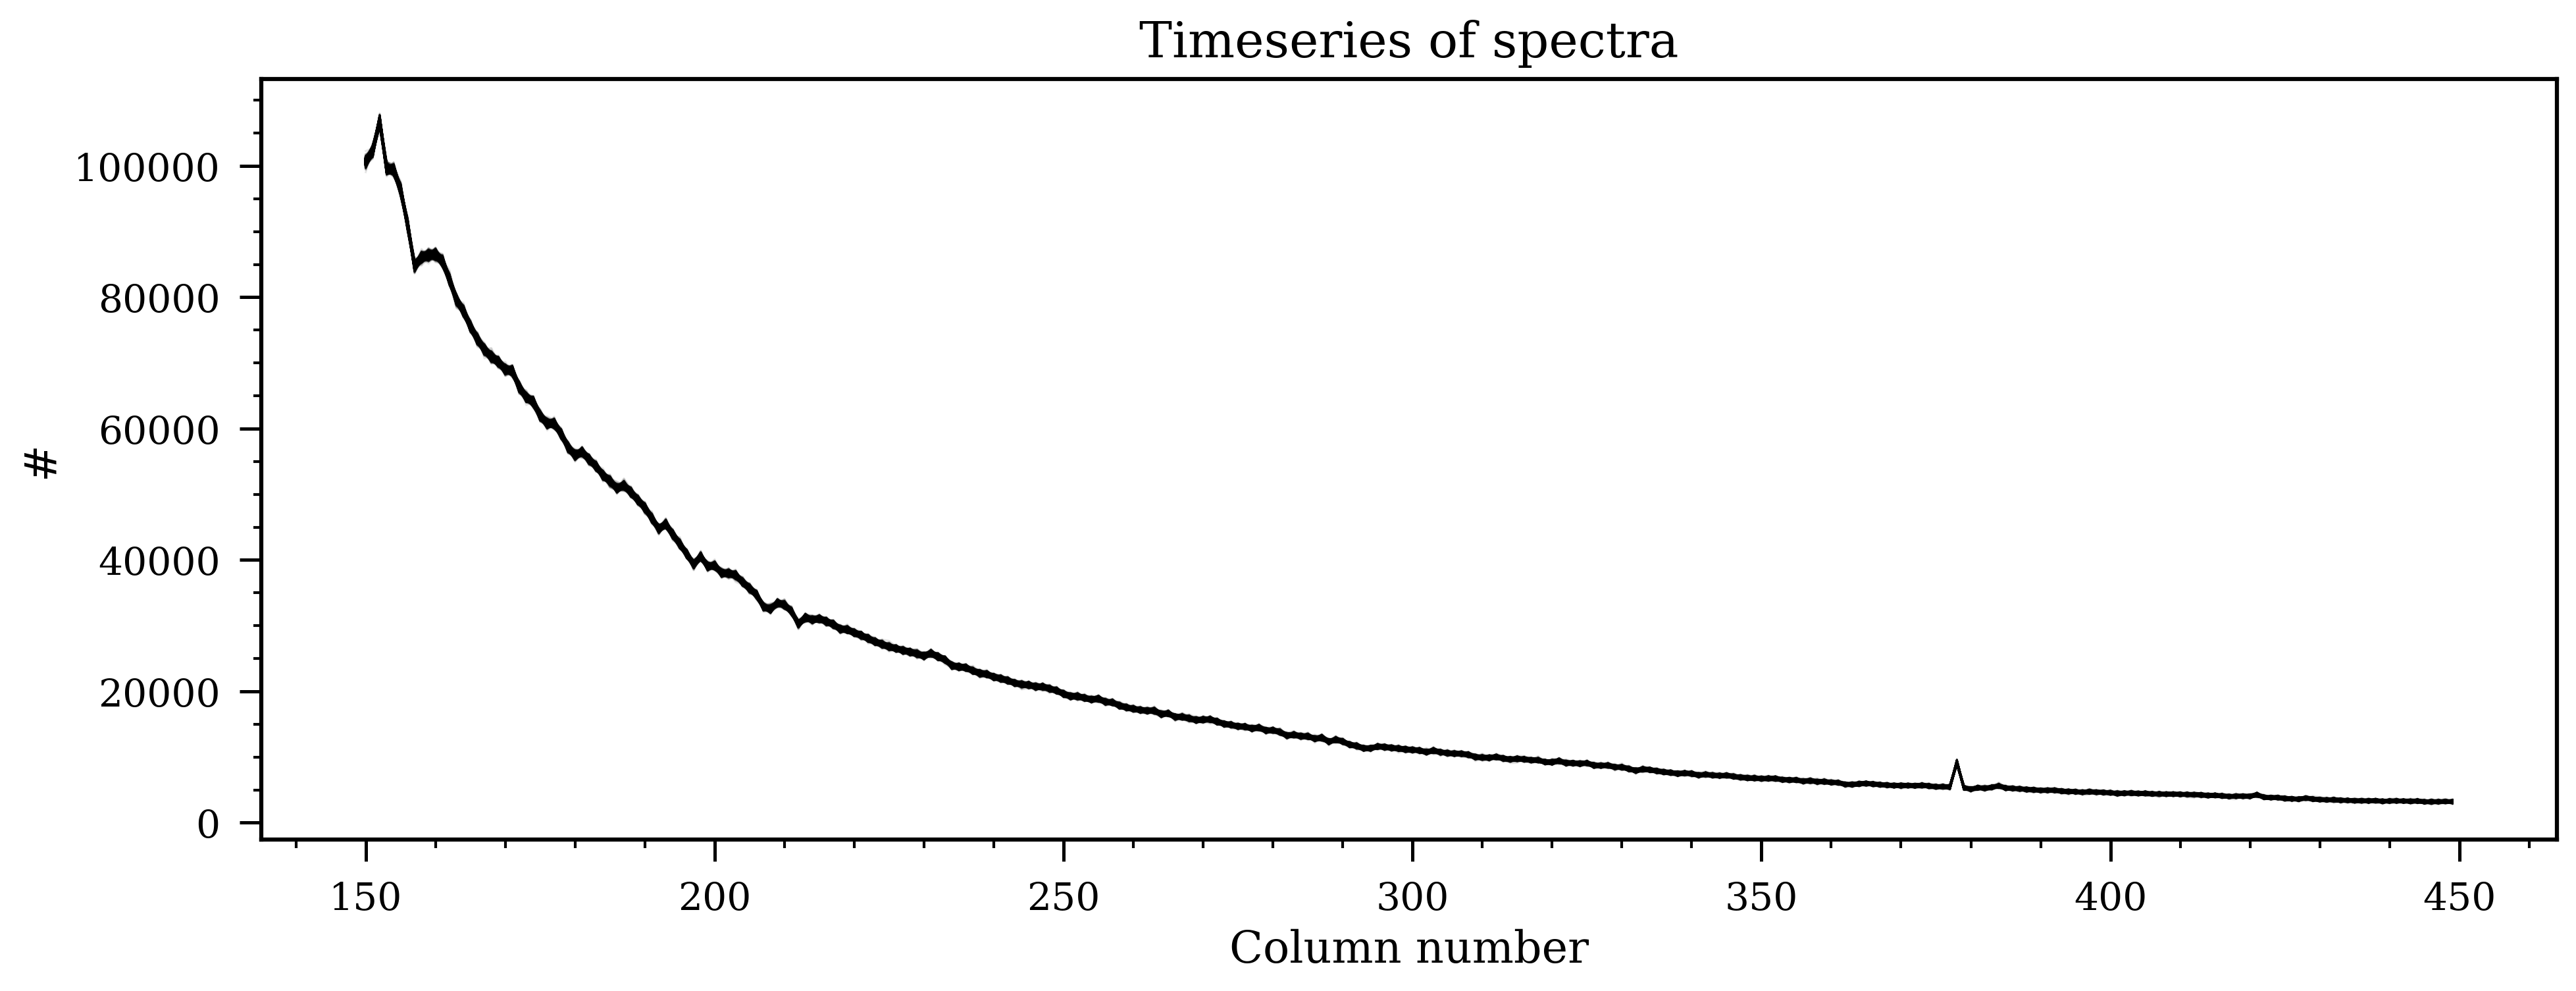

In [15]:
# ------ Calculating the median spectrum across all integrations ------
med_ap_spec1d = np.nanmedian(ap_spec1d, axis=0)

# ------- Calculating the residuals of the spectra with respect to the median spectrum ------
res_ap_spec1d = ap_spec1d - med_ap_spec1d

# ------ Calculating the threshold for identifying outliers in the residual spectra ------
limit = np.nanmedian(res_ap_spec1d, axis=0) + 5 * pipe_mad( res_ap_spec1d, axis=0 )

# ------ Creating a mask for outliers in the residual spectra ------
mask_outliers = np.ones(res_ap_spec1d.shape, dtype=bool)
for i in range(res_ap_spec1d.shape[0]):
    mask_outliers[i, :] = np.where(np.abs(res_ap_spec1d[i, :]) > limit, False, True)

# ------ Replacing the outliers in the original spectra with median spectrum ------
ap_spec1d_clipped = np.copy(ap_spec1d)
for i in range(ap_spec1d_clipped.shape[0]):
    ap_spec1d_clipped[i, :] = np.where(mask_outliers[i, :], ap_spec1d_clipped[i, :], med_ap_spec1d)

# ----------------------------------------------------------
#    Plotting the clipped spectra for all integrations
# ----------------------------------------------------------
plt.figure(figsize=(15,5))
for i in range(ap_spec1d.shape[0]):
    plt.plot(xpos, ap_spec1d_clipped[i,:], 'k', alpha=0.1, lw=0.7)
plt.xlabel('Column number')
plt.ylabel('#')
plt.title('Timeseries of spectra')

This is great! We already reduced a lot of scatter in the light curve! We can now use this light curve to fit a univariate spline to estimate the PSF.

Iter 1 / 3: 0.54526 per cent masked.
Iter 2 / 3: 0.54526 per cent masked.
Iter 3 / 3: 0.54526 per cent masked.


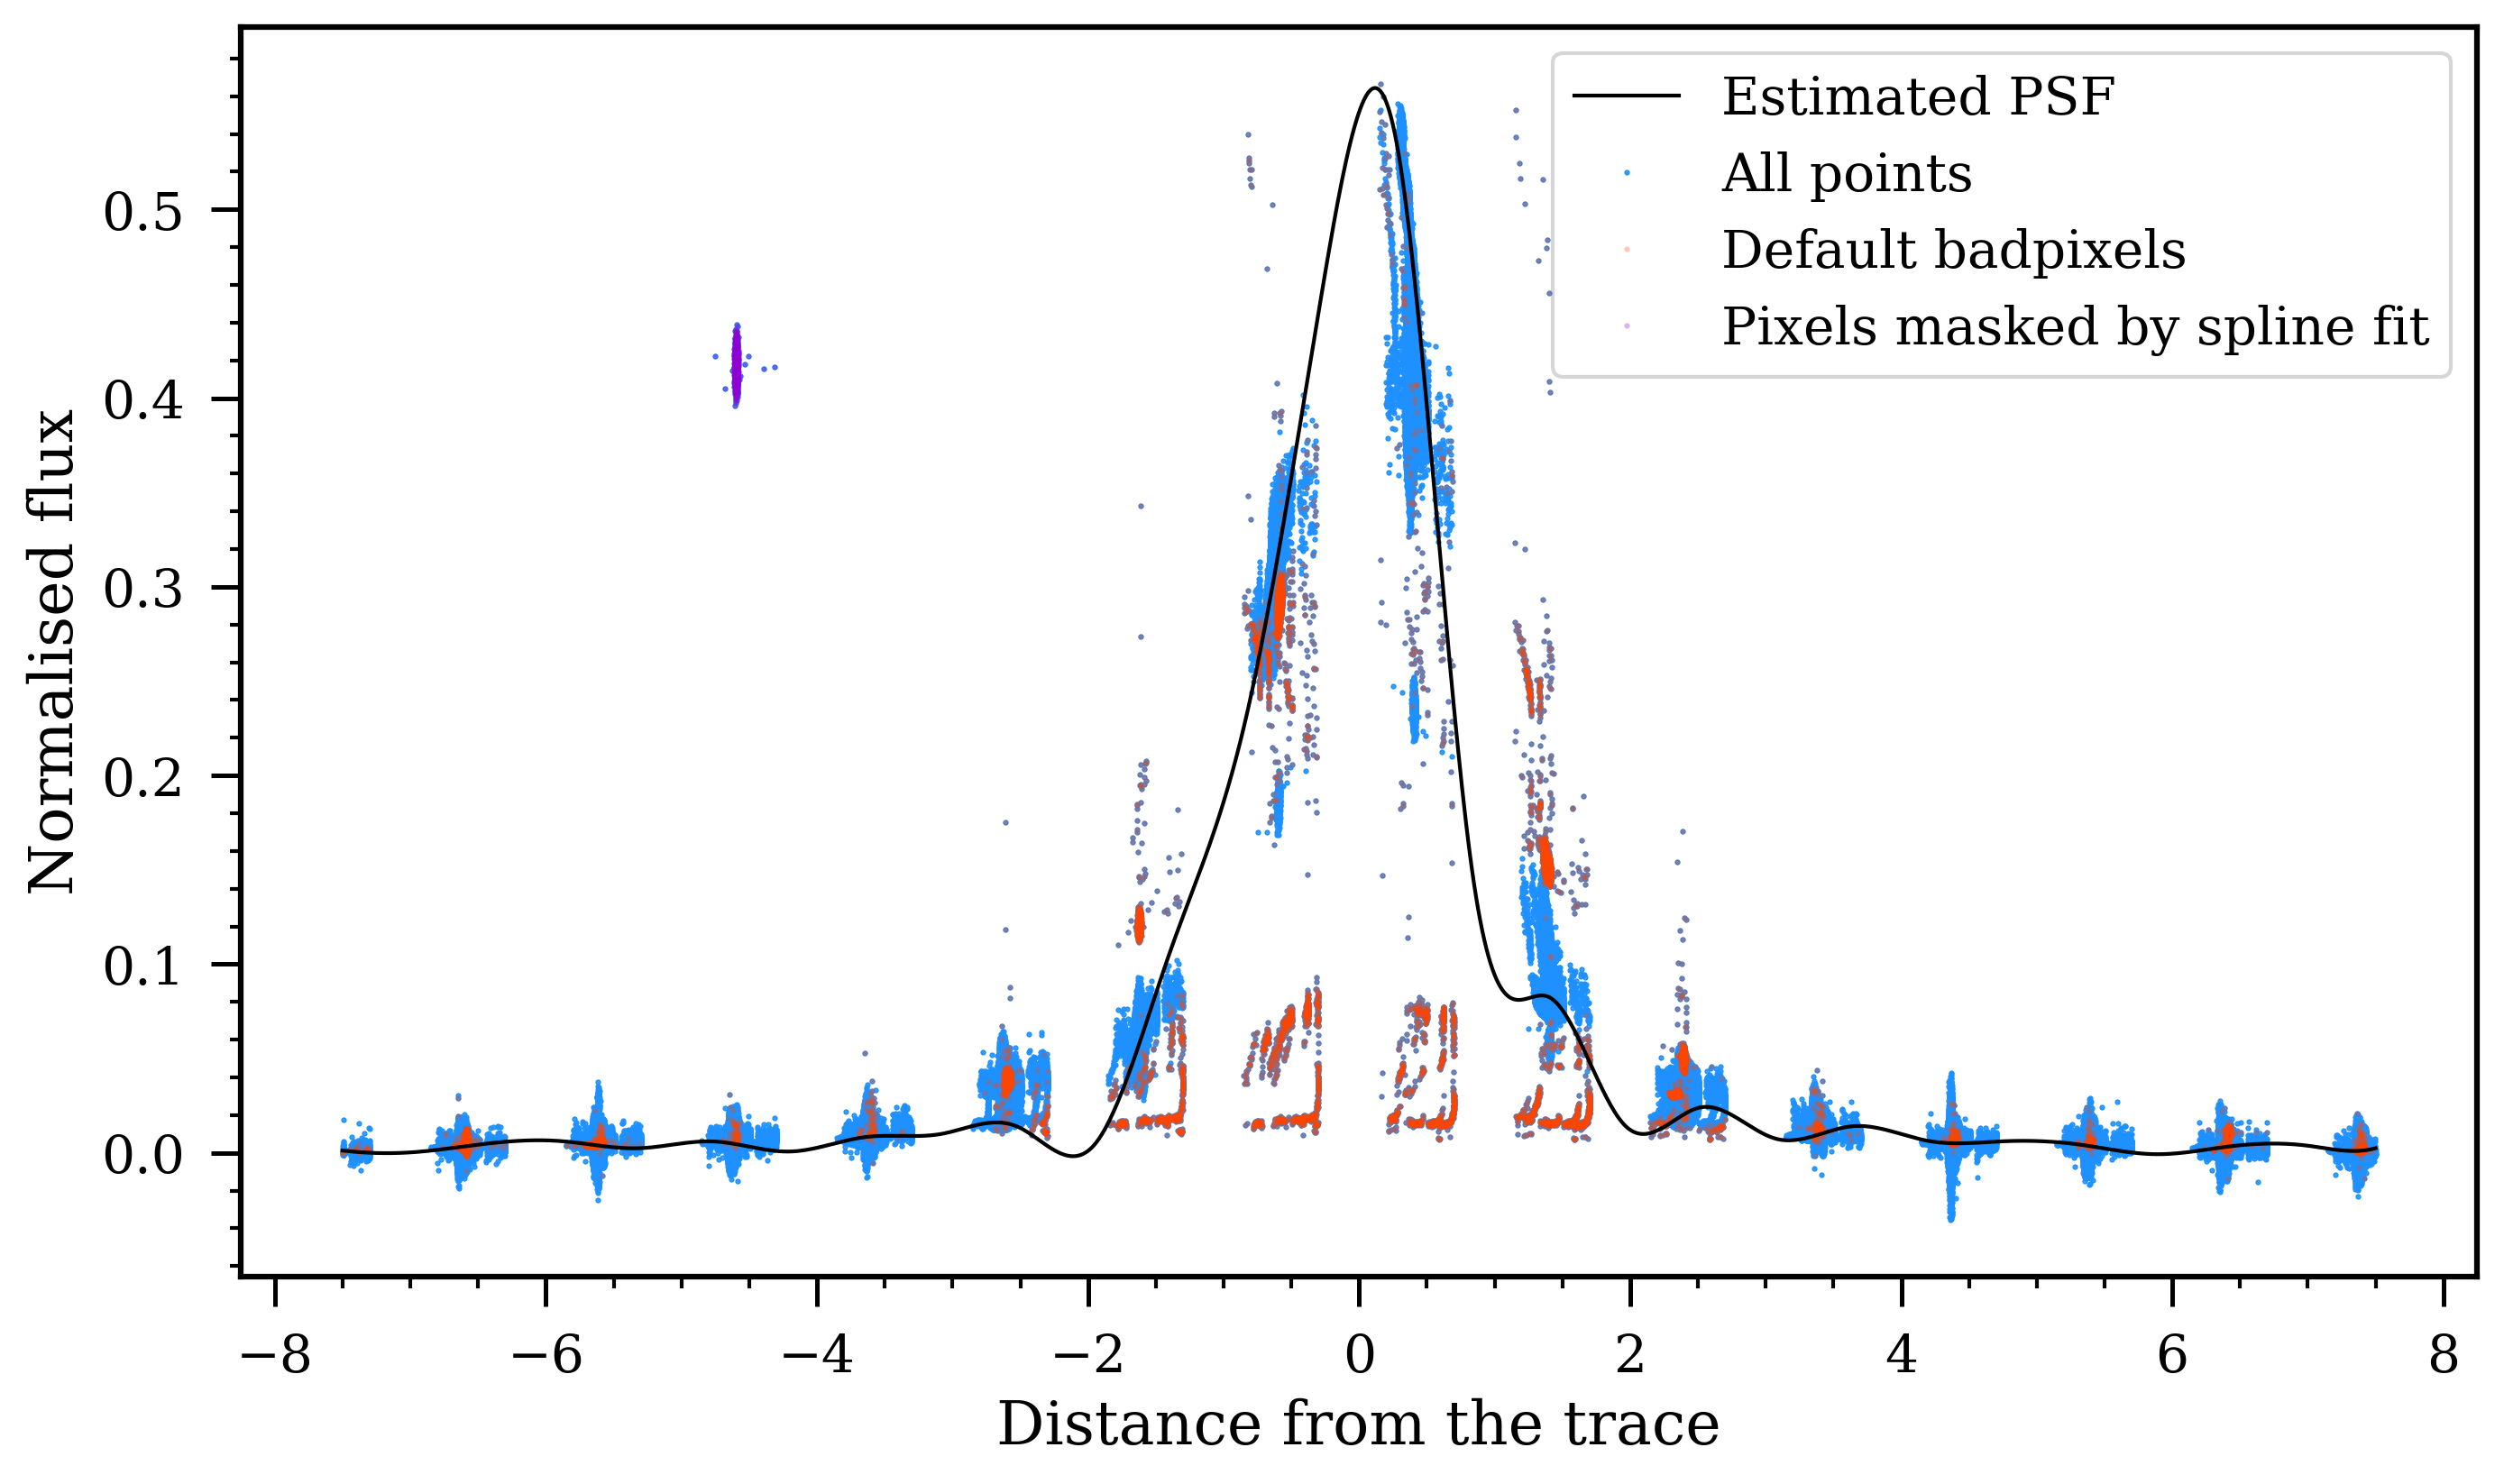

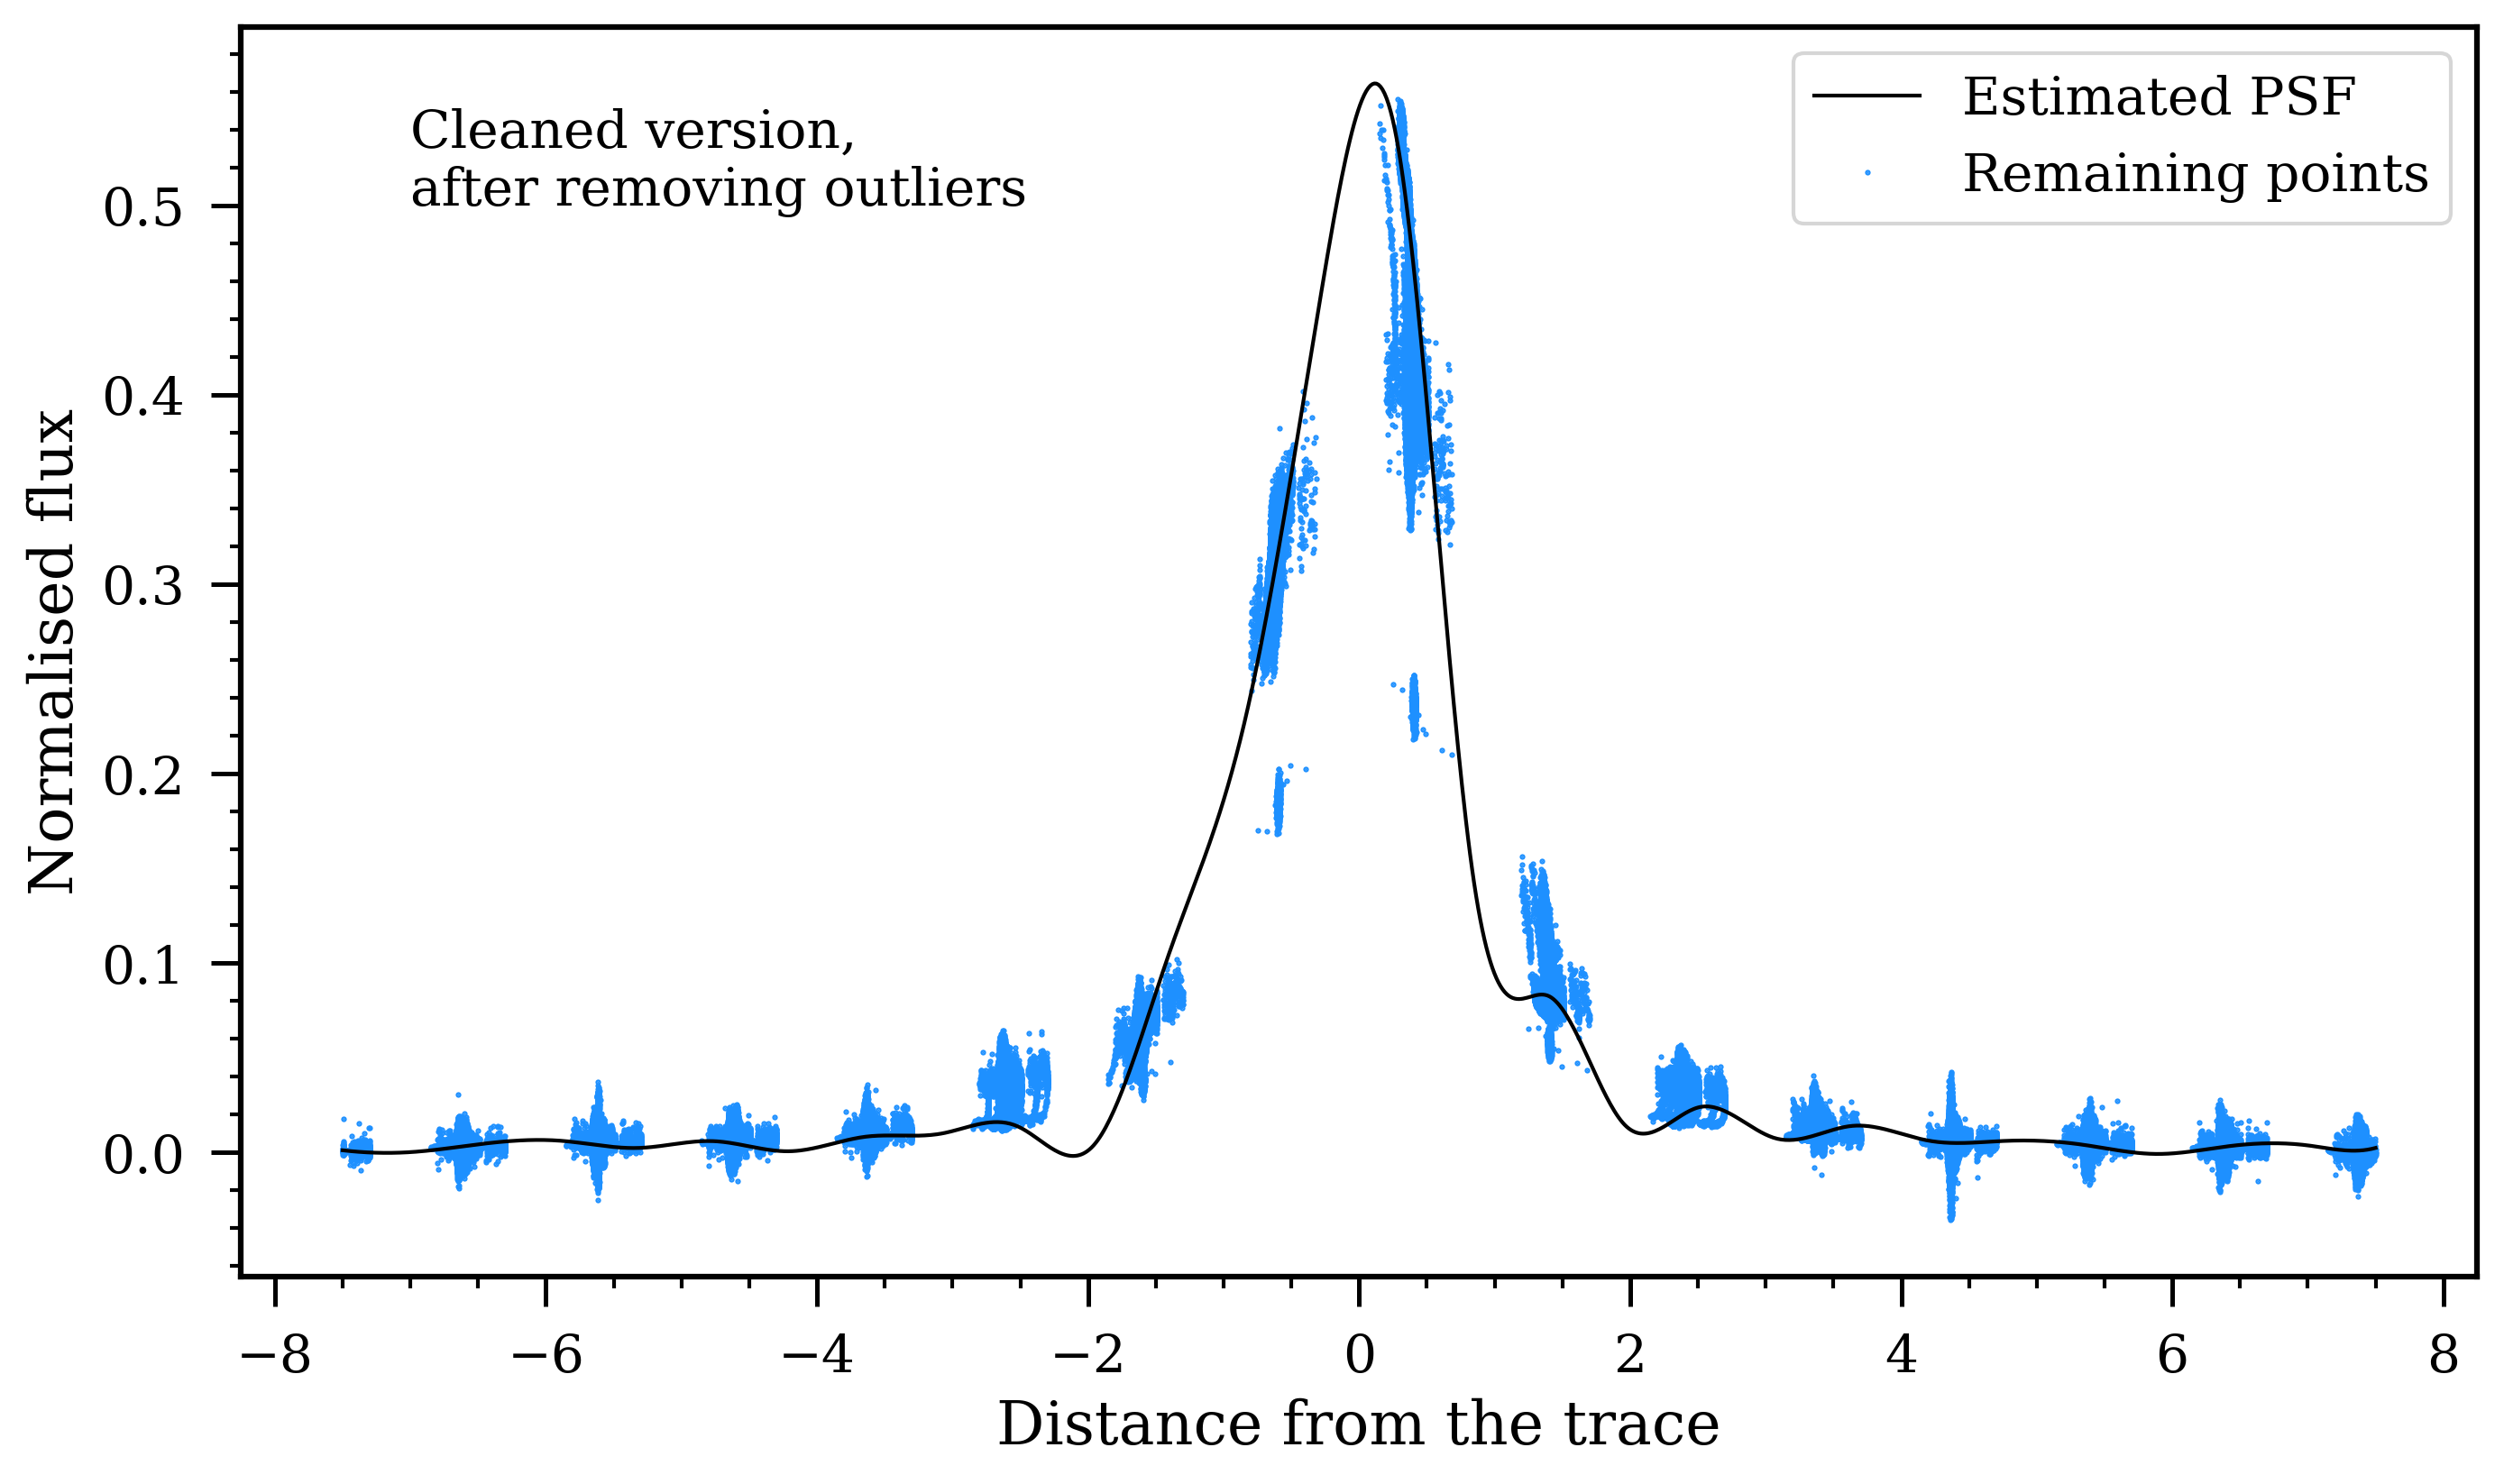

In [16]:
# ---------------------------------------------------
#  Fitting a univariate spline to the spectral trace
# ---------------------------------------------------

data1d = SingleOrderPSF(frame=corrected_data[:,:,xpos[0]:xpos[-1]+1],\
                        variance=corrected_errs[:,:,xpos[0]:xpos[-1]+1]**2,\
                        ord_pos=ypos2d, ap_rad=aprad_psf, mask=mask_bcr[:,:,xpos[0]:xpos[-1]+1],\
                        spec=ap_spec1d_clipped)
psf_frame1d, psf_spline1d, msk_updated_1d = data1d.univariate_psf_frame(niters=3, oversample=oversample_psf, clip=clip_sigma)

## Plotting the 1D PSF and the spline fit
ts1 = np.linspace(np.min(data1d.norm_array[:,0]), np.max(data1d.norm_array[:,0]), 1000)
msk1 = np.asarray(data1d.norm_array[:,4], dtype=bool)
msk2 = ( msk1 * msk_updated_1d  ) + ( ~msk1 * ~msk_updated_1d  )
msk3 = msk1 * msk_updated_1d

# ---------------------------------------------------
#  Plotting the fitted PSF
# ---------------------------------------------------

plt.figure(figsize=(16/1.5, 9/1.5))
plt.errorbar(data1d.norm_array[:,0], data1d.norm_array[:,1], fmt='.', color='dodgerblue', markersize=1., zorder=5, label='All points')
plt.errorbar(data1d.norm_array[~msk1,0], data1d.norm_array[~msk1,1], fmt='.', color='orangered', alpha=0.3, markersize=1., zorder=5, label='Default badpixels')
plt.errorbar(data1d.norm_array[~msk2,0], data1d.norm_array[~msk2,1], fmt='.', color='darkviolet', alpha=0.3, markersize=1., zorder=5, label='Pixels masked by spline fit')
plt.plot(ts1, psf_spline1d(ts1), c='k', lw=1., zorder=10, label='Estimated PSF')
plt.xlabel('Distance from the trace')
plt.ylabel('Normalised flux')
plt.legend()

plt.figure(figsize=(16/1.5, 9/1.5))
plt.errorbar(data1d.norm_array[msk3,0], data1d.norm_array[msk3,1], fmt='.', color='dodgerblue', markersize=1., zorder=5, label='Remaining points')
plt.plot(ts1, psf_spline1d(ts1), c='k', lw=1., zorder=10, label='Estimated PSF')
plt.text(-7, 0.5, 'Cleaned version,\nafter removing outliers')
plt.xlabel('Distance from the trace')
plt.ylabel('Normalised flux')
plt.legend()

This is fantastic! The fitted spline is smooth, and we also removed many outliers! Okay so now we can use this PSF to estimate the stellar spectral timeseries. However, before doing this, we need to update our bad-pixel map.

100%|██████████| 3198/3198 [00:16<00:00, 196.24it/s]


Text(0.5, 1.0, 'Timeseries of spectra')

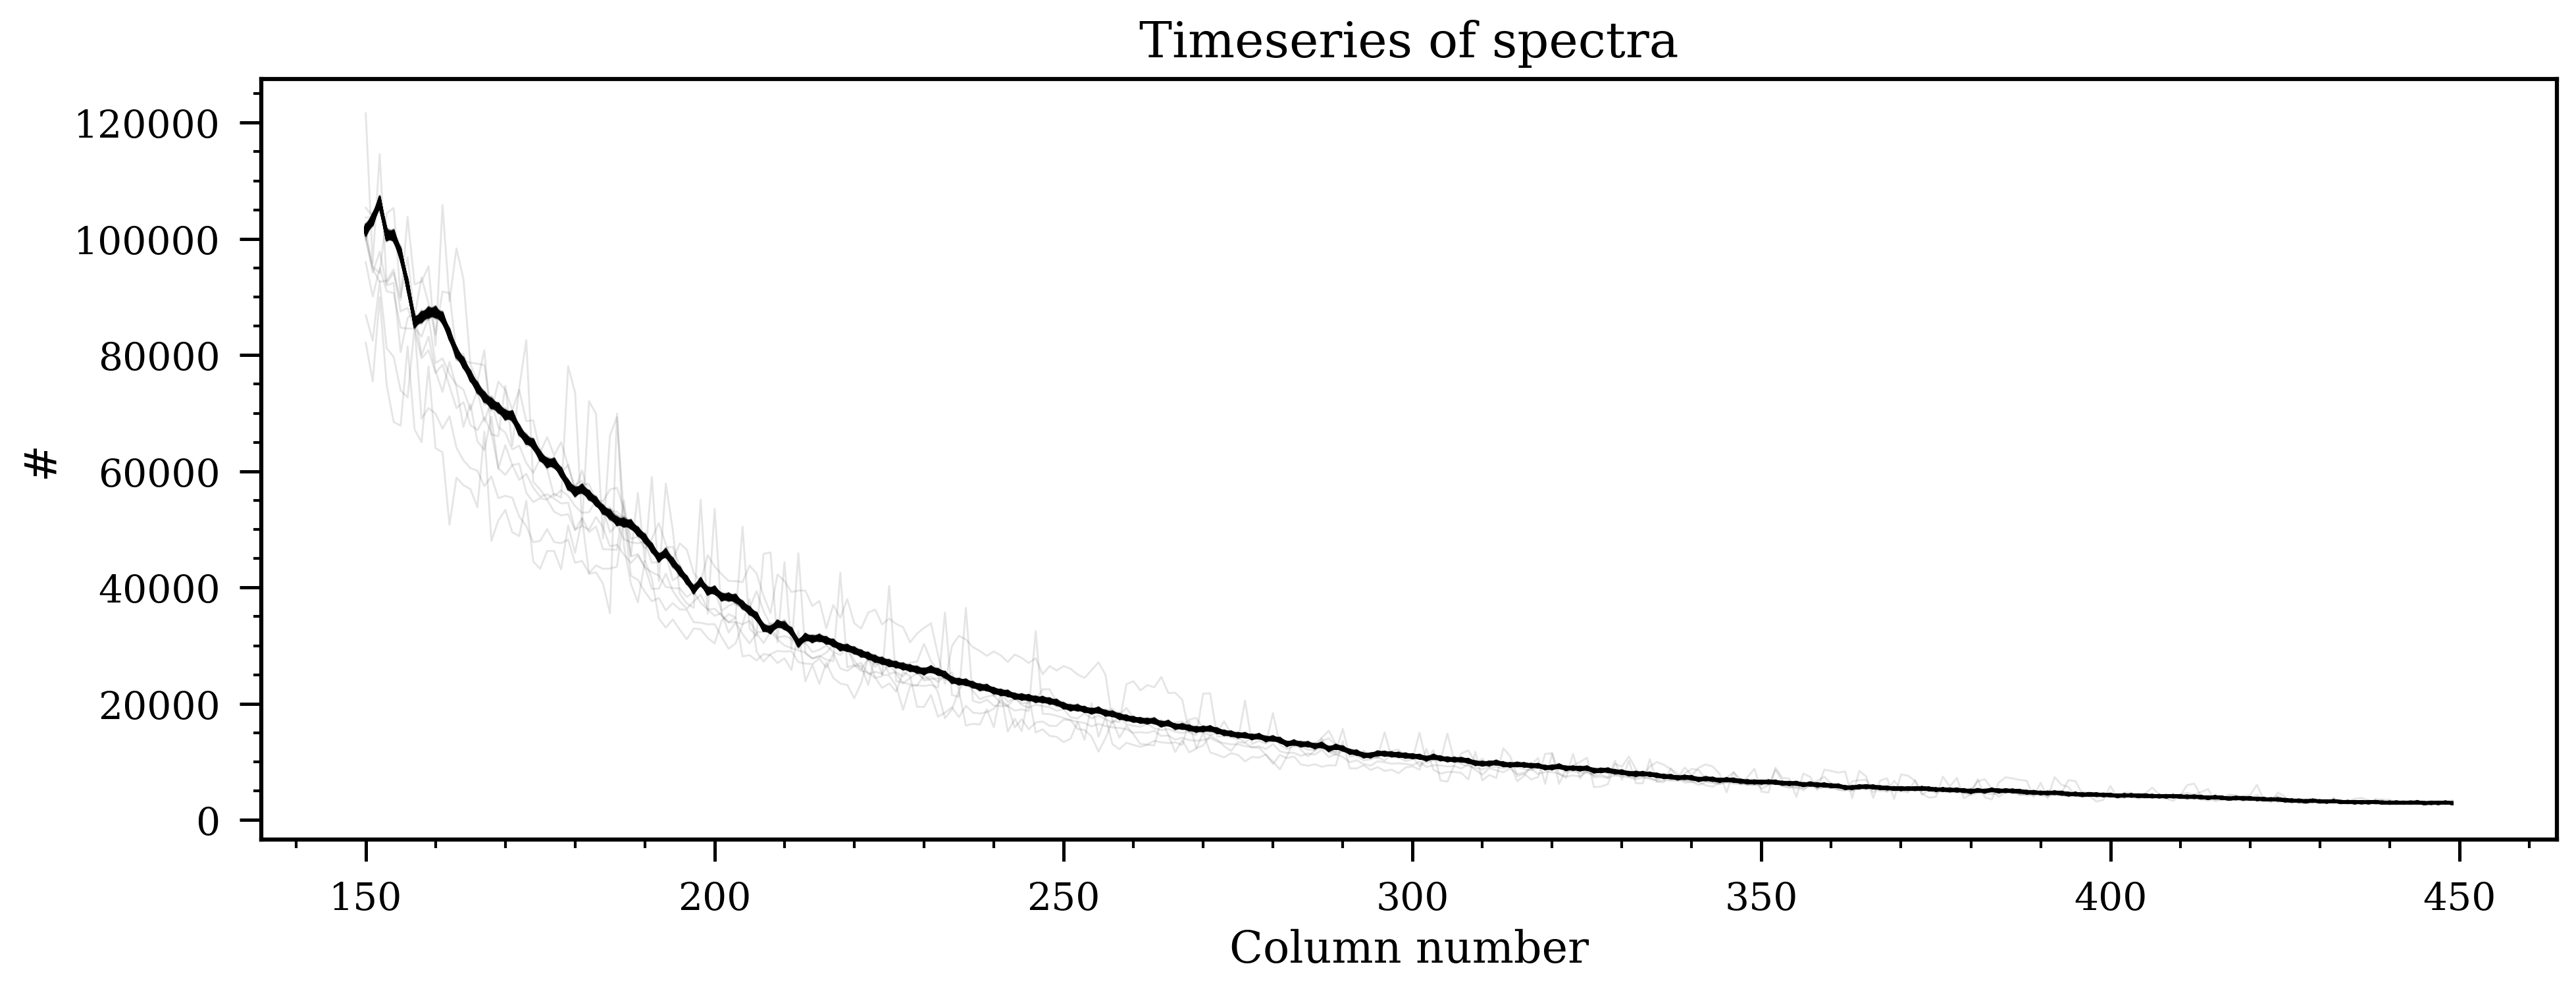

In [17]:
# ----------------------------------------------------------
#     Updating the bad-pixel map
# ----------------------------------------------------------

msk_2d = data1d.table2frame(msk_updated_1d)
mask_badpix_updated = np.copy(mask_bcr)
mask_badpix_updated[:,:,xpos[0]:xpos[-1]+1] = mask_bcr[:,:,xpos[0]:xpos[-1]+1] * msk_2d

# ----------------------------------------------------------
#     And the optimal extraction
# ----------------------------------------------------------

spec1d, var1d = np.zeros((psf_frame1d.shape[0], psf_frame1d.shape[2])), np.zeros((psf_frame1d.shape[0], psf_frame1d.shape[2]))
syth1d = np.zeros(psf_frame1d.shape)
for inte in tqdm(range(spec1d.shape[0])):
    spec1d[inte,:], var1d[inte,:], syth1d[inte,:,:] = optimal_extract(psf_frame=psf_frame1d[inte,:,:],\
                                                                      data=corrected_data[inte,:,xpos[0]:xpos[-1]+1],\
                                                                      variance=corrected_errs[inte,:,xpos[0]:xpos[-1]+1]**2,\
                                                                      mask=mask_badpix_updated[inte,:,xpos[0]:xpos[-1]+1],\
                                                                      ord_pos=ypos2d[inte,:], ap_rad=aprad_extraction)
    
# ----------------------------------------------------------
#    Plotting the extracted spectrum for all integrations
# ----------------------------------------------------------

plt.figure(figsize=(15,5))
for i in range(spec1d.shape[0]):
    plt.plot(xpos, spec1d[i,:], 'k', alpha=0.1, lw=0.7)
plt.xlabel('Column number')
plt.ylabel('#')
plt.title('Timeseries of spectra')

There could be places where the spectrum has NaN values -- this could happen, for example, when all columns inside the aperture are bad. We can replace those NaN with the value of the median spectra for that column.

Text(0.5, 1.0, 'Timeseries of spectra')

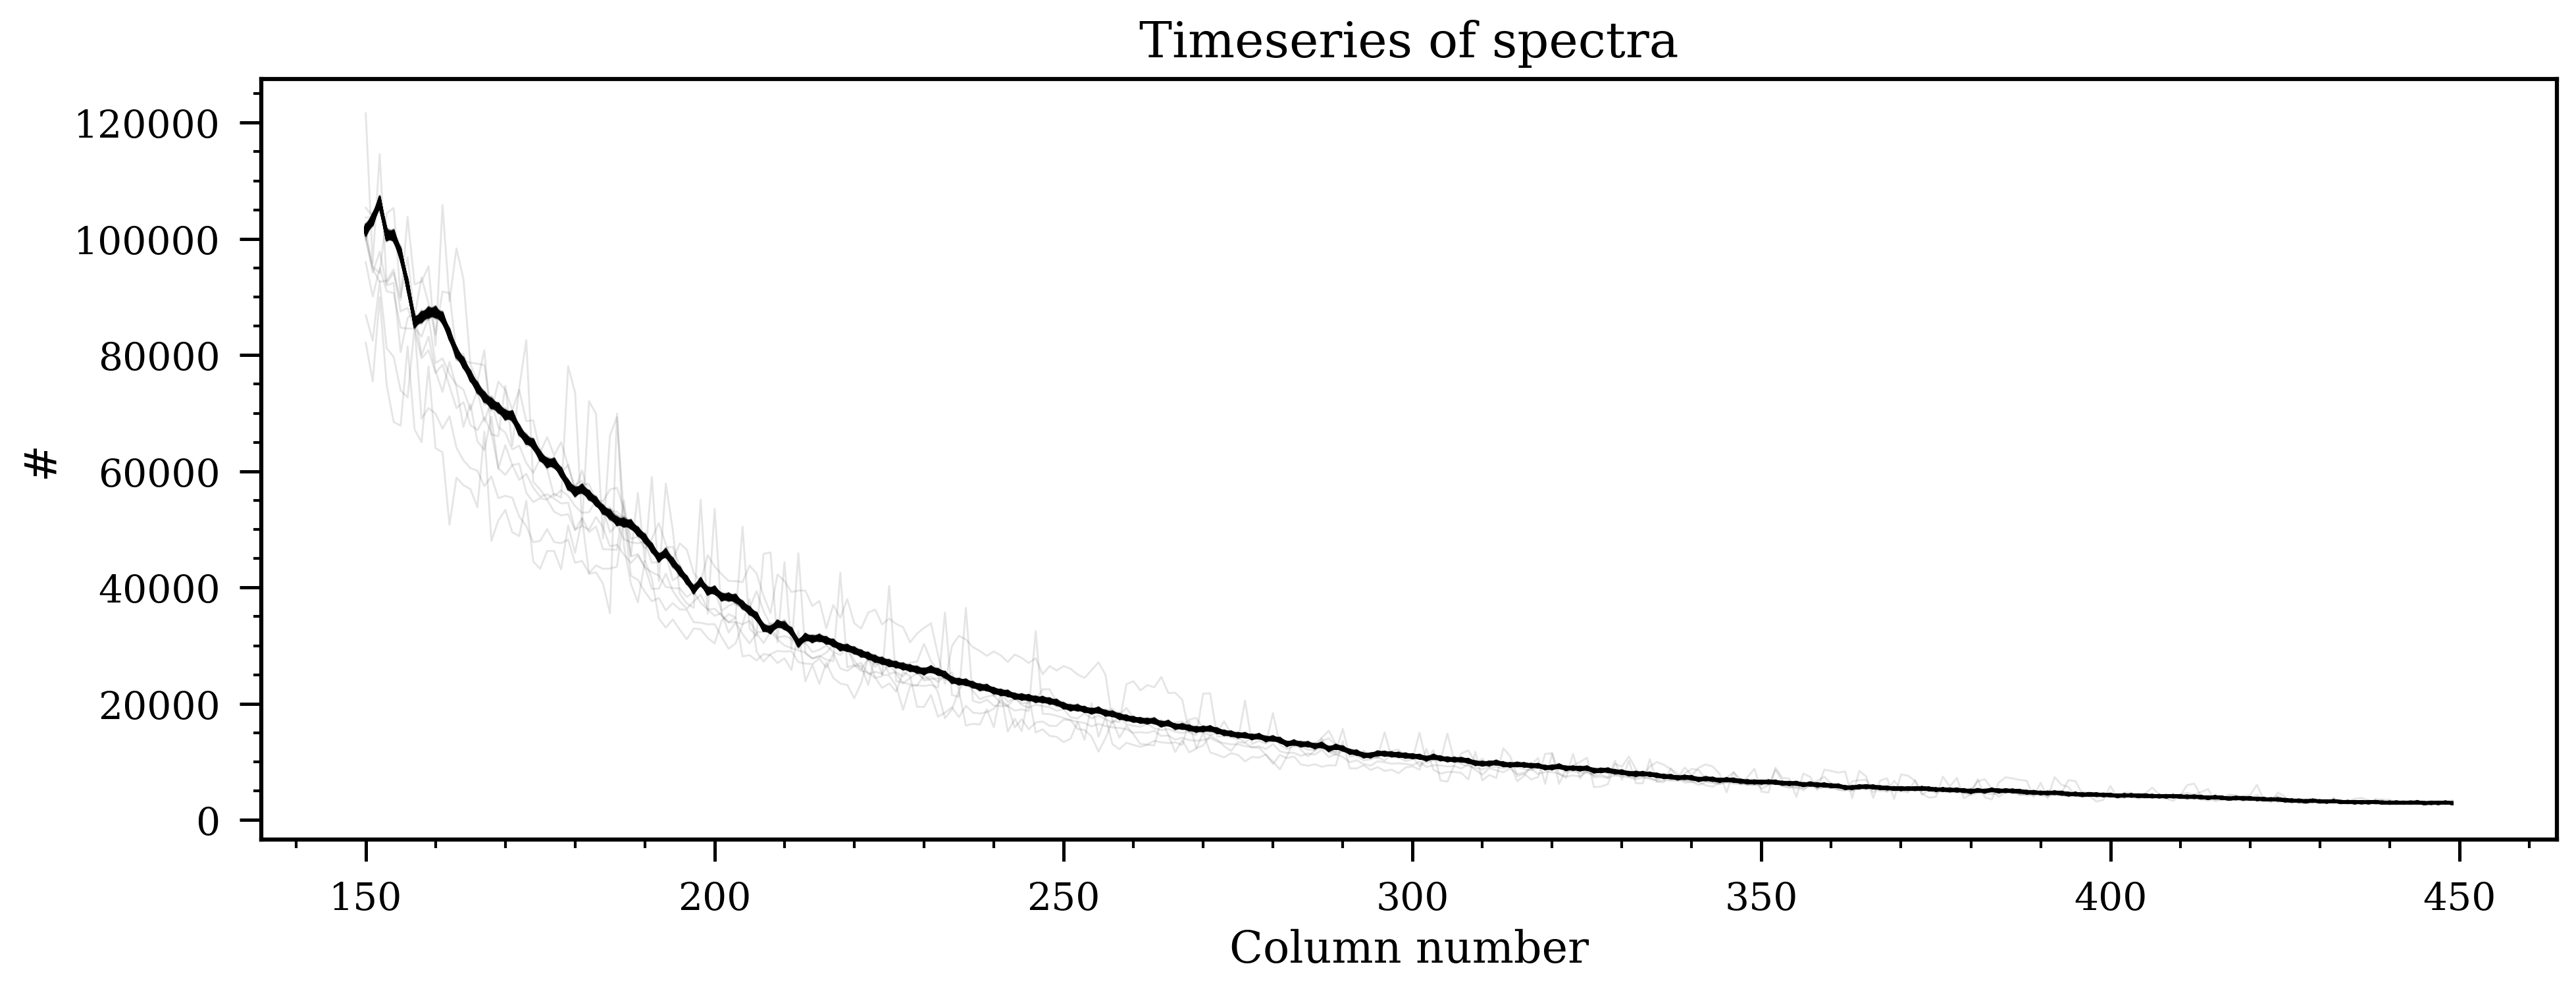

In [18]:
# ------ Calculating the median spectrum across all integrations ------
med_spec1d = np.nanmedian(spec1d, axis=0)

# ------ Creating a mask for NaN in spectra ------
mask_outliers = np.ones(spec1d.shape, dtype=bool)
for i in range(spec1d.shape[0]):
    mask_outliers[i, :] = np.where(np.isnan(spec1d[i, :]), False, True)

# ------ Replacing the outliers in the original spectra with median spectrum ------
spec1d_clipped = np.copy(spec1d)
for i in range(spec1d_clipped.shape[0]):
    spec1d_clipped[i, :] = np.where(mask_outliers[i, :], spec1d_clipped[i, :], med_spec1d)

# ----------------------------------------------------------
#    Plotting the extracted spectrum for all integrations
# ----------------------------------------------------------

plt.figure(figsize=(15,5))
for i in range(spec1d.shape[0]):
    plt.plot(xpos, spec1d_clipped[i,:], 'k', alpha=0.1, lw=0.7)
plt.xlabel('Column number')
plt.ylabel('#')
plt.title('Timeseries of spectra')

When we estimated the PSF above, we made an assumption that the PSF is constant with wavelength, which is of course not true: PSF shape typically changes with wavelength. We now want to fit a more robust PSF to the data using 2D spline. This spline would be function of distance from trace and wavelength. Let's now fit a 2D spline to the data!

In [19]:
data2 = SingleOrderPSF(frame=corrected_data[:,:,xpos[0]:xpos[-1]+1],\
                       variance=corrected_errs[:,:,xpos[0]:xpos[-1]+1]**2,\
                       ord_pos=ypos2d, ap_rad=aprad_psf, mask=mask_badpix_updated[:,:,xpos[0]:xpos[-1]+1],\
                       spec=spec1d_clipped)
psf_frame2d, psf_spline2d, msk_after2d = data2.bivariate_psf_frame(niters=3, oversample=oversample_psf, knot_col=10, clip=clip_sigma)

Iter 1 / 3: 0.54533 per cent masked.
Iter 2 / 3: 0.54534 per cent masked.
Iter 3 / 3: 0.54534 per cent masked.


Let's see how we did! I will now plot the data points in a given column for _all_ integrations. Together with these, I will plot the fitted 2D PSF.

Text(0, 0.5, 'Normalised flux')

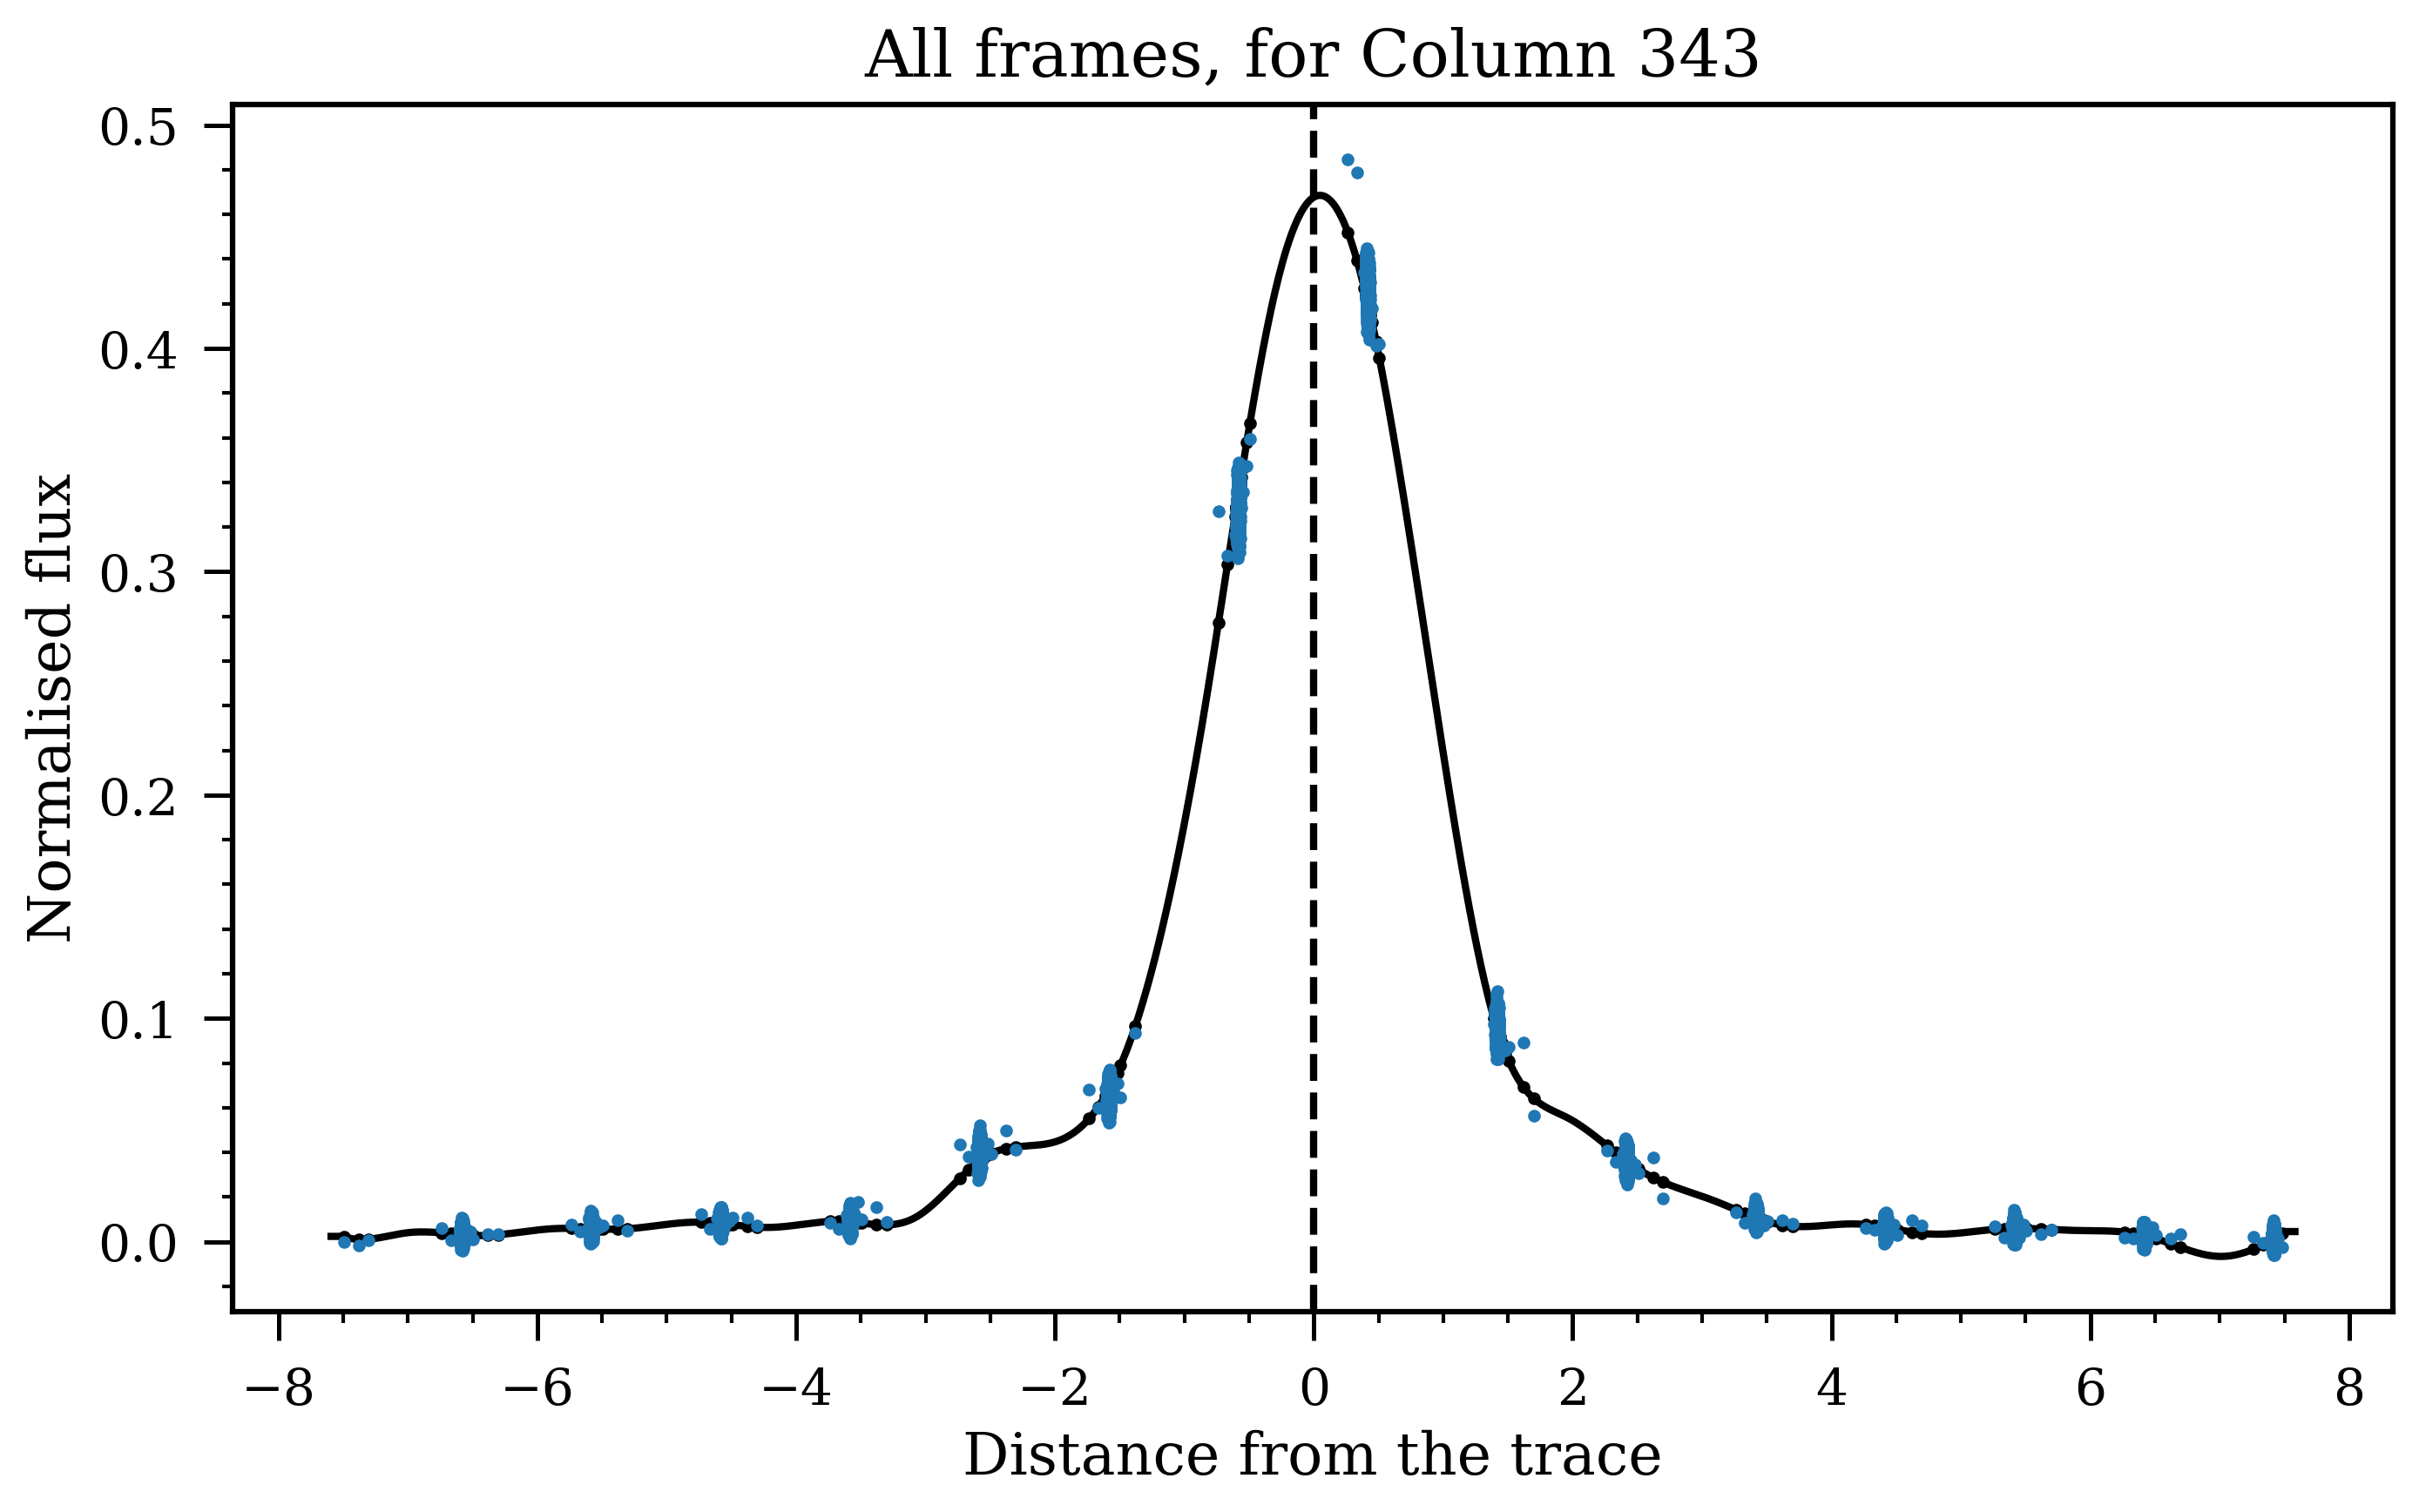

In [20]:
ncol = np.random.choice(xpos)
des_pts, cont_pts = utils.spln2d_func(ncol1=ncol-xpos[0], datacube=data2)
fits_2d = psf_spline2d(cont_pts[0], cont_pts[1], grid=False)

plt.figure(figsize=(16/1.5,9/1.5))
plt.errorbar(des_pts[0], des_pts[2], fmt='.')
plt.plot(cont_pts[0], fits_2d, 'k-')
plt.plot(des_pts[0], psf_spline2d(des_pts[0], des_pts[1], grid=False), 'k.')
plt.axvline(0., color='k', ls='--')
plt.title('All frames, for Column ' + str(ncol))
plt.xlabel('Distance from the trace')
plt.ylabel('Normalised flux')

The reason for us to use a 2D spline instead of a simple univariate spline was that the stellar PSF is expected to change with wavelength. Let's compute how the maximum amplitude and FWHM of the fitted PSF varies with wavelength.

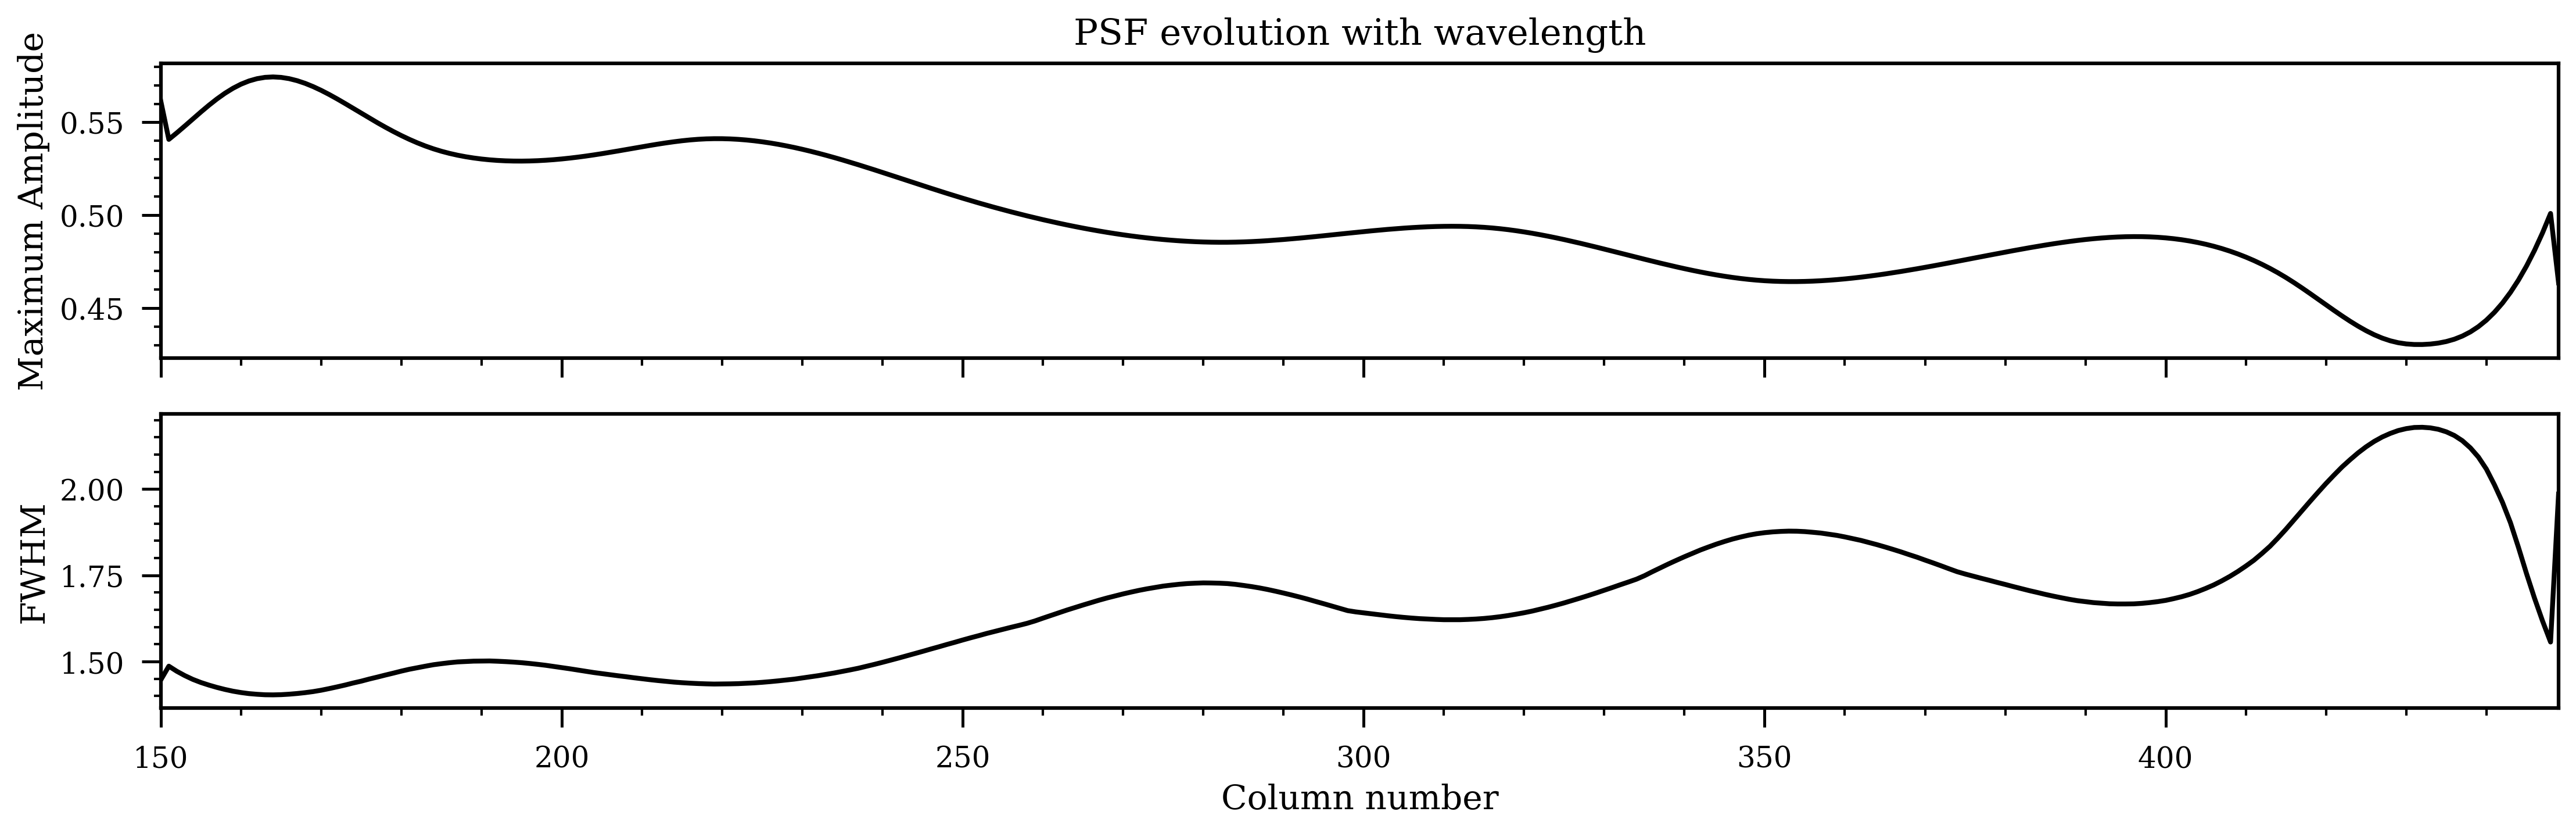

In [21]:
# Defining pixel coordinates
pix_cor_res = 50000
pix_corr = np.linspace(-7., 7., pix_cor_res)

cols = xpos - xpos[0]
max_amp = np.zeros(len(cols))
fwhm = np.zeros(len(cols))

for i in range(len(cols)):
    fit2 = psf_spline2d(x=pix_corr, y=np.ones(pix_cor_res)*cols[i], grid=False)
    # Maximum amplitude
    max_amp[i] = np.max(fit2)
    # Maximum amplitude location
    idx_max_amp = np.where(fit2 == np.max(fit2))[0][0]
    # fwhm
    hm = (np.max(fit2) + np.min(fit2))/2
    idx_hm = np.where(np.abs(fit2 - hm)<0.005)[0]
    idx_hm_up, idx_hm_lo = 0, 0
    diff_up1, diff_lo1 = 10., 10.
    for j in range(len(idx_hm)):
        if idx_hm[j] > idx_max_amp:
            diff_u1 = np.abs(fit2[idx_hm[j]] - hm)
            if diff_u1 < diff_up1:
                diff_up1 = diff_u1
                idx_hm_up = idx_hm[j]
        else:
            diff_l1 = np.abs(fit2[idx_hm[j]] - hm)
            if diff_l1 < diff_lo1:
                diff_lo1 = diff_l1
                idx_hm_lo = idx_hm[j]
    fwhm[i] = np.abs(pix_corr[idx_hm_up] - pix_corr[idx_hm_lo])

fig, axs = plt.subplots(2, 1, figsize=(15, 5), sharex=True, facecolor='white')

axs[0].plot(xpos, max_amp, 'k-')
axs[0].set_ylabel('Maximum Amplitude', fontsize=14)

axs[1].plot(xpos, fwhm, 'k-')
axs[1].set_ylabel('FWHM', fontsize=14)
axs[1].set_xlabel('Column number', fontsize=14)

axs[1].set_xlim([xpos[0], xpos[-1]])

axs[0].set_title('PSF evolution with wavelength', fontsize=15)

plt.setp(axs[0].get_yticklabels(), fontsize=12)
plt.setp(axs[1].get_xticklabels(), fontsize=12)
plt.setp(axs[1].get_yticklabels(), fontsize=12)

plt.tight_layout()

Okay, interesting changes! The maximum amplitude seems to be decreasing with wavelength and FWHH seems to be first increasing and then decreasing with wavelength. It also looks like a smooth variations. We can now update the bad-pixel map based on our PSF fitting.

Text(0.5, 1.0, 'Updated bad-pixel map')

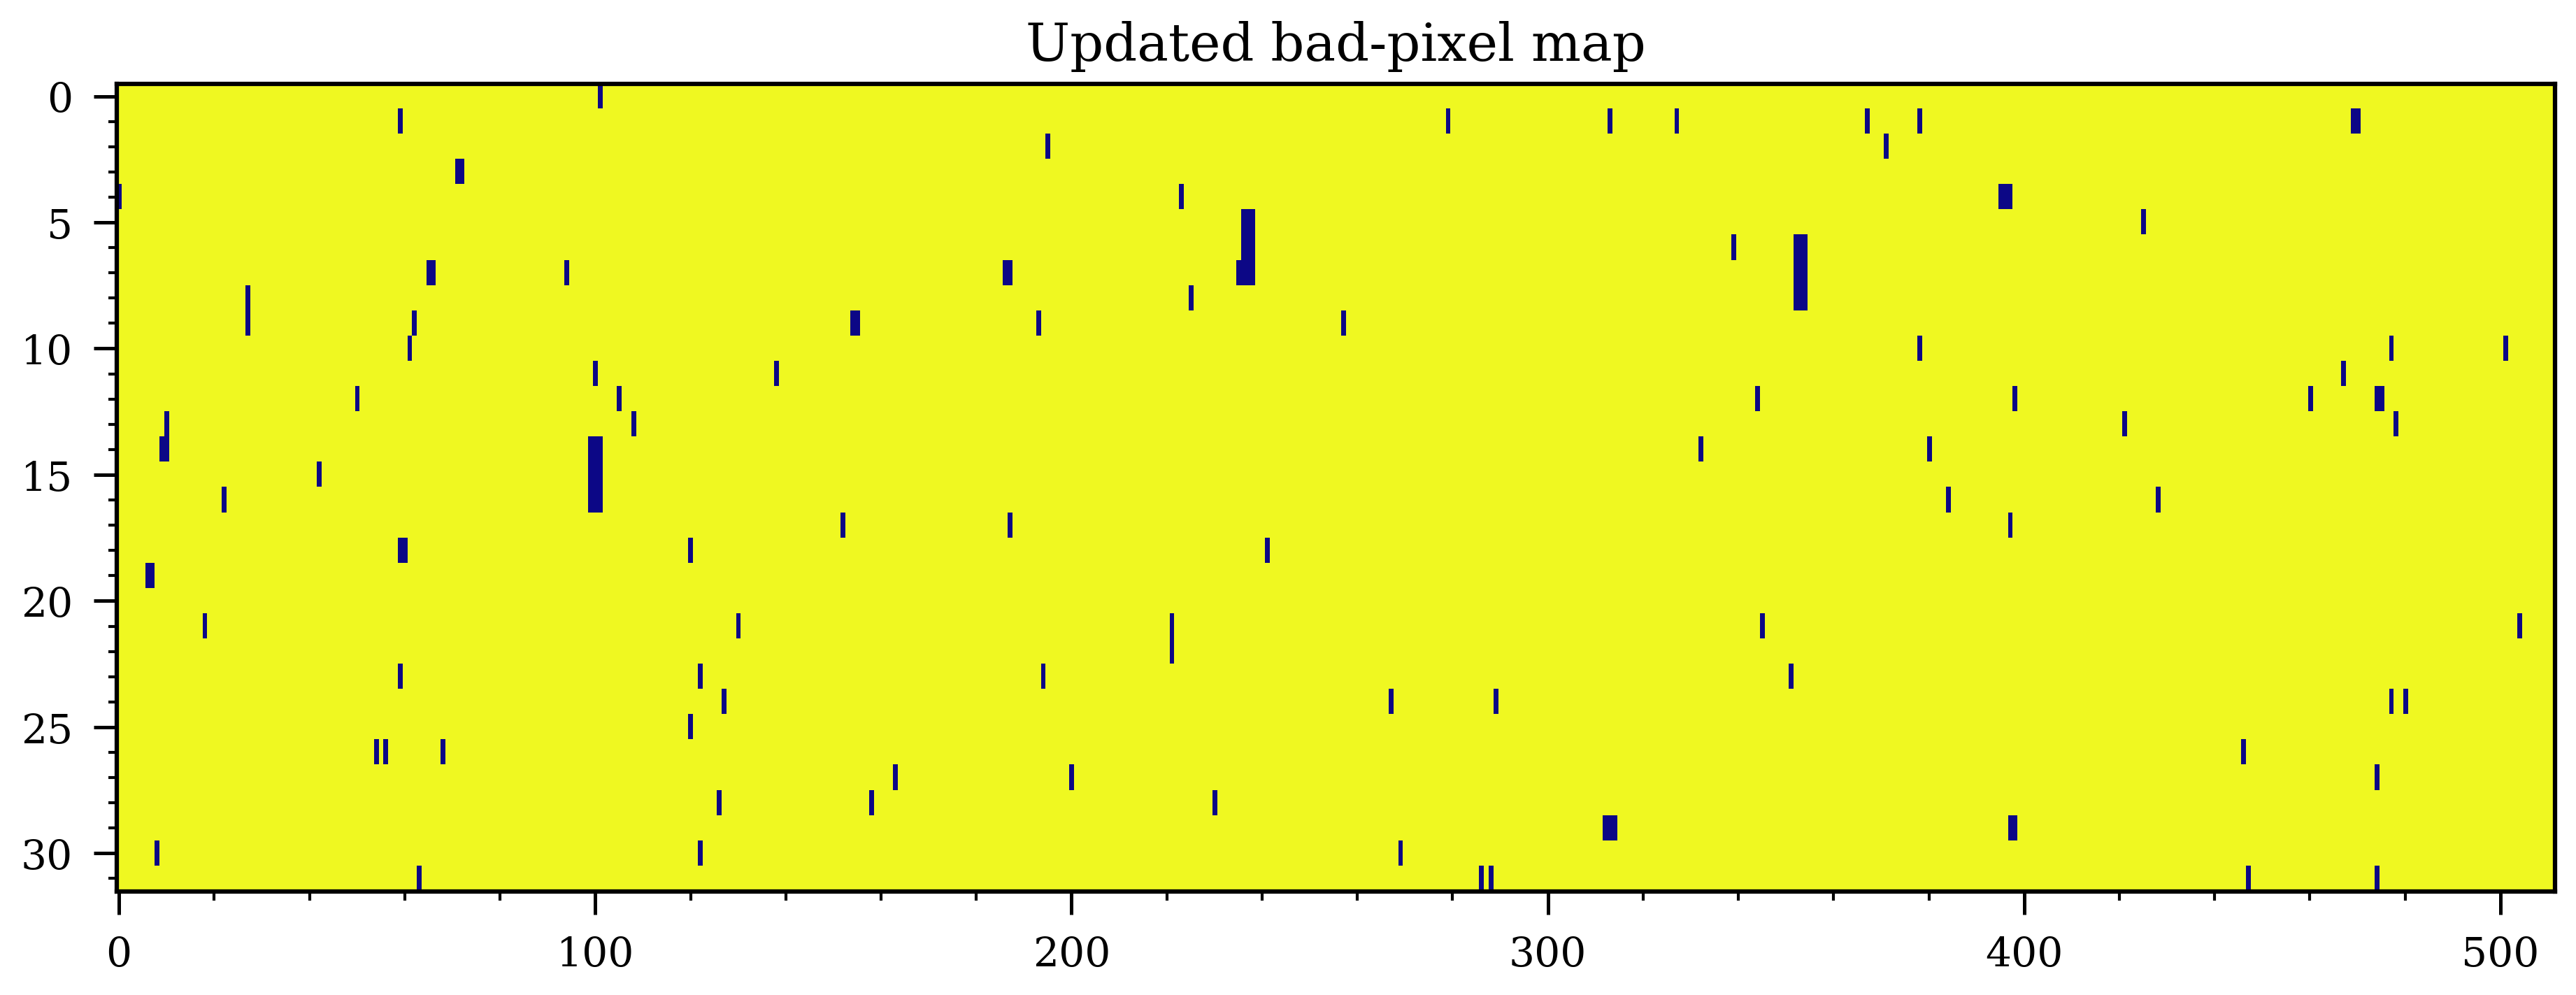

In [22]:
msk_2d2d = data2.table2frame(msk_after2d)
mask_badpix_updated2d = np.copy(mask_badpix_updated)
mask_badpix_updated2d[:,:,xpos[0]:xpos[-1]+1] = mask_badpix_updated[:,:,xpos[0]:xpos[-1]+1] * msk_2d2d

plt.figure(figsize=(15,5))
plt.imshow(mask_badpix_updated2d[0,:,:], interpolation='none', cmap='plasma', aspect='auto')
plt.title('Updated bad-pixel map')

Now, we want to select our aperture for spectral extraction. Different aperture widths can produce different amount of noise in the final light curve. So, we will calculate the noise as a function of aperture size, and will finally select the aperture which produces a minimum noise.

100%|██████████| 3198/3198 [00:15<00:00, 203.24it/s]


Median absolute deviation of white-light light curve: 741.5256 ppm


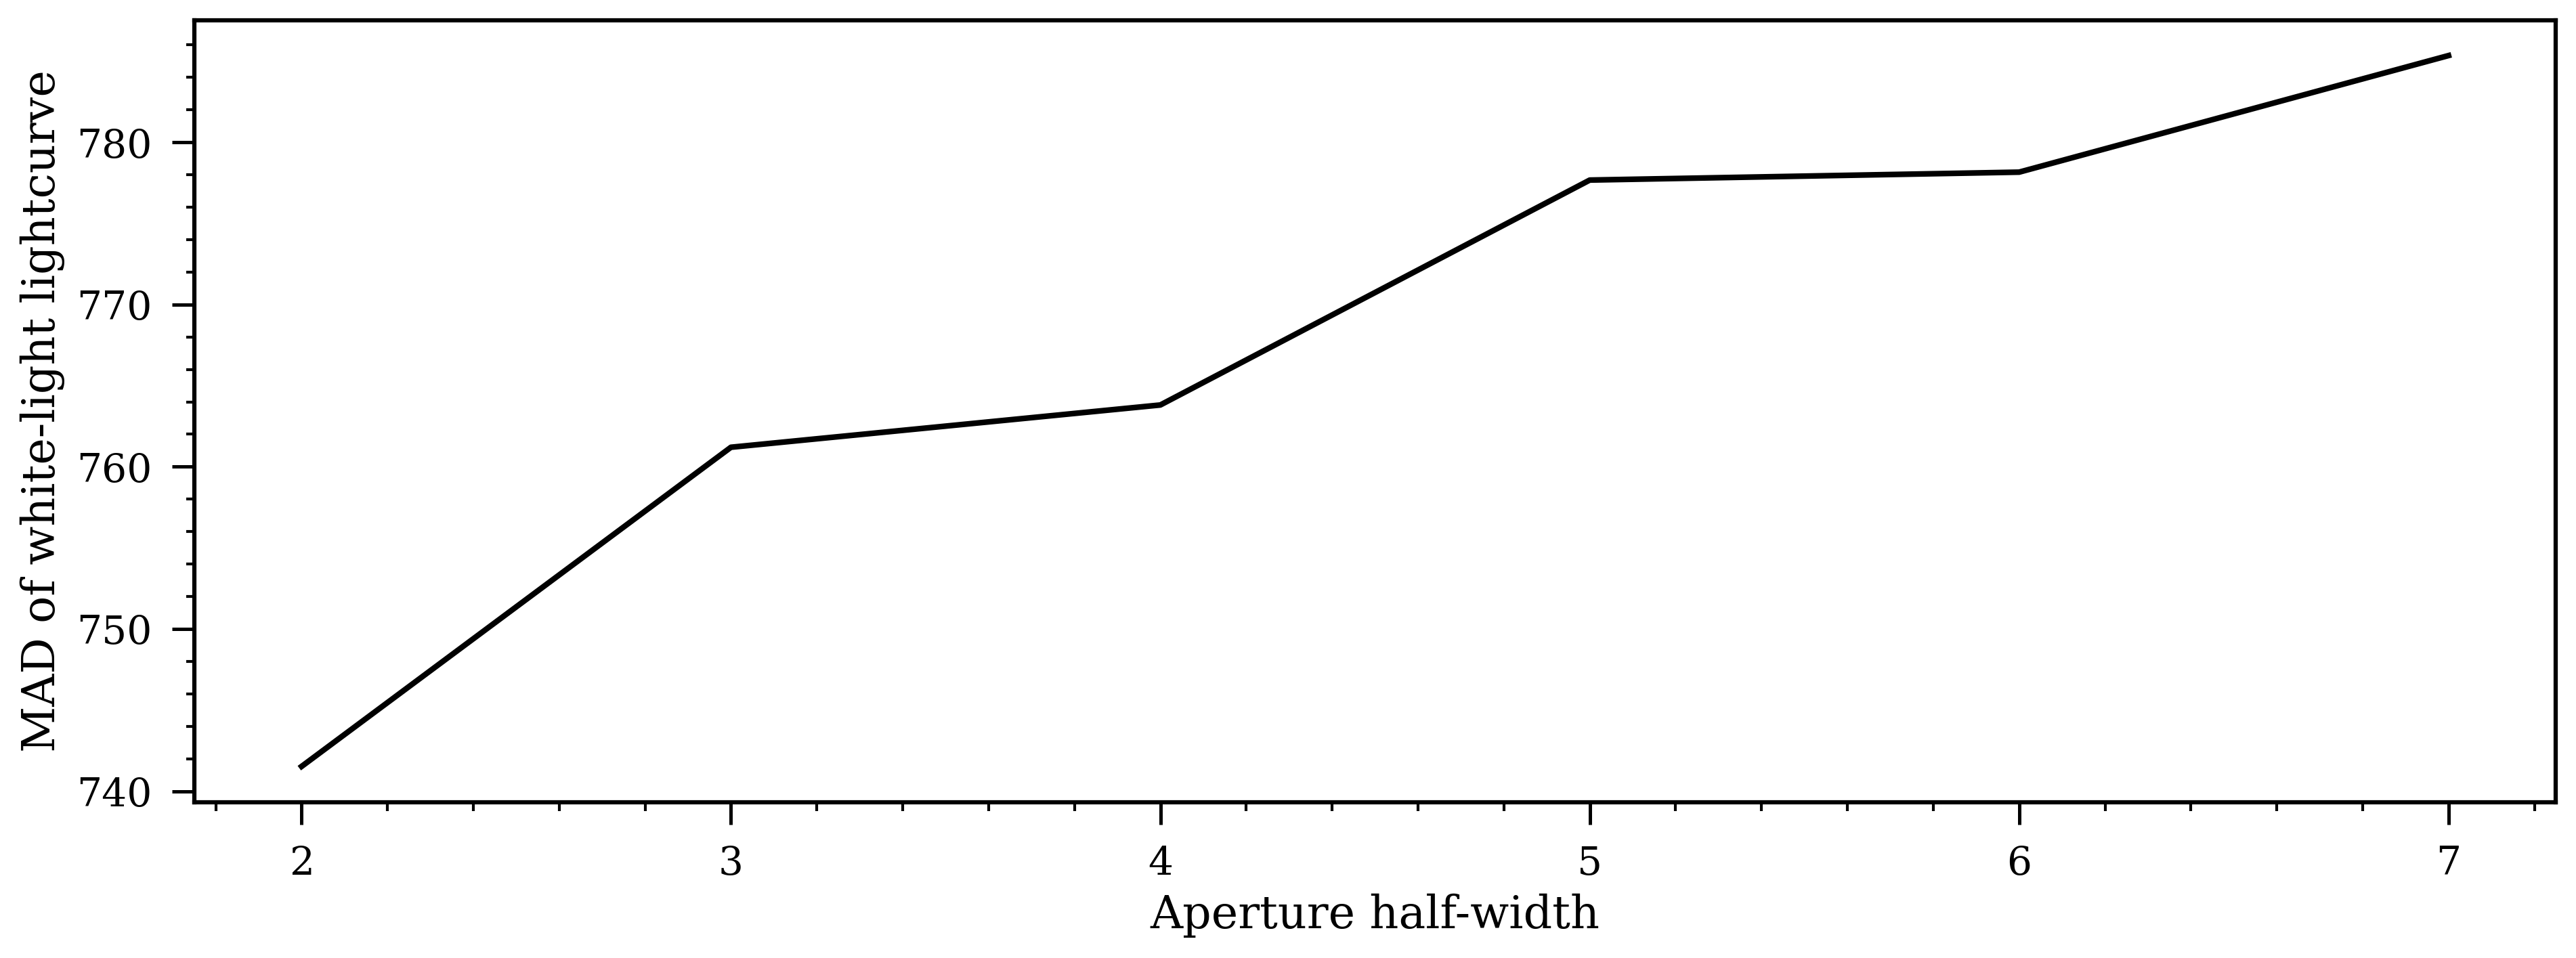

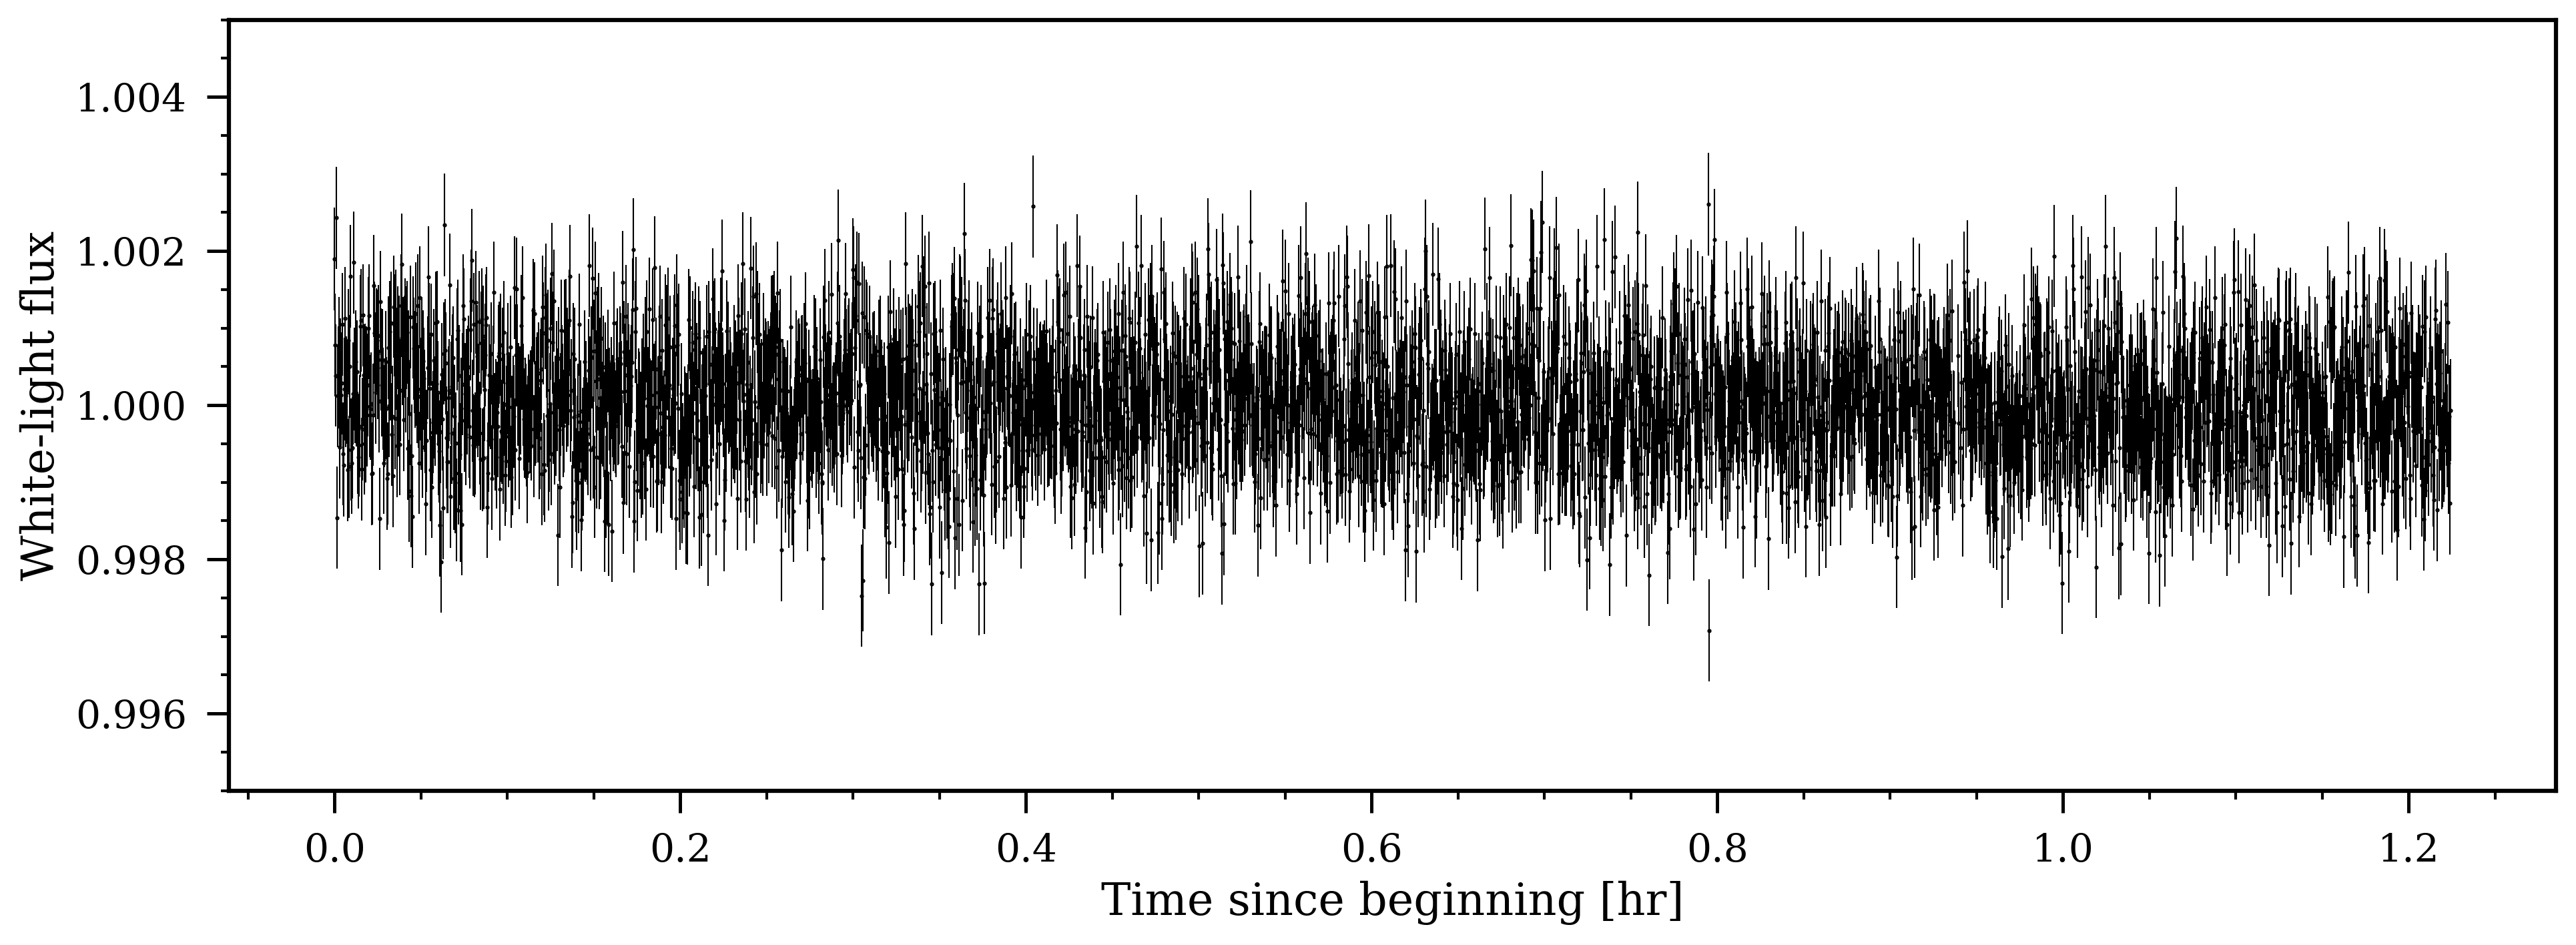

In [23]:
# ---------------------------------------------------
# Trying optimal extraction with different aperture sizes
# ---------------------------------------------------

apertures = np.arange(2,7+1,1)
scatter = np.zeros(len(apertures))

for aps in range(len(apertures)):
    spec1d, var1d = np.zeros((psf_frame2d.shape[0], psf_frame2d.shape[2])), np.zeros((psf_frame2d.shape[0], psf_frame2d.shape[2]))
    syth1d = np.zeros(psf_frame2d.shape)
    for inte in tqdm(range(spec1d.shape[0])):
        spec1d[inte,:], var1d[inte,:], syth1d[inte,:,:] = optimal_extract(psf_frame=psf_frame2d[inte,:,:],\
                                                                          data=corrected_data[inte,:,xpos[0]:xpos[-1]+1],\
                                                                          variance=corrected_errs[inte,:,xpos[0]:xpos[-1]+1]**2,\
                                                                          mask=mask_badpix_updated2d[inte,:,xpos[0]:xpos[-1]+1],\
                                                                          ord_pos=ypos2d[inte,:], ap_rad=apertures[aps])
    # Computing white-light lightcurve
    wht_lc, wht_err = poetss.white_light(spec1d, np.sqrt(var1d))
    # And its scatter
    scatter[aps] = pipe_mad(wht_lc/np.nanmedian(wht_lc)) * 1e6


# -------------------------------------------------------
# Plotting the scatter in white-light lightcurve for different aperture sizes
# -------------------------------------------------------
plt.figure(figsize=(15,5))
plt.plot(apertures, scatter, 'k-')
plt.xlabel('Aperture half-width')
plt.ylabel('MAD of white-light lightcurve')

# -------------------------------------------------------
#  Generating the white-light light curve with the best aperture size
# -------------------------------------------------------
min_scat_ap = apertures[np.argmin(scatter)]

spec1d, var1d = np.zeros((psf_frame2d.shape[0], psf_frame2d.shape[2])), np.zeros((psf_frame2d.shape[0], psf_frame2d.shape[2]))
syth1d = np.zeros(psf_frame2d.shape)
for inte in tqdm(range(spec1d.shape[0])):
    spec1d[inte,:], var1d[inte,:], syth1d[inte,:,:] = optimal_extract(psf_frame=psf_frame2d[inte,:,:],\
                                                                      data=corrected_data[inte,:,xpos[0]:xpos[-1]+1],\
                                                                      variance=corrected_errs[inte,:,xpos[0]:xpos[-1]+1]**2,\
                                                                      mask=mask_badpix_updated2d[inte,:,xpos[0]:xpos[-1]+1],\
                                                                      ord_pos=ypos2d[inte,:], ap_rad=min_scat_ap)
    
# --------------------------------------------------------
#  Plotting the white-light light curve
# --------------------------------------------------------
wht_lc, wht_err = poetss.white_light(spec1d, np.sqrt(var1d))
plt.figure(figsize=(15,5))
plt.errorbar( (times_bjd - times_bjd[0])*24, wht_lc/np.nanmedian(wht_lc), yerr=wht_err/np.nanmedian(wht_lc), fmt='.', color='k', markersize=1., elinewidth=0.5)
plt.ylim([0.995, 1.005])
plt.xlabel('Time since beginning [hr]')
plt.ylabel('White-light flux')

# --------------------------------------------------------
print( 'Median absolute deviation of white-light light curve: {:.4f} ppm'.format(pipe_mad(wht_lc/np.nanmedian(wht_lc)) * 1e6) )

Let's also calculate the residuals after subtracting the model synthetic spectra. This is a useful diagnostic to see if there is any remaining systematics.

Text(0.5, 1.0, 'Median residual frame')

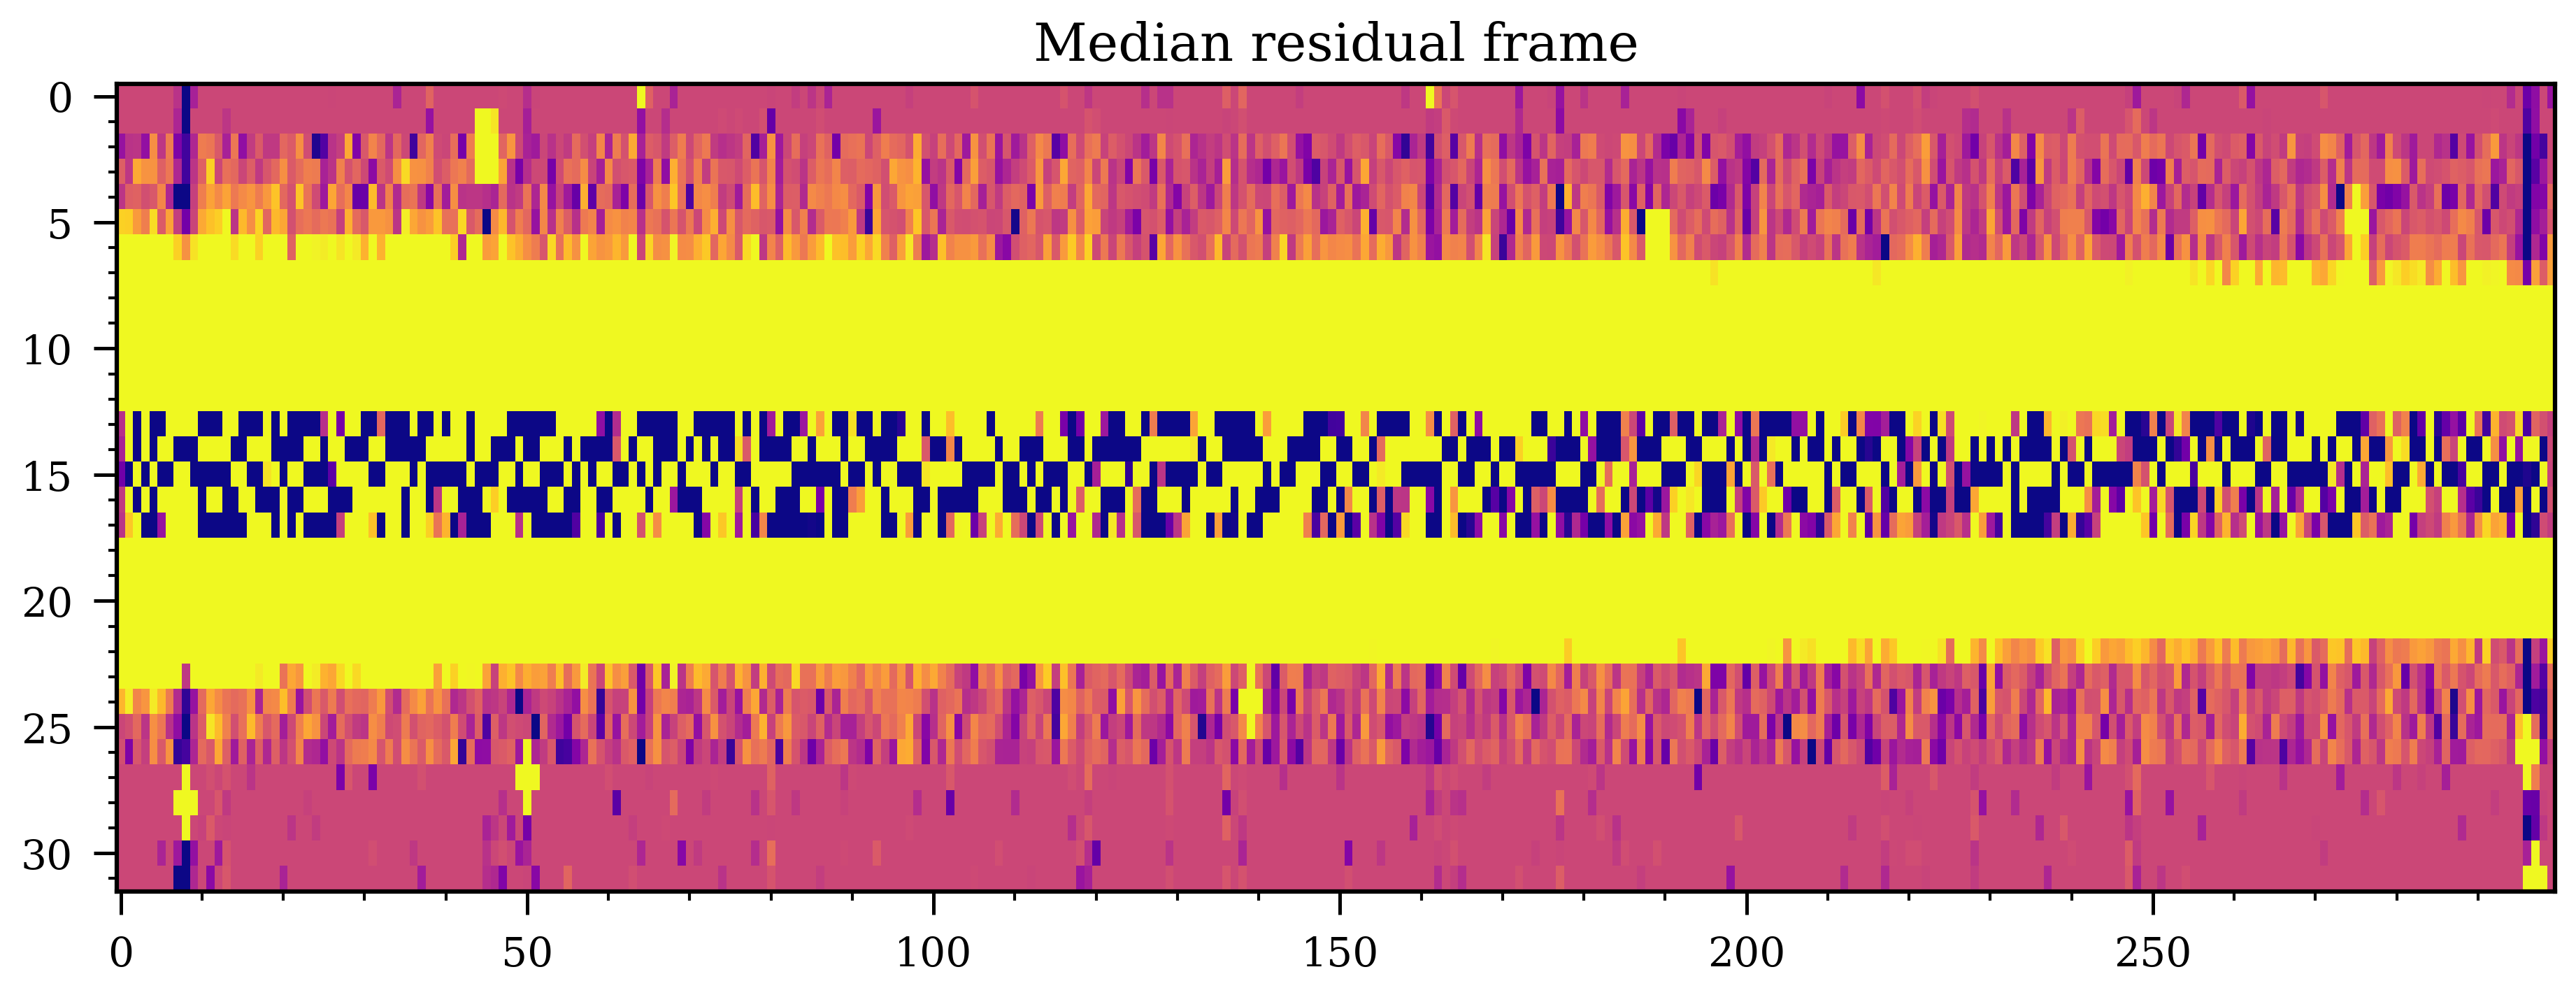

In [24]:
resid1 = np.zeros(syth1d.shape)
for j in range(resid1.shape[0]):
    resid1[j,:,:] = corrected_data[j,:,xpos[0]:xpos[-1]+1] - syth1d[j,:,:]

med_resid = np.nanmedian(resid1, axis=0)

plt.figure(figsize=(15,5))
im = plt.imshow(med_resid, interpolation='none', aspect='auto')
im.set_clim([-5,5])
#plt.xlim([0,315])
#plt.ylim([20,40])
plt.title('Median residual frame')